# Group 46 — Exploratory Data Analysis & Feature Engineering  
**Notebook:** `Group46_FeatureEngineering_Analysis.ipynb`  
**Course/Project:** *Amazing International Airlines Inc.* — Data Mining (Fall 2025–2026)  
**Authors:** Artem Polikarpov (20250443),  • **Date:** 2025-11-03  

---

## Objective  
This notebook performs **exploratory data analysis (EDA)** and **feature engineering** to build a meaningful, high-quality feature set supporting customer **segmentation**.

- **CRISP-DM Mapping:**  
  - **Data Understanding →** Explore multivariate patterns and relationships  
  - **Data Preparation →** Engineer and enrich variables for clustering

---

## Scope  
- **In scope:** Analyze distributions and correlations, handle missing values, and engineer interpretable, non-leaky, and non-redundant features.  
- **Out of scope:** Feature selection, model training, and tuning (addressed in later deliverables).

---

## Data Inputs  
- `DM_AIAI_CustomerDB.csv` — Cleaned Customer table  
- `DM_AIAI_FlightsDB.csv` — Cleaned Flights table (3-year span)  
- `cities_population_airport_availability.xlsx` — Supplemental data (population and airport availability)

---

## Outputs  
- `Group46_CustomerDB_Features.csv` — Engineered feature dataset  
- Inline Markdown documentation explaining each engineered feature and EDA insights


<div class="alert alert-block alert-success">

<a class="anchor" id="1st-bullet">    </a>
## 1. Initial Data Analysis and Cleaning
</div>

#### Importing Libraries and Data

In [164]:
# Core
import os 
import sys 
import warnings 
import numpy as np 
import pandas as pd
from math import ceil

# Viz
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina') 

# ML utils
#from sklearn.preprocessing import StandardScaler
#from sklearn.feature_selection import mutual_info_classif, mutual_info_regression

### Display & options ###
# Show up to 500 rows
pd.set_option('display.max_rows', 500)

# Show all columns
pd.set_option('display.max_columns', None)

# Avoid wrapping/truncation:
pd.set_option('display.width', 0)          # auto-detect terminal width
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)  # one-line if it fits

warnings.filterwarnings("ignore")
np.random.seed(42)

print("Versions -> pandas:", pd.__version__, "| numpy:", np.__version__)


Versions -> pandas: 2.3.2 | numpy: 2.2.6


#### Data Loading

In [165]:
# Adjust these paths to your repo structure
DATA_DIR = "data/"          # e.g., ../data/input
OUT_DIR  = "data/processed"      # where we will export engineered features
os.makedirs(OUT_DIR, exist_ok=True)

# Filenames agreed with the teammate who owns cleaning step
CUSTOMER_CSV = os.path.join(DATA_DIR, "DM_AIAI_CustomerDB.csv")
FLIGHTS_CSV  = os.path.join(DATA_DIR, "DM_AIAI_FlightsDB.csv")

# File with enriched data (population and airport availability)
POPULATION_AIRPORTS_XLSX = os.path.join(DATA_DIR, "cities_population_airport_availability.xlsx")

# Load
customers_df = pd.read_csv(CUSTOMER_CSV, parse_dates=["EnrollmentDateOpening","CancellationDate"], dtype={"CancellationDate": "string"}, na_values=["", "NA", "N/A"])
flights_df  = pd.read_csv(FLIGHTS_CSV, parse_dates=['YearMonthDate'])
pop_airports_df = pd.read_excel(POPULATION_AIRPORTS_XLSX, sheet_name = 'Input data')

customers_df.shape, flights_df.shape, pop_airports_df.shape

((16921, 21), (608436, 10), (29, 3))

In [166]:
customers_df.head(3)

,Unnamed: 0,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,<NA>,3839.14,Standard
1,1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,2019-03-09,<NA>,3839.61,Standard
2,2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,2017-07-14,1/8/2021,3839.75,Standard


In [167]:
customers_df.query("CancellationDate == '2/29/2019'")

,Unnamed: 0,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
8840,8840,314558,Retta,Pauley,Retta Pauley,Canada,Quebec,Montreal,45.501690,-73.567253,H4G 3T4,male,Bachelor,Rural,54311.0,Married,Nova,2017-09-05,2/29/2019,10722.06,Standard
14757,14757,373118,Quinn,Shamonsky,Quinn Shamonsky,Canada,Manitoba,Winnipeg,49.895138,-97.138374,R3R 3T4,male,College,Rural,0.0,Single,Star,2018-06-29,2/29/2019,7516.79,Standard


##### CancellationDate type issue
The `CancellationDate` column was loaded as an object because it contains an invalid date value (**29/02/2019**).  
Since 2019 was not a leap year, this record prevents proper datetime parsing.  
The correction (changing **29/02/2019** to **28/02/2019**) will be handled in the data cleaning stage.

#### Missing Values and Data Types

In [168]:
def quick_info(df, name):
    print(f"\n=== {name} ===")
    print("Shape:", df.shape)
    display(df.head(3))
    print("\nDtypes:")
    display(df.info(verbose=True, show_counts=True))
    #display(df.dtypes)
    print("\nMissing (%) by column:")
    display((df.isna().mean()*100).round(5).sort_values(ascending=False).to_frame("missing_pct"))

quick_info(customers_df, "CustomerDB (clean)")
quick_info(flights_df,  "FlightsDB  (clean)")
quick_info(pop_airports_df,  "pop_airports_df (additional data about population of cities and availability of airports)")


=== CustomerDB (clean) ===
Shape: (16921, 21)


,Unnamed: 0,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,<NA>,3839.14,Standard
1,1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,2019-03-09,<NA>,3839.61,Standard
2,2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,2017-07-14,1/8/2021,3839.75,Standard



Dtypes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16921 entries, 0 to 16920
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Unnamed: 0               16921 non-null  int64         
 1   Loyalty#                 16921 non-null  int64         
 2   First Name               16921 non-null  object        
 3   Last Name                16921 non-null  object        
 4   Customer Name            16921 non-null  object        
 5   Country                  16921 non-null  object        
 6   Province or State        16921 non-null  object        
 7   City                     16921 non-null  object        
 8   Latitude                 16921 non-null  float64       
 9   Longitude                16921 non-null  float64       
 10  Postal code              16921 non-null  object        
 11  Gender                   16921 non-null  object        
 12  Education              

None


Missing (%) by column:


...

,City,Population,has_airport
0,Hull,10000,0
1,Trenton,10000,0
2,Tremblant (Mont-Tremblant),10000,0



Dtypes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   City         29 non-null     object
 1   Population   29 non-null     int64 
 2   has_airport  29 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 828.0+ bytes


None


Missing (%) by column:


,missing_pct
City,0.0
Population,0.0
has_airport,0.0


The analysis above shows that only 20 records have missing values in the **Income** and **Customer Lifetime Value** fields.  
Given the small number of missing entries, these records can be safely removed.  

In [169]:
customers_df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Unnamed: 0,16921.0,NaN,NaN,NaN,8440.023639,0.0,4210.0,8440.0,12670.0,16900.0,4884.775439
Loyalty#,16921.0,NaN,NaN,NaN,550197.393771,100011.0,326823.0,550896.0,772438.0,999999.0,259251.503597
First Name,16921,4941,Deon,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Last Name,16921,15404,Ypina,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,16921,16921,Emma Martin,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,16921,1,Canada,16921,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Province or State,16921,11,Ontario,5468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,16921,29,Toronto,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,16921.0,NaN,NaN,NaN,47.1745,42.984924,44.231171,46.087818,49.28273,60.721188,3.307971
Longitude,16921.0,NaN,NaN,NaN,-91.814768,-135.05684,-120.23766,-79.383186,-74.596184,-52.712578,22.242429


In [170]:
flights_df.describe(include='all').T

,count,mean,min,25%,50%,75%,max,std
Loyalty#,608436.0,550037.873084,100018.0,326961.0,550834.0,772194.0,999986.0,258935.180575
Year,608436.0,2020.0,2019.0,2019.0,2020.0,2021.0,2021.0,0.816497
Month,608436.0,6.5,1.0,3.75,6.5,9.25,12.0,3.452055
YearMonthDate,608436,2020-06-16 02:40:00,2019-01-01 00:00:00,2019-09-23 12:00:00,2020-06-16 00:00:00,2021-03-08 18:00:00,2021-12-01 00:00:00,NaN
NumFlights,608436.0,3.908107,0.0,0.0,0.0,7.2,21.0,5.057889
NumFlightsWithCompanions,608436.0,0.983944,0.0,0.0,0.0,0.9,11.0,2.003785
DistanceKM,608436.0,7939.341419,0.0,0.0,856.4,15338.175,42040.0,10260.421873
PointsAccumulated,608436.0,793.777781,0.0,0.0,85.275,1533.7125,4204.0,1025.918521
PointsRedeemed,608436.0,235.251678,0.0,0.0,0.0,0.0,7496.0,983.233374
DollarCostPointsRedeemed,608436.0,2.324835,0.0,0.0,0.0,0.0,74.0,9.725168


#### Data Cleaning 

In [171]:
# Replace missing values in 'Income' and 'Customer Lifetime Value' columns with their respective medians (affecting 20 rows)
customers_df["Income"] = customers_df["Income"].fillna(customers_df["Income"].median())
customers_df["Customer Lifetime Value"] = customers_df["Customer Lifetime Value"].fillna(customers_df["Customer Lifetime Value"].median())

In [172]:
# Fix the impossible date (2019 wasn’t a leap year)
customers_df.loc[customers_df["CancellationDate"].eq("29/02/2019"), "CancellationDate"] = "28/02/2019"

# Now parse safely (day-first if your data is D/M/Y)
customers_df["CancellationDate"] = pd.to_datetime(customers_df["CancellationDate"], errors="coerce", dayfirst=True)

In [173]:
customers_df["CancellationDate"].dtype            # expect datetime64[ns]
customers_df["CancellationDate"].tail(1)          # expect date format as: year-mm-dd

16920   2020-07-21
Name: CancellationDate, dtype: datetime64[ns]

####         
#### Basic Feature Filtering (Manual Review)

A preliminary review of the **Customers** table indicates the following:

- The **Unnamed** column can be removed as it duplicates the index.  
- **First Name**, **Last Name**, and **Customer Name** can be dropped since each customer is uniquely identified by **Loyalty#**.  
- The **Country** column can be deleted because it contains only a single distinct value (*Canada*).  

In [174]:
# The table below illustrates several examples where the same city appears with different combinations of latitude and longitude.  
# To maintain location accuracy, it is advisable to preserve all three attributes: City, Latitude, and Longitude.
temp_df = customers_df[['City','Latitude','Longitude']].sort_values(by='City').drop_duplicates().copy()
temp_df[3:10]

,City,Latitude,Longitude
1054,Dawson Creek,55.759628,-120.237660
16920,Dawson Creek,55.720562,-120.160090
16914,Dawson Creek,55.751178,-120.264920
16907,Dawson Creek,55.701475,-120.181716
2355,Edmonton,53.544388,-113.490930
16917,Edmonton,53.524829,-113.546357
16913,Edmonton,53.549353,-113.509109


In [175]:
customers_df.columns

Index(['Unnamed: 0', 'Loyalty#', 'First Name', 'Last Name', 'Customer Name',
       'Country', 'Province or State', 'City', 'Latitude', 'Longitude',
       'Postal code', 'Gender', 'Education', 'Location Code', 'Income',
       'Marital Status', 'LoyaltyStatus', 'EnrollmentDateOpening',
       'CancellationDate', 'Customer Lifetime Value', 'EnrollmentType'],
      dtype='object')

In [176]:
net_customers_df = customers_df[['Loyalty#', 'Province or State', 'City', 'Latitude', 'Longitude',
       'Postal code', 'Gender', 'Education', 'Location Code', 'Income',
       'Marital Status', 'LoyaltyStatus', 'EnrollmentDateOpening',
       'CancellationDate', 'Customer Lifetime Value', 'EnrollmentType']].copy()

In [177]:
net_customers_df.head(1)

,Loyalty#,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,480934,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaT,3839.14,Standard


<div class="alert alert-block alert-success">

<a class="anchor" id="1st-bullet">    </a>
## 2. Feature Engineering and Feature Enrichment
</div>

In [178]:
# Active vs. canceled
net_customers_df["is_active"] = net_customers_df["CancellationDate"].isna().astype(int)

In [179]:
# Choose a reference date (e.g., data extract date)
asof = pd.Timestamp("2025-10-31")

# Tenure to snapshot (days) — handles NaT by using 'asof' for active customers
start = pd.to_datetime(net_customers_df["EnrollmentDateOpening"], errors="coerce")
end   = pd.to_datetime(net_customers_df["CancellationDate"], errors="coerce").fillna(asof)
net_customers_df["tenure_days"] = (end - start).dt.days

In [180]:
net_customers_df["income_type"] = net_customers_df["Income"].apply(
    lambda x: "No income" if x == 0 else
              "Small"     if x < 25_000 else
              "Middle"    if x < 50_000 else
              "Big"
)

In [181]:
net_customers_df.head(1)

,Loyalty#,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,is_active,tenure_days,income_type
0,480934,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaT,3839.14,Standard,1,2450,Big


#### Feature Enrichment via Table Merge (Customers × Population & Airports)

In [182]:
# Add engineered features from the lookup dataset:
# - Customer city population
# - Indicator of a nearby public airport (derived from customer's city location)
enriched_customers_df = net_customers_df.merge(pop_airports_df, on="City", how="left", validate="m:1")

In [183]:
enriched_customers_df.head(3)

,Loyalty#,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,is_active,tenure_days,income_type,Population,has_airport
0,480934,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaT,3839.14,Standard,1,2450,Big,2600000.0,1.0
1,549612,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,2019-03-09,NaT,3839.61,Standard,1,2428,No income,712391.0,1.0
2,429460,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,2017-07-14,2021-08-01,3839.75,Standard,0,1479,No income,600000.0,1.0


#### Linking Flights Data to Customer Records

In [184]:
# Joinability
assert "Loyalty#" in enriched_customers_df.columns and "Loyalty#" in flights_df.columns, "Missing Loyalty# in one of the tables"

# Duplicate check per month in FlightsDB
dup_keys = enriched_customers_df.duplicated(subset=["Loyalty#"]).sum()
print("Duplicate rows per (Loyalty#) in CustomersDB:", dup_keys)

# Duplicate check per month in FlightsDB
dup_keys = flights_df.duplicated(subset=["Loyalty#", "YearMonthDate"]).sum()
print("Duplicate rows per (Loyalty#, YearMonthDate) in FlightsDB:", dup_keys)

# Basic period coverage
year_span = (flights_df["Year"].min(), flights_df["Year"].max())
print("FlightsDB year span:", year_span)

Duplicate rows per (Loyalty#) in CustomersDB: 164
Duplicate rows per (Loyalty#, YearMonthDate) in FlightsDB: 5904
FlightsDB year span: (2019, 2021)


In [185]:
# IDs that appear more than once in CustomerDB
dupe_ids = enriched_customers_df.loc[enriched_customers_df['Loyalty#'].duplicated(keep=False), 'Loyalty#'].unique()

# Drop ALL records for those IDs from both tables
customers_clean_df = enriched_customers_df[~enriched_customers_df['Loyalty#'].isin(dupe_ids)].copy()
flights_clean_df  = flights_df[~flights_df['Loyalty#'].isin(dupe_ids)].copy()

print("Removed customers:", len(dupe_ids))
print("Customer rows ->", enriched_customers_df.shape[0], "→", customers_clean_df.shape[0])
print("Flight rows ->", flights_df.shape[0], "→", flights_clean_df.shape[0])

Removed customers: 163
Customer rows -> 16921 → 16594
Flight rows -> 608436 → 596664


In [186]:
customers_clean_df.head(1)

,Loyalty#,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,is_active,tenure_days,income_type,Population,has_airport
0,480934,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaT,3839.14,Standard,1,2450,Big,2600000.0,1.0


In [187]:
aggregated_df = customers_clean_df.merge(flights_df, on='Loyalty#', how='left')

In [188]:
aggregated_df.head(3)

,Loyalty#,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,is_active,tenure_days,income_type,Population,has_airport,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
0,480934,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaT,3839.14,Standard,1,2450,Big,2600000.0,1.0,2020.0,5.0,2020-05-01,13.0,4.0,25010.0,2501.0,0.0,0.0
1,480934,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaT,3839.14,Standard,1,2450,Big,2600000.0,1.0,2020.0,4.0,2020-04-01,0.0,0.0,5095.0,509.0,0.0,0.0
2,480934,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaT,3839.14,Standard,1,2450,Big,2600000.0,1.0,2020.0,2.0,2020-02-01,3.0,0.0,24271.0,2427.0,0.0,0.0


In [189]:
# The aggregated table now contains fewer records than the Flights table 
# because 164 duplicate customers were removed from the Customers table. 
# These duplicates had previously inflated errors in the Flights data, 
# since each customer is linked to multiple flight records. 
# This issue with duplicate records is now resolved.
aggregated_df.shape

(596684, 30)

In [190]:
flights_df.shape

(608436, 10)

In [191]:
df = aggregated_df.copy()

<div class="alert alert-block alert-success">

<a class="anchor" id="1st-bullet">    </a>
## 3. Segment-Based Exploratory Data Analysis
</div>

In [282]:
plt.rcParams["figure.dpi"] = 90

def by_subjects(subj, subj1, agg="median", top_n=None, palette=None):
   
    # 1) Filter and aggregate
    d = df.copy()
    aggfunc = {"mean": "mean", "median": "median", "sum": "sum", "max": "max"}[agg]

    g = (
        d.groupby([subj1], as_index=False)[subj]
         .agg(aggfunc)
         .rename(columns={subj: f"{subj}Agg"})
    )

    # 2) Optional: keep top N provinces by overall income
    if top_n is not None:
        keep = (
            g.groupby(subj1)[f"{subj}Agg"]
             .mean()
             .nlargest(top_n)
             .index
        )
        g = g[g[subj1].isin(keep)]

    # 3) Order provinces by overall income for nicer y-sorting
    order = (
        g.groupby(subj1)[f"{subj}Agg"]
         .mean()
         .sort_values(ascending=True)
         .index
         .tolist()
    )

    # 4) Plot (horizontal bars)
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(8, max(3.5, 0.35 * len(order) + 1)))
    ax = sns.barplot(
        data=g,
        y=subj1, x=f"{subj}Agg",
        order=order, orient="h", errorbar=None,
        dodge=True, width=0.7, palette=palette
    )

    # 5) Labels & legend
    ax.set_title(f"{subj} by {subj1}", fontsize=11)
    ax.set_xlabel(f"{agg.capitalize()} {subj}", fontsize=10)
    ax.set_ylabel(subj1, fontsize=10)
    ax.tick_params(axis="x", labelsize=9)
    ax.tick_params(axis="y", labelsize=9)
    plt.tight_layout()
    return plt.show()


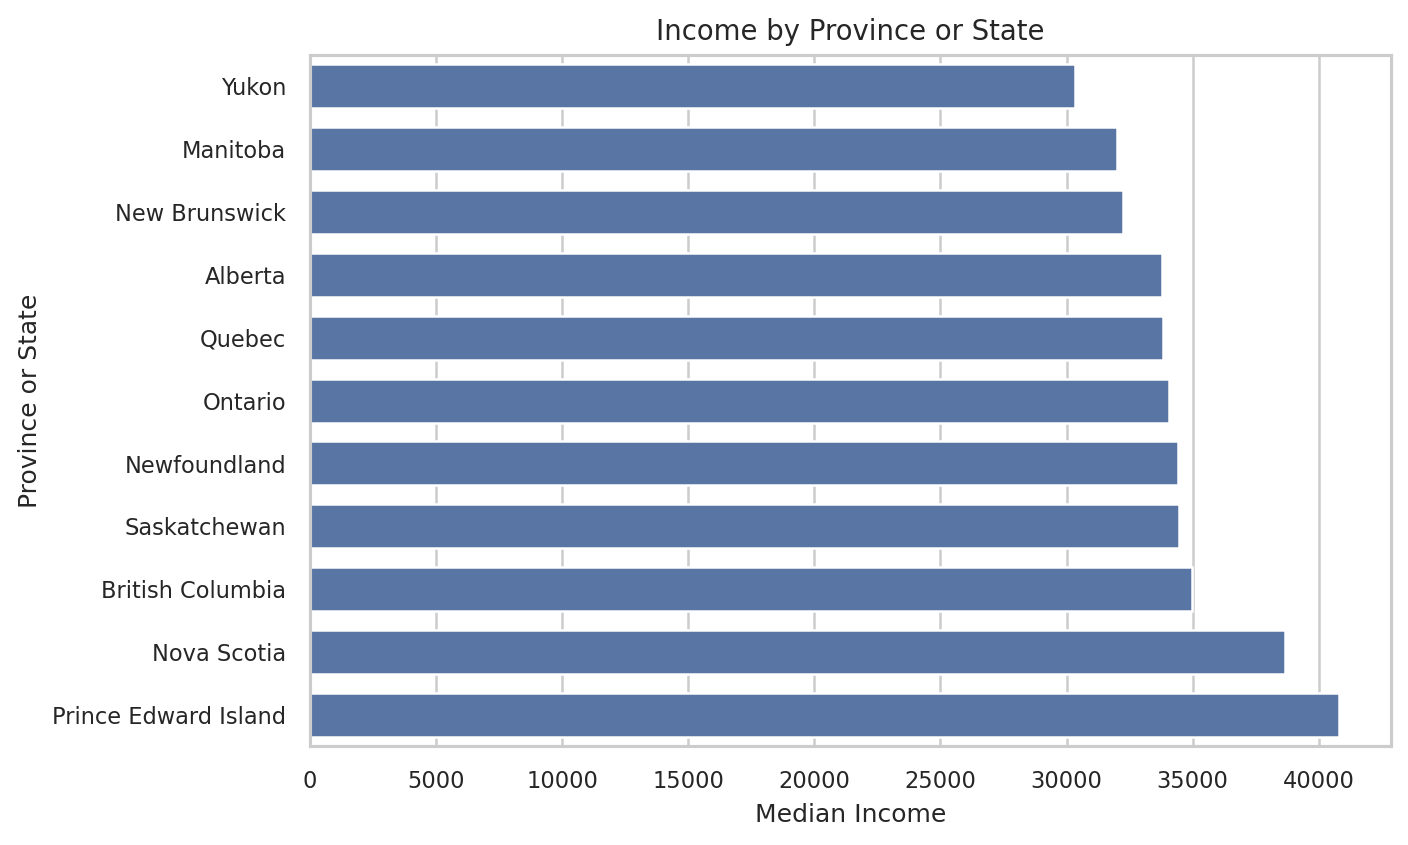

In [267]:
by_subjects(subj="Income", subj1="Province or State", agg="median", top_n=None, palette=None)

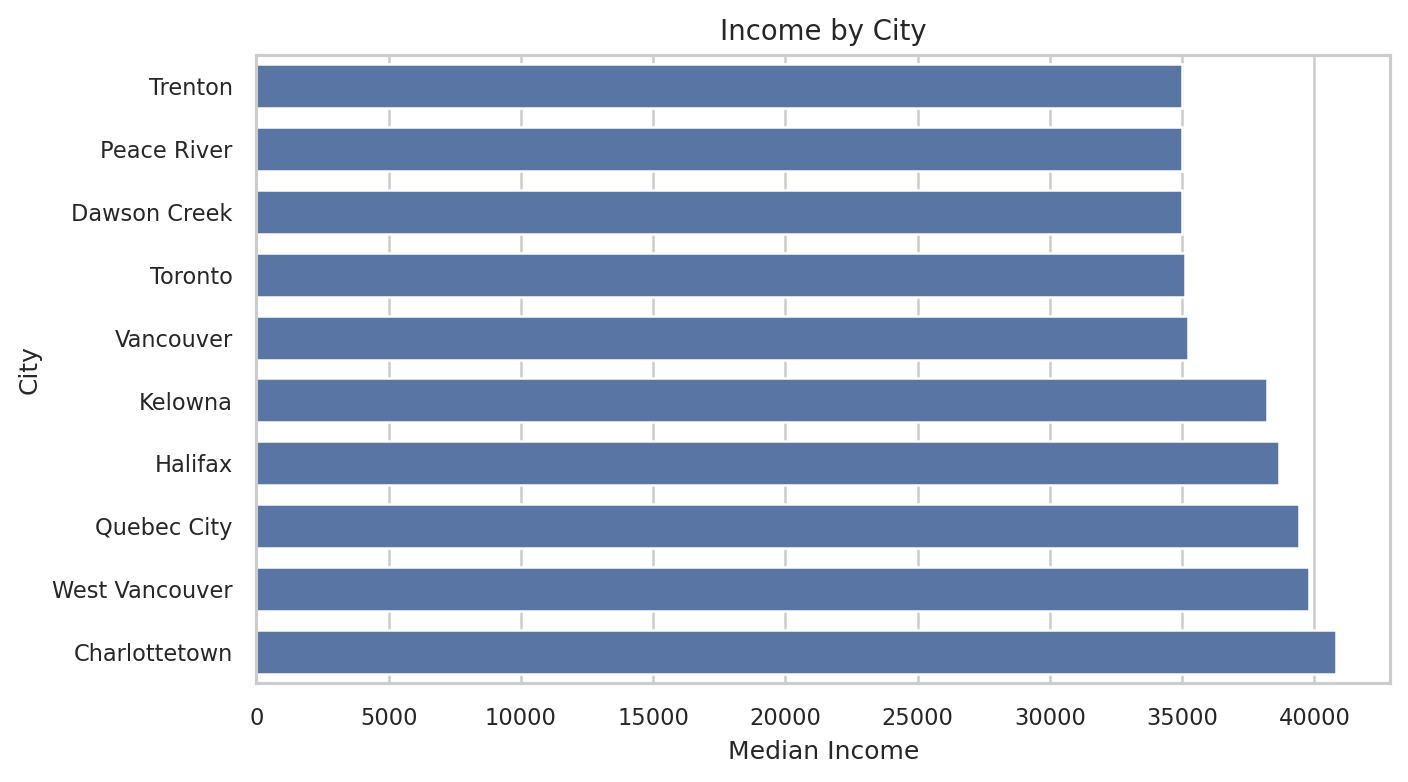

In [285]:
by_subjects(subj="Income", subj1="City", agg="median", top_n=10, palette=None)

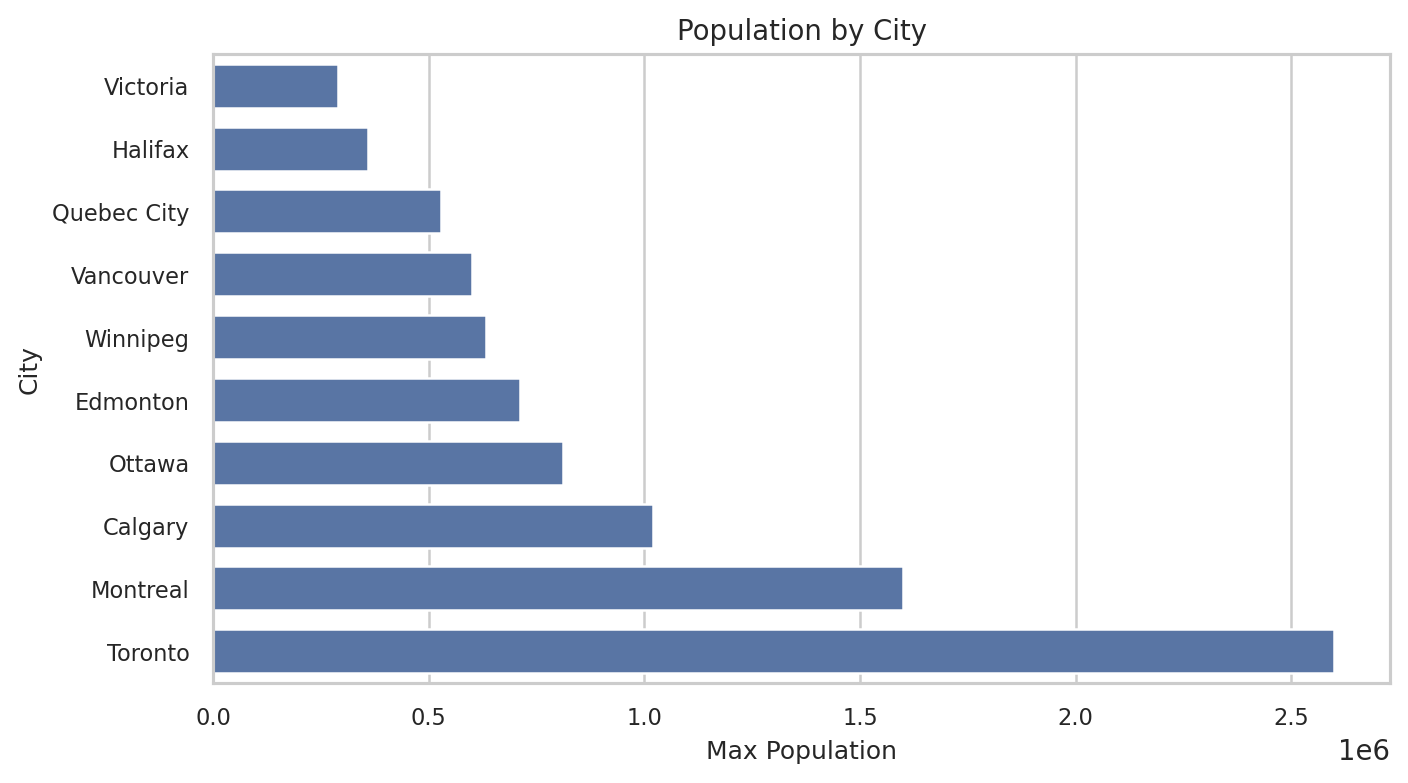

In [280]:
by_subjects(subj="Population", subj1="City", agg="max", top_n=10, palette=None)

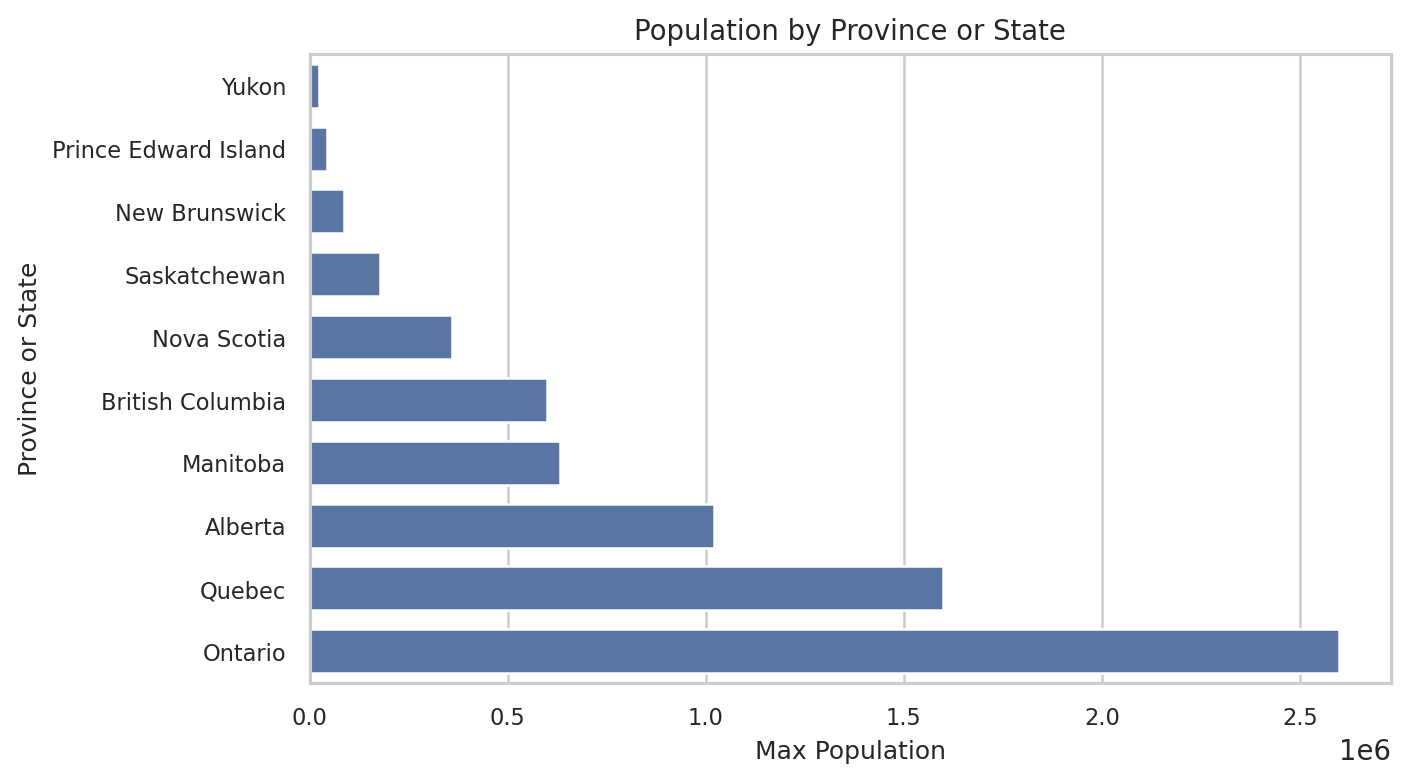

In [283]:
by_subjects(subj="Population", subj1="Province or State", agg="max", top_n=10, palette=None)

#### 1) Value-based segmentation (economic contribution)

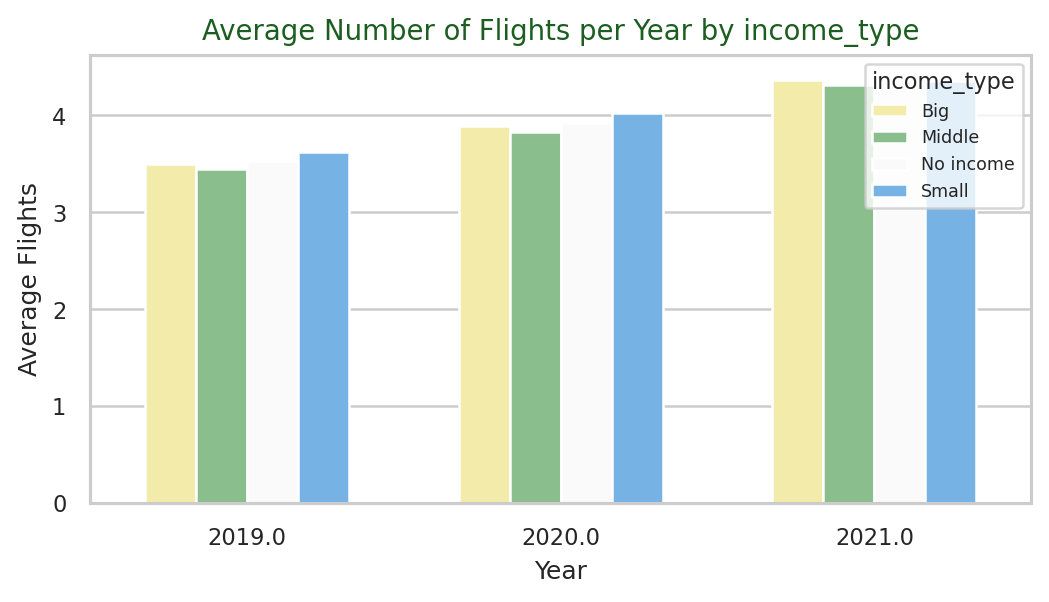

In [213]:
flights_per_year(
    beh_param="income_type",
    palette = {
        "Big":  "#fff59d", #(Yellow 200)
        "Middle": "#81c784",  # light green
        "Small": "#64b5f6",  # light blue (Blue 300)
        "No income": "#fafafa"  # Nice white
    }
)

In [192]:
# V1) CLV by loyalty tier
val_clv_by_tier = pd.DataFrame(df.groupby(["LoyaltyStatus"])["Customer Lifetime Value"].mean().round(0).sort_values(ascending=False))
val_clv_by_tier

,Customer Lifetime Value
LoyaltyStatus,
Aurora,10678.0
Nova,8041.0
Star,6754.0


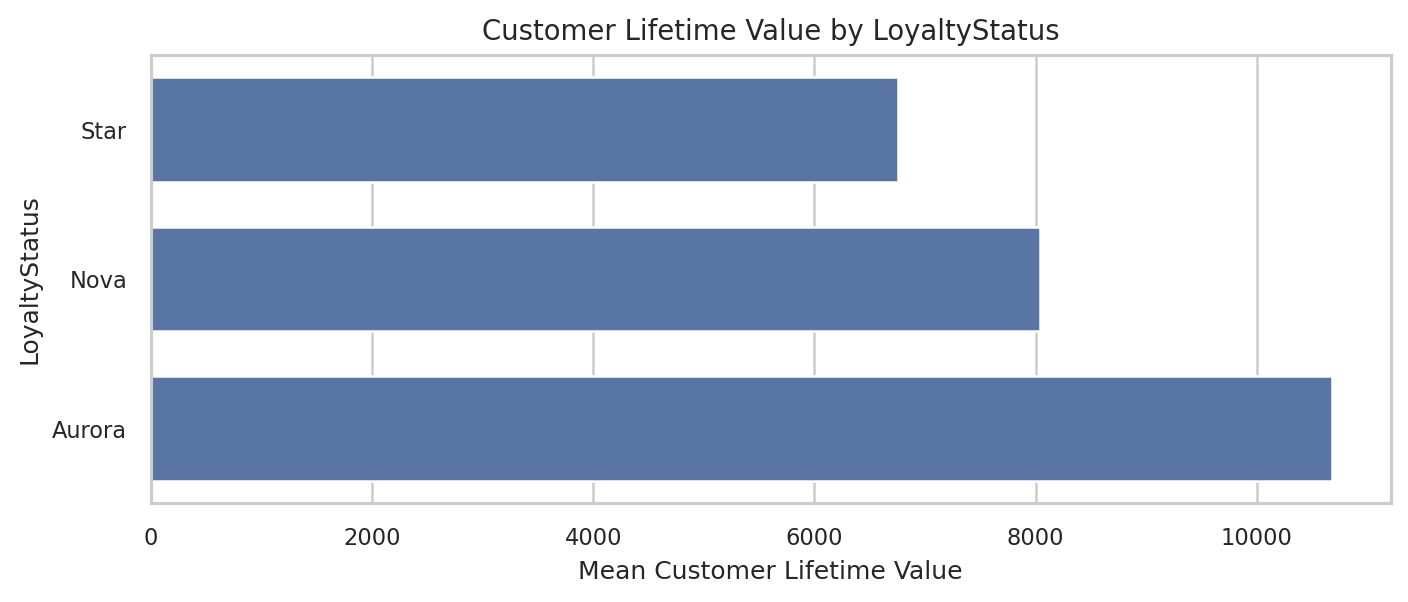

In [294]:
by_subjects(subj="Customer Lifetime Value", subj1="LoyaltyStatus", agg="mean", top_n=None, palette=None)

In [193]:
# V2) Redemption efficiency (Redeemed / Accumulated) by tier
temp = df.groupby("LoyaltyStatus")[["PointsRedeemed", "PointsAccumulated"]].sum()
val_redemption_eff_by_tier = pd.DataFrame(
    (temp["PointsRedeemed"] / temp["PointsAccumulated"])
    .sort_values(ascending=False).round(2), columns=['redemption_eff']
)
val_redemption_eff_by_tier

,redemption_eff
LoyaltyStatus,
Aurora,0.30
Star,0.30
Nova,0.29


In [194]:
# V3) Spend per flight (DollarCostPointsRedeemed / NumFlights) by tier
temp = df.groupby(["Year","LoyaltyStatus"])[["DollarCostPointsRedeemed", "NumFlights"]].sum()
val_spend_per_flight_by_tier = pd.DataFrame(
    (temp["DollarCostPointsRedeemed"] / temp["NumFlights"])
    .round(2), columns=['spend_per_flight']
)
val_spend_per_flight_by_tier

spend_per_flight
Year   LoyaltyStatus                  
2019.0 Aurora                     0.60
       Nova                       0.57
       Star                       0.60
2020.0 Aurora                     0.60
       Nova                       0.57
       Star                       0.60
2021.0 Aurora                     0.61
       Nova                       0.61
       Star                       0.61

In [195]:
# V4) CLV: Active vs Churned
val_clv_active_vs_churned = pd.DataFrame(
    df.groupby(["is_active"])["Customer Lifetime Value"]
      .mean()
      .rename(index={0: "churned", 1: "active"})
      .sort_values(ascending=False).round(0)
)
val_clv_active_vs_churned

,Customer Lifetime Value
is_active,
churned,8125.0
active,7965.0


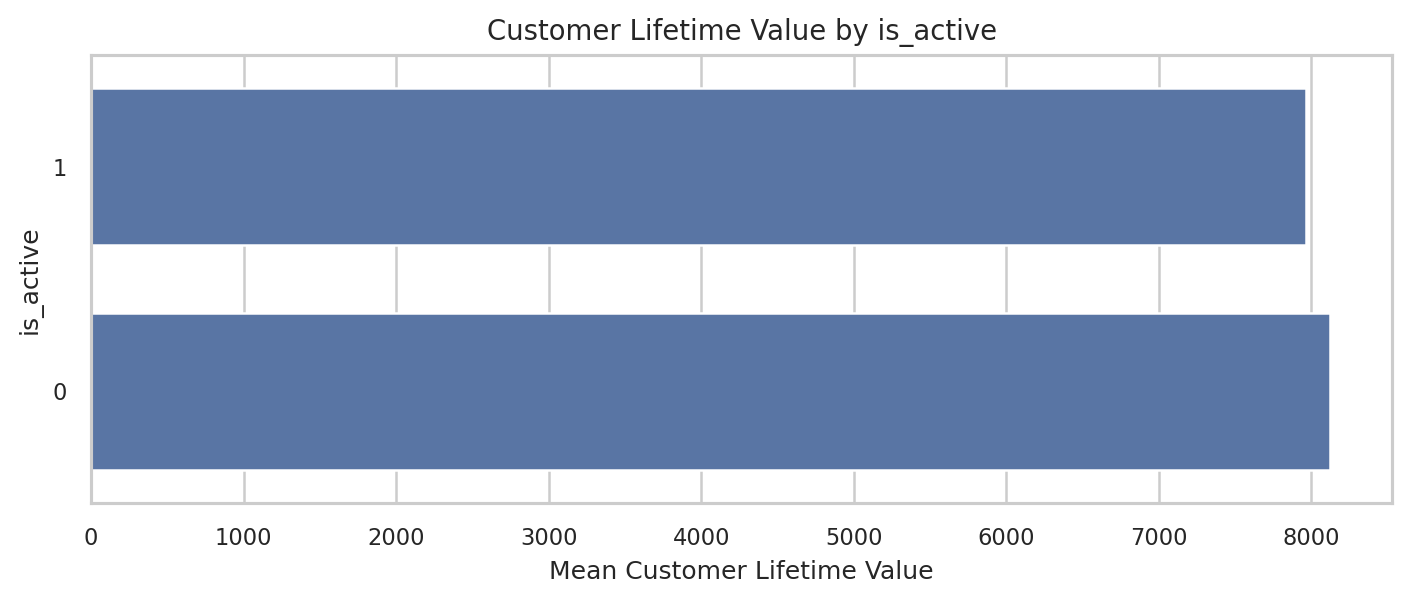

In [297]:
by_subjects(subj="Customer Lifetime Value", subj1="is_active", agg="mean", top_n=None, palette=None)

#### 2) Behavioral segmentation

In [196]:
# B1) Average flights per year
beh_avg_flights_per_year = pd.DataFrame(df.groupby("Year")["NumFlights"].mean().round(1).sort_index())
beh_avg_flights_per_year

,NumFlights
Year,
2019.0,3.5
2020.0,3.9
2021.0,4.4


In [197]:
# B2) Share of flights with companions by loyalty tier
temp = df.groupby(["LoyaltyStatus"])[["NumFlightsWithCompanions", "NumFlights"]].sum()
beh_companion_share_by_tier = pd.DataFrame(
    (temp["NumFlightsWithCompanions"] / temp["NumFlights"])
    .sort_values(ascending=False).round(2), columns=['%_of_flights_with_companions']
)
beh_companion_share_by_tier

,%_of_flights_with_companions
LoyaltyStatus,
Star,0.25
Aurora,0.25
Nova,0.25


In [198]:
# B3) Average distance per flight by loyalty tier
temp = df.groupby(["Year","LoyaltyStatus"])[["DistanceKM", "NumFlights"]].sum()
beh_avg_distance_per_flight_by_tier = pd.DataFrame(
    (temp["DistanceKM"] / temp["NumFlights"])
    .round(0), columns=['avg_distance_per_flight']
)
beh_avg_distance_per_flight_by_tier

avg_distance_per_flight
Year   LoyaltyStatus                         
2019.0 Aurora                          1998.0
       Nova                            2008.0
       Star                            2015.0
2020.0 Aurora                          1998.0
       Nova                            2008.0
       Star                            2015.0
2021.0 Aurora                          2076.0
       Nova                            2052.0
       Star                            2076.0

In [199]:
# B4) Flight frequency by enrollment type
beh_flights_by_enrollment_type = pd.DataFrame(df.groupby(["Year", "EnrollmentType"])["NumFlights"].mean())
beh_flights_by_enrollment_type

NumFlights
Year   EnrollmentType            
2019.0 2021 Promotion    2.196090
       Standard          3.610485
2020.0 2021 Promotion    2.440100
       Standard          4.011650
2021.0 2021 Promotion    4.656415
       Standard          4.341178

In [200]:
plt.rcParams["figure.dpi"] = 90      
#plt.rcParams["savefig.dpi"] = 100     # for saved files

def flights_per_year(beh_param, palette):

    # Prepare data (mean flights by Year×behaviour_parameter)
    beh = (
        df.groupby(["Year", beh_param])["NumFlights"]
          .mean()
          .reset_index()
    )
    
    
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(6,3.5))
    ax = sns.barplot(
        data=beh,
        x="Year", y="NumFlights", hue=beh_param,
        estimator="mean", errorbar=None,
        width = 0.65,
        palette = palette
    )
    # Tick labels
    ax.tick_params(axis="x", labelsize=9)
    ax.tick_params(axis="y", labelsize=9)
    
    ax.set_title(f"Average Number of Flights per Year by {beh_param}", color="#1b5e20", fontsize=11)
    ax.set_xlabel("Year", fontsize=10); ax.set_ylabel("Average Flights", fontsize=10)
    ax.legend(title=beh_param, fontsize=7, title_fontsize=9)
    plt.tight_layout(); 
    return plt.show()

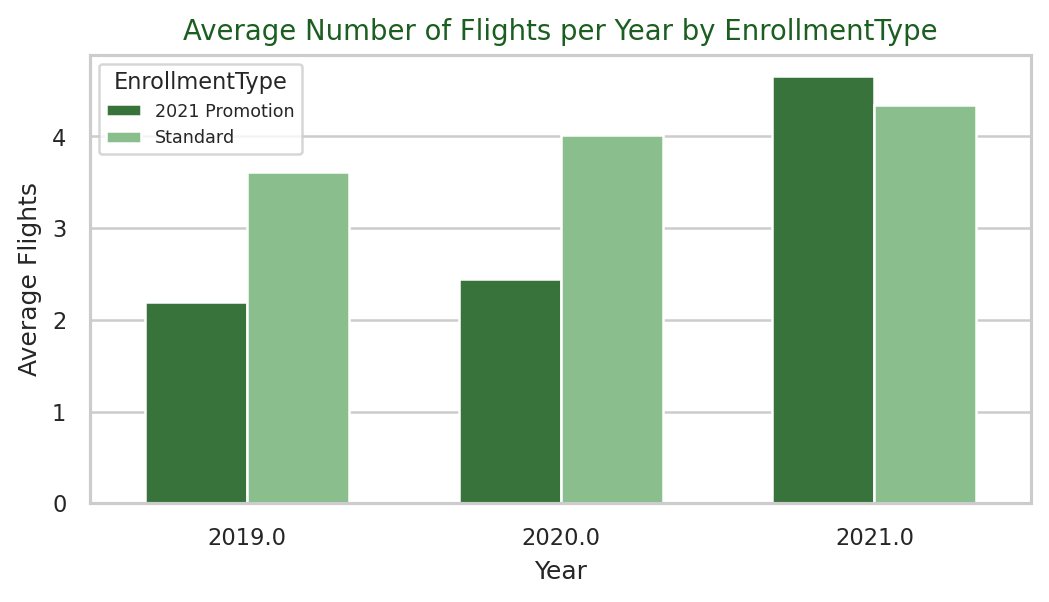

In [201]:
flights_per_year(
    beh_param="EnrollmentType",
    palette = {
        "2021 Promotion":  "#2e7d32",  # dark green
        "Standard": "#81c784",  # light green
    }
)

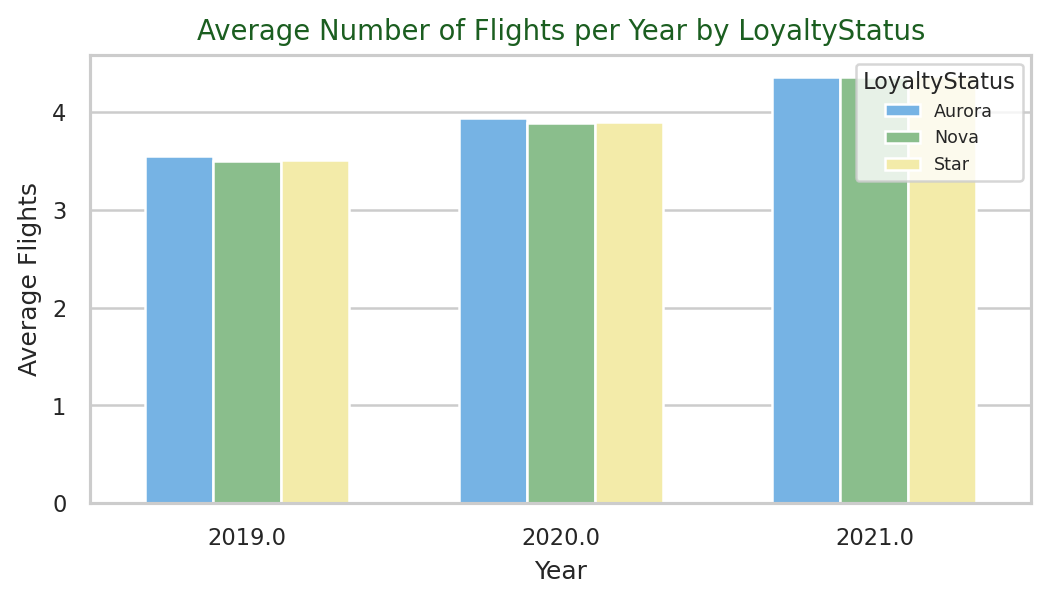

In [202]:
flights_per_year(
    beh_param="LoyaltyStatus",
    palette = {
        "Star":  "#fff59d", #(Yellow 200)
        "Aurora": "#64b5f6",  # light blue (Blue 300)
        "Nova": "#81c784",  # light green
    }
)

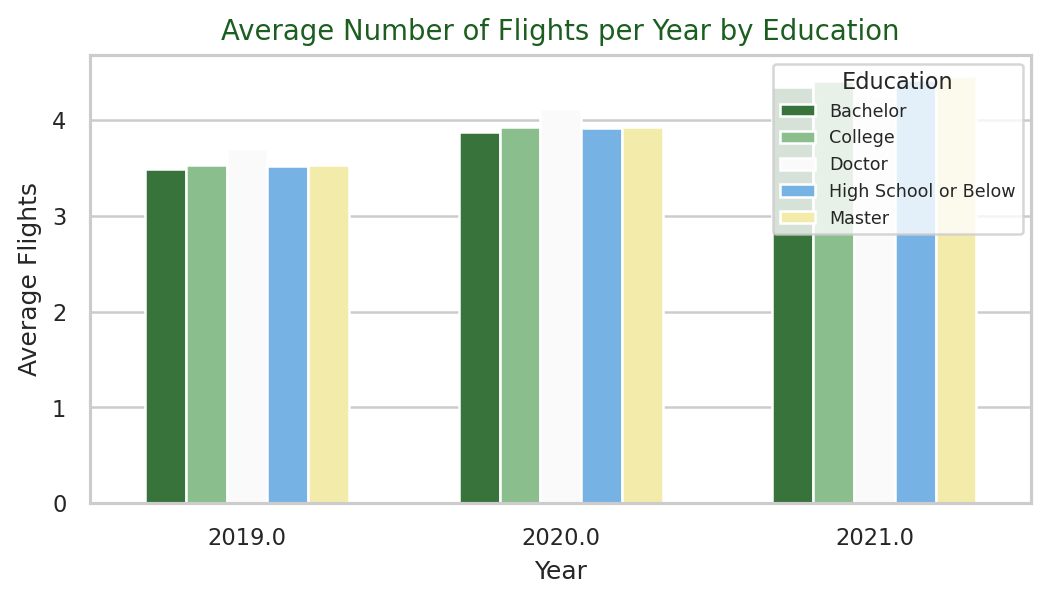

In [215]:
flights_per_year(
    beh_param="Education",
    palette = {
        "Doctor": "#fafafa",
        "Master": "#fff59d", #(Yellow 200)
        "Bachelor": "#2e7d32", # dark green
        "College": "#81c784",  # light green
        "High School or Below": "#64b5f6",  # light blue (Blue 300)
        
    }
)

In [217]:
df['Province or State'].unique()

array(['Ontario', 'Alberta', 'British Columbia', 'Quebec',
       'New Brunswick', 'Manitoba', 'Nova Scotia', 'Saskatchewan',
       'Newfoundland', 'Yukon', 'Prince Edward Island'], dtype=object)

In [209]:
df.columns

Index(['Loyalty#', 'Province or State', 'City', 'Latitude', 'Longitude',
       'Postal code', 'Gender', 'Education', 'Location Code', 'Income',
       'Marital Status', 'LoyaltyStatus', 'EnrollmentDateOpening',
       'CancellationDate', 'Customer Lifetime Value', 'EnrollmentType',
       'is_active', 'tenure_days', 'income_type', 'Population', 'has_airport',
       'Year', 'Month', 'YearMonthDate', 'NumFlights',
       'NumFlightsWithCompanions', 'DistanceKM', 'PointsAccumulated',
       'PointsRedeemed', 'DollarCostPointsRedeemed'],
      dtype='object')

#### 3) Demographic segmentation

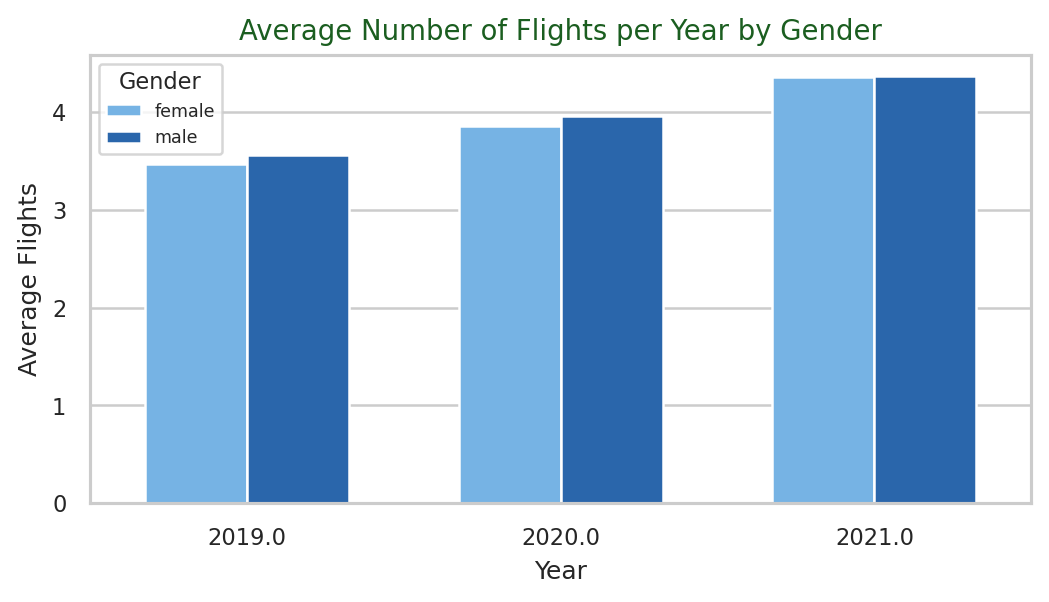

In [205]:
flights_per_year(
    beh_param="Gender",
    palette = {
        "male":  "#1565c0",  # dark blue (Blue 800)
        "female": "#64b5f6",  # light blue (Blue 300)
    }
)

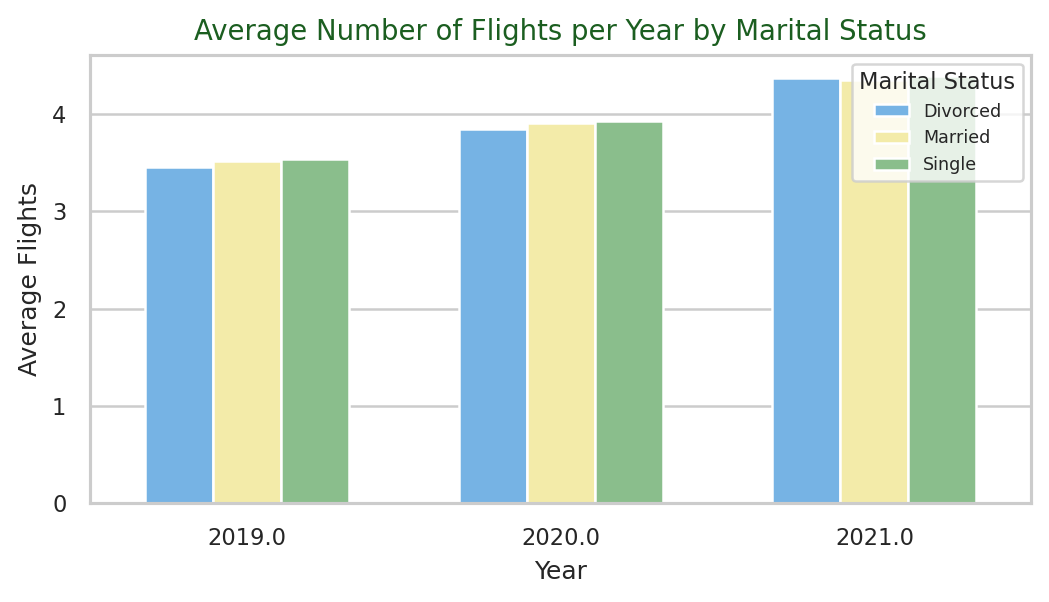

In [206]:
flights_per_year(
    beh_param="Marital Status",
    palette = {
        "Married":  "#fff59d", #(Yellow 200)
        "Divorced": "#64b5f6",  # light blue (Blue 300)
        "Single": "#81c784",  # light green
    }
)

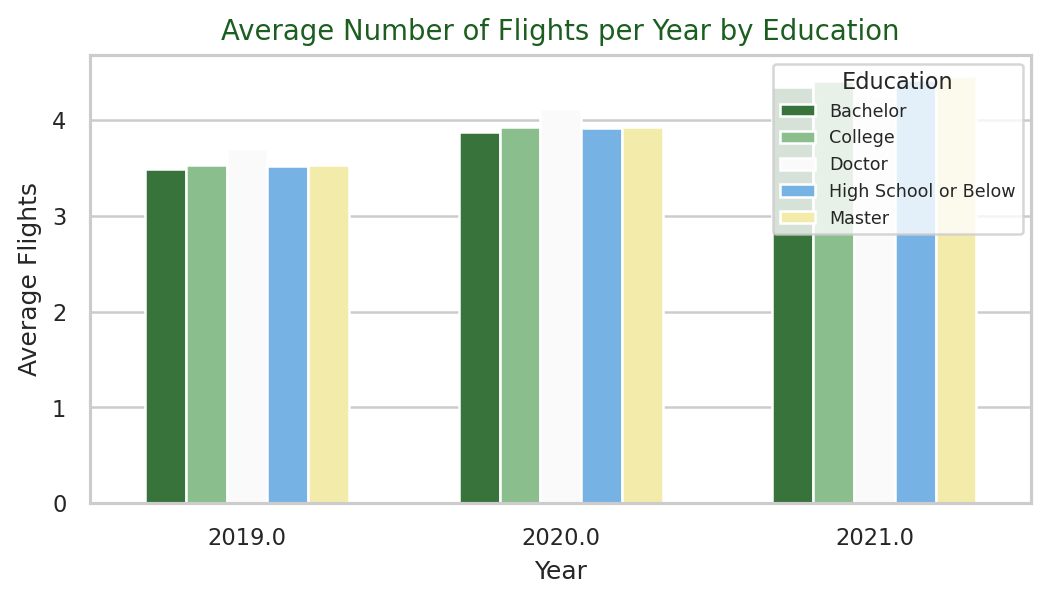

In [216]:
flights_per_year(
    beh_param="Education",
    palette = {
        "Doctor": "#fafafa",
        "Master": "#fff59d", #(Yellow 200)
        "Bachelor": "#2e7d32", # dark green
        "College": "#81c784",  # light green
        "High School or Below": "#64b5f6",  # light blue (Blue 300)
        
    }
)

In [107]:
# D1) Average CLV by Gender over Years (level table)
dem_clv_by_gender_year = pd.DataFrame(
    df.groupby(["Gender"])["Customer Lifetime Value"]
      .mean()  
      .round(2)
)
dem_clv_by_gender_year

,Customer Lifetime Value
Gender,
female,7965.12
male,8008.12


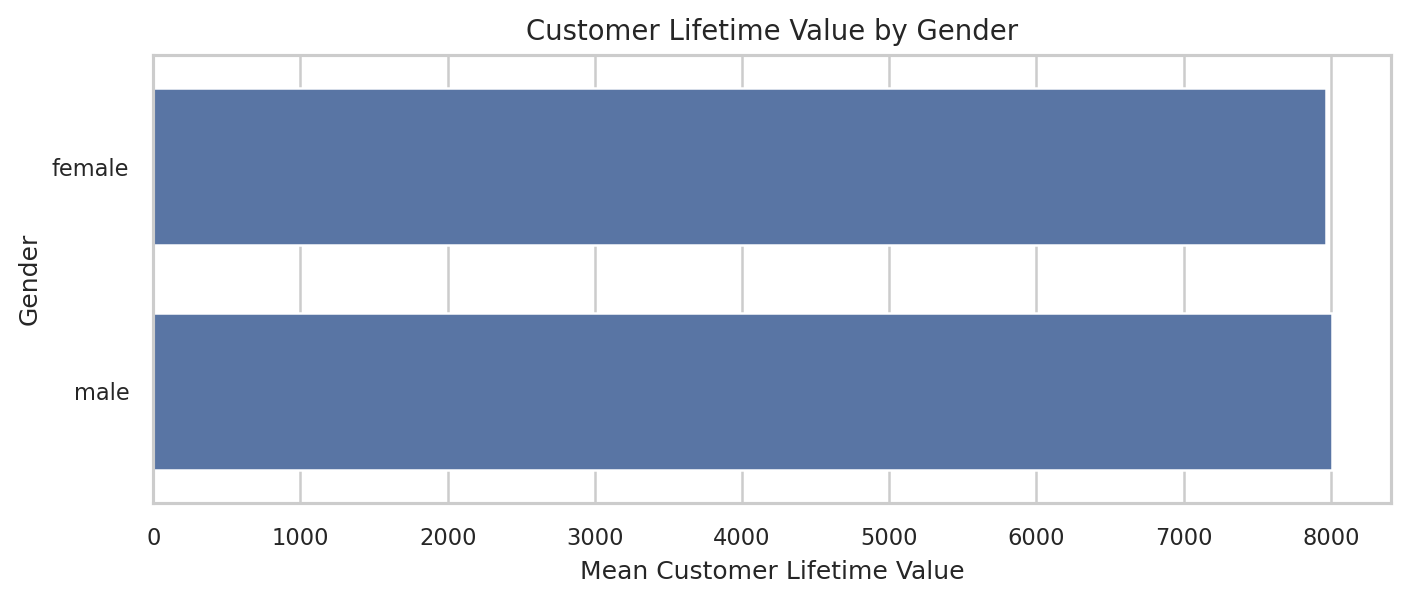

In [298]:
by_subjects(subj="Customer Lifetime Value", subj1="Gender", agg="mean", top_n=None, palette=None)

In [51]:
df2 = df.copy()
df2["enroll_year"] = pd.to_datetime(df2["EnrollmentDateOpening"]).dt.year

# one row per customer (their CLV and Gender), then average by cohort
cust = (df2.sort_values(["Loyalty#", "enroll_year"])
           .drop_duplicates("Loyalty#"))

dem_clv_by_gender_enrollcohort = (
    cust.groupby(["enroll_year", "Gender"])["Customer Lifetime Value"]
        .mean()
        .unstack("Gender")
        .round(2)
        .sort_index()
)
dem_clv_by_gender_enrollcohort

Gender,female,male
enroll_year,,
2015,7917.69,8093.36
2016,8022.68,8069.01
2017,7829.19,7872.92
2018,8023.11,8329.44
2019,7922.95,8214.47
2020,7797.75,7737.66
2021,8180.53,7821.80


<div class="alert alert-block alert-success">

<a class="anchor" id="1st-bullet">    </a>
## 4. General Exploratory Data Analysis
</div>

In [56]:
customers = customers_df.copy()

In [57]:
flights = flights_df.copy()

In [49]:
customers.shape

(16901, 21)

In [50]:
flights.shape

(608436, 10)

In [51]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16901 entries, 0 to 16900
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Unnamed: 0               16901 non-null  int64         
 1   Loyalty#                 16901 non-null  int64         
 2   First Name               16901 non-null  object        
 3   Last Name                16901 non-null  object        
 4   Customer Name            16901 non-null  object        
 5   Country                  16901 non-null  object        
 6   Province or State        16901 non-null  object        
 7   City                     16901 non-null  object        
 8   Latitude                 16901 non-null  float64       
 9   Longitude                16901 non-null  float64       
 10  Postal code              16901 non-null  object        
 11  Gender                   16901 non-null  object        
 12  Education                16901 non-nu

In [52]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608436 entries, 0 to 608435
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   Loyalty#                  608436 non-null  int64         
 1   Year                      608436 non-null  int64         
 2   Month                     608436 non-null  int64         
 3   YearMonthDate             608436 non-null  datetime64[ns]
 4   NumFlights                608436 non-null  float64       
 5   NumFlightsWithCompanions  608436 non-null  float64       
 6   DistanceKM                608436 non-null  float64       
 7   PointsAccumulated         608436 non-null  float64       
 8   PointsRedeemed            608436 non-null  float64       
 9   DollarCostPointsRedeemed  608436 non-null  float64       
dtypes: datetime64[ns](1), float64(6), int64(3)
memory usage: 46.4 MB


In [53]:
customers.describe(include='all').transpose()

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Unnamed: 0,16901.0,NaN,NaN,NaN,8450.0,0.0,4225.0,8450.0,12675.0,16900.0,4879.042785
Loyalty#,16901.0,NaN,NaN,NaN,550037.873084,100018.0,326961.0,550834.0,772194.0,999986.0,258942.628471
First Name,16901,4939,Deon,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Last Name,16901,15391,Ypina,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,16901,16901,Ariane Peyton,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,16901,1,Canada,16901,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Province or State,16901,11,Ontario,5462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,16901,29,Toronto,3387,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,16901.0,NaN,NaN,NaN,47.173742,42.984924,44.231171,46.087818,49.28273,60.721188,3.306686
Longitude,16901.0,NaN,NaN,NaN,-91.824638,-135.05684,-120.23766,-79.383186,-74.596184,-52.712578,22.242789


In [55]:
customers.describe(include=['object']).transpose()

,count,unique,top,freq
First Name,16901,4939,Deon,13
Last Name,16901,15391,Ypina,4
Customer Name,16901,16901,Ariane Peyton,1
Country,16901,1,Canada,16901
Province or State,16901,11,Ontario,5462
City,16901,29,Toronto,3387
Postal code,16901,55,V6E 3D9,917
Gender,16901,2,female,8486
Education,16901,5,Bachelor,10578
Location Code,16901,3,Suburban,5708


In [56]:
flights.describe(include='all').transpose()

,count,mean,min,25%,50%,75%,max,std
Loyalty#,608436.0,550037.873084,100018.0,326961.0,550834.0,772194.0,999986.0,258935.180575
Year,608436.0,2020.0,2019.0,2019.0,2020.0,2021.0,2021.0,0.816497
Month,608436.0,6.5,1.0,3.75,6.5,9.25,12.0,3.452055
YearMonthDate,608436,2020-06-16 02:40:00,2019-01-01 00:00:00,2019-09-23 12:00:00,2020-06-16 00:00:00,2021-03-08 18:00:00,2021-12-01 00:00:00,NaN
NumFlights,608436.0,3.908107,0.0,0.0,0.0,7.2,21.0,5.057889
NumFlightsWithCompanions,608436.0,0.983944,0.0,0.0,0.0,0.9,11.0,2.003785
DistanceKM,608436.0,7939.341419,0.0,0.0,856.4,15338.175,42040.0,10260.421873
PointsAccumulated,608436.0,793.777781,0.0,0.0,85.275,1533.7125,4204.0,1025.918521
PointsRedeemed,608436.0,235.251678,0.0,0.0,0.0,0.0,7496.0,983.233374
DollarCostPointsRedeemed,608436.0,2.324835,0.0,0.0,0.0,0.0,74.0,9.725168


In [58]:
subset_cols = [
    "Loyalty#","Province or State","City","Latitude","Longitude",
    "Gender","Education","Income","Marital Status","LoyaltyStatus",
    "EnrollmentDateOpening","CancellationDate",'Customer Lifetime Value',"EnrollmentType"
]

In [59]:
# 2) make the subset ONCE using the list
subset_customers = customers.loc[:, subset_cols]


In [60]:
print(subset_customers)

       Loyalty# Province or State       City   Latitude   Longitude  Gender Education   Income Marital Status LoyaltyStatus EnrollmentDateOpening CancellationDate  Customer Lifetime Value  EnrollmentType
0        480934           Ontario    Toronto  43.653225  -79.383186  female  Bachelor  70146.0        Married          Star            2019-02-15              NaT                  3839.14        Standard
1        549612           Alberta   Edmonton  53.544388 -113.490930    male   College      0.0       Divorced          Star            2019-03-09              NaT                  3839.61        Standard
2        429460  British Columbia  Vancouver  49.282730 -123.120740    male   College      0.0         Single          Star            2017-07-14       2021-08-01                  3839.75        Standard
3        608370           Ontario    Toronto  43.653225  -79.383186    male   College      0.0         Single          Star            2016-02-17              NaT                  3839

In [61]:
subset_customers.describe(include=['object']).transpose()

,count,unique,top,freq
Province or State,16901,11,Ontario,5462
City,16901,29,Toronto,3387
Gender,16901,2,female,8486
Education,16901,5,Bachelor,10578
Marital Status,16901,3,Married,9830
LoyaltyStatus,16901,3,Star,7741
EnrollmentType,16901,2,Standard,15753


In [62]:
subset_customers.describe(include='all').transpose()

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Loyalty#,16901.0,NaN,NaN,NaN,550037.873084,100018.0,326961.0,550834.0,772194.0,999986.0,258942.628471
Province or State,16901,11,Ontario,5462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,16901,29,Toronto,3387,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,16901.0,NaN,NaN,NaN,47.173742,42.984924,44.231171,46.087818,49.28273,60.721188,3.306686
Longitude,16901.0,NaN,NaN,NaN,-91.824638,-135.05684,-120.23766,-79.383186,-74.596184,-52.712578,22.242789
Gender,16901,2,female,8486,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,16901,5,Bachelor,10578,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,16901.0,NaN,NaN,NaN,37758.0384,0.0,0.0,34161.0,62396.0,99981.0,30368.992499
Marital Status,16901,3,Married,9830,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LoyaltyStatus,16901,3,Star,7741,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [63]:
subset_customers.isna().sum()

Loyalty#                       0
Province or State              0
City                           0
Latitude                       0
Longitude                      0
Gender                         0
Education                      0
Income                         0
Marital Status                 0
LoyaltyStatus                  0
EnrollmentDateOpening          0
CancellationDate           14613
Customer Lifetime Value        0
EnrollmentType                 0
dtype: int64

In [65]:
#subset_cancellations_na.loc[:, "CancellationDate"] = subset_cancellations_na["CancellationDate"].fillna(np.nan)
#subset_cancellations_na.isna().sum()

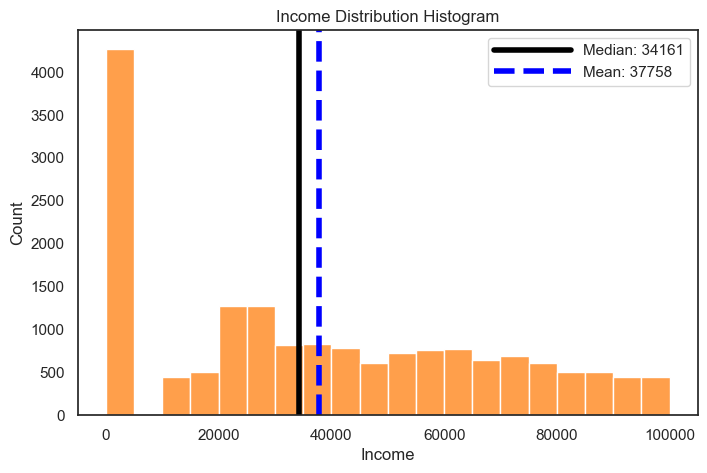

In [45]:
skew_demo = subset_cancellations_na["Income"]

# Clean possible strings like "$12,345" or "12,345" and coerce to numeric
skew_demo = (
    skew_demo.astype(str)
             .str.replace(r"[,$]", "", regex=True)
             .replace(["", "nan", "None"], np.nan)
)
skew_demo = pd.to_numeric(skew_demo, errors="coerce").dropna()

# 2) Your original logic (unchanged)
skew_md = np.median(skew_demo)
skew_mn = np.mean(skew_demo)

sns.set_theme(style="white", palette=None)

fig, ax = plt.subplots(figsize=(8,5))

sns.histplot(skew_demo, bins=20,
             ax=ax, color='tab:orange')

ax.axvline(skew_md, color='black', linewidth=4,
           label='Median: {}'.format(int(skew_md)))
ax.axvline(skew_mn, color='blue', linestyle='dashed', linewidth=4,
           label='Mean: {}'.format(int(skew_mn)))

ax.legend(handlelength=5)

ax.set_title("Income Distribution Histogram")
plt.show()



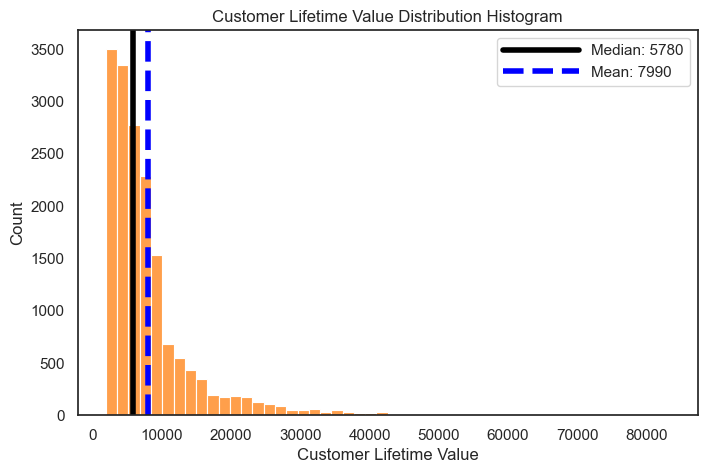

In [46]:
# 1) Build a clean numeric series for Customer Lifetime Value
skew_demo = subset_cancellations_na["Customer Lifetime Value"]

# Clean possible strings like "$12,345.67" or "12,345" and coerce to numeric
skew_demo = (
    skew_demo.astype(str)
             .str.replace(r"[,$]", "", regex=True)
             .replace(["", "nan", "None"], np.nan)
)
skew_demo = pd.to_numeric(skew_demo, errors="coerce").dropna()

# 2) Your original logic (unchanged)
skew_md = np.median(skew_demo)
skew_mn = np.mean(skew_demo)

sns.set_theme(style="white", palette=None)

fig, ax = plt.subplots(figsize=(8,5))

sns.histplot(skew_demo, bins=50,
             ax=ax, color='tab:orange')

ax.axvline(skew_md, color='black', linewidth=4,
           label='Median: {}'.format(int(skew_md)))
ax.axvline(skew_mn, color='blue', linestyle='dashed', linewidth=4,
           label='Mean: {}'.format(int(skew_mn)))

ax.legend(handlelength=5)

ax.set_title("Customer Lifetime Value Distribution Histogram")
plt.show()

sns.set()








In [47]:
subset_cancellations_na.isna().sum()

Loyalty#                    0
Province or State           0
City                        0
Latitude                    0
Longitude                   0
Gender                      0
Education                   0
Income                     20
Marital Status              0
LoyaltyStatus               0
EnrollmentDateOpening       0
CancellationDate            0
Customer Lifetime Value    20
EnrollmentType              0
dtype: int64

In [48]:
subset_cancellations_na.isna().sum()          
subset_cancellations_na.isna().sum().sum()    

np.int64(40)

In [49]:
subset_cancellations_na["Income"] = subset_cancellations_na["Income"].fillna(
    subset_cancellations_na["Income"].median()
)

subset_cancellations_na["Customer Lifetime Value"] = subset_cancellations_na["Customer Lifetime Value"].fillna(
    subset_cancellations_na["Customer Lifetime Value"].median()
)

# sanity check
subset_cancellations_na[["Income", "Customer Lifetime Value"]].isna().sum()

Income                     0
Customer Lifetime Value    0
dtype: int64

In [50]:
subset_cancellations_na.isna().sum()

Loyalty#                   0
Province or State          0
City                       0
Latitude                   0
Longitude                  0
Gender                     0
Education                  0
Income                     0
Marital Status             0
LoyaltyStatus              0
EnrollmentDateOpening      0
CancellationDate           0
Customer Lifetime Value    0
EnrollmentType             0
dtype: int64

In [51]:
subset_customers.isna().sum()

Loyalty#                       0
Province or State              0
City                           0
Latitude                       0
Longitude                      0
Gender                         0
Education                      0
Income                        20
Marital Status                 0
LoyaltyStatus                  0
EnrollmentDateOpening          0
CancellationDate           14611
Customer Lifetime Value       20
EnrollmentType                 0
dtype: int64

In [52]:
subset_cancellations_na.count()

Loyalty#                   16921
Province or State          16921
City                       16921
Latitude                   16921
Longitude                  16921
Gender                     16921
Education                  16921
Income                     16921
Marital Status             16921
LoyaltyStatus              16921
EnrollmentDateOpening      16921
CancellationDate           16921
Customer Lifetime Value    16921
EnrollmentType             16921
dtype: int64

In [53]:
flights.isna().sum()

Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
dtype: int64

In [54]:
subset_cancellations_na.shape

(16921, 14)

In [55]:
subset_cancellations_only = subset_customers[subset_customers["CancellationDate"].notna()].copy()

In [56]:
subset_cancellations_only.isna().sum()

Loyalty#                    0
Province or State           0
City                        0
Latitude                    0
Longitude                   0
Gender                      0
Education                   0
Income                     20
Marital Status              0
LoyaltyStatus               0
EnrollmentDateOpening       0
CancellationDate            0
Customer Lifetime Value    20
EnrollmentType              0
dtype: int64

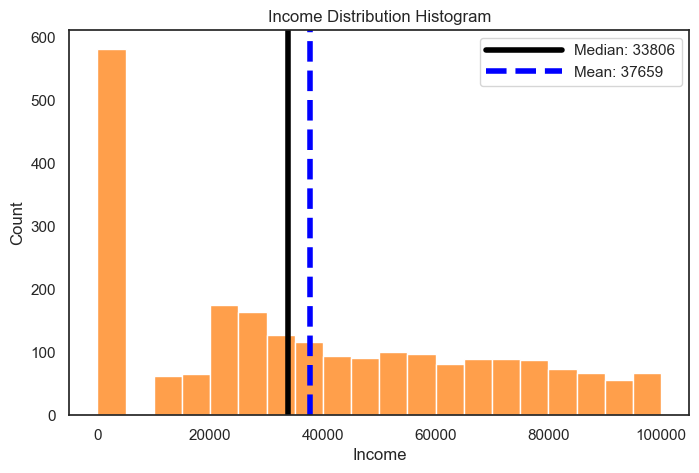

In [57]:
skew_demo = subset_cancellations_only["Income"]

# Clean possible strings like "$12,345" or "12,345" and coerce to numeric
skew_demo = (
    skew_demo.astype(str)
             .str.replace(r"[,$]", "", regex=True)
             .replace(["", "nan", "None"], np.nan)
)
skew_demo = pd.to_numeric(skew_demo, errors="coerce").dropna()

# 2) Your original logic (unchanged)
skew_md = np.median(skew_demo)
skew_mn = np.mean(skew_demo)

sns.set_theme(style="white", palette=None)

fig, ax = plt.subplots(figsize=(8,5))

sns.histplot(skew_demo, bins=20,
             ax=ax, color='tab:orange')

ax.axvline(skew_md, color='black', linewidth=4,
           label='Median: {}'.format(int(skew_md)))
ax.axvline(skew_mn, color='blue', linestyle='dashed', linewidth=4,
           label='Mean: {}'.format(int(skew_mn)))

ax.legend(handlelength=5)

ax.set_title("Income Distribution Histogram")
plt.show()


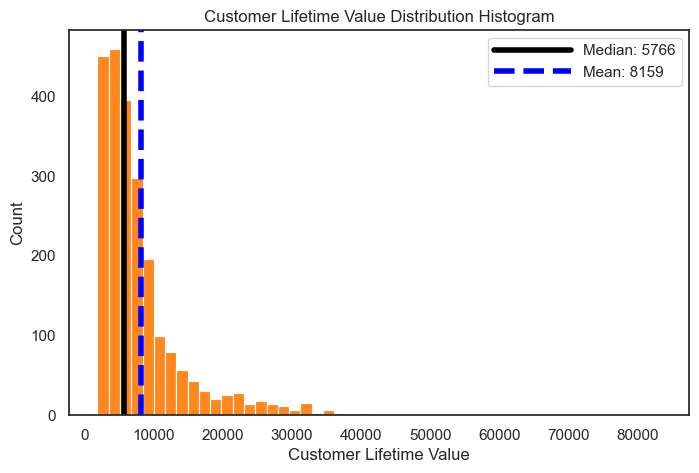

In [58]:
# 1) Build a clean numeric series for Customer Lifetime Value
skew_demo = subset_cancellations_only["Customer Lifetime Value"]

# Clean possible strings like "$12,345.67" or "12,345" and coerce to numeric
skew_demo = (
    skew_demo.astype(str)
             .str.replace(r"[,$]", "", regex=True)
             .replace(["", "nan", "None"], np.nan)
)
skew_demo = pd.to_numeric(skew_demo, errors="coerce").dropna()

# 2) Your original logic (unchanged)
skew_md = np.median(skew_demo)
skew_mn = np.mean(skew_demo)

sns.set_theme(style="white", palette=None)

fig, ax = plt.subplots(figsize=(8,5))

sns.histplot(skew_demo, bins=50,
             ax=ax, color='tab:orange')
sns.histplot(skew_demo, bins=50,
             ax=ax, color='tab:orange')

ax.axvline(skew_md, color='black', linewidth=4,
           label='Median: {}'.format(int(skew_md)))
ax.axvline(skew_mn, color='blue', linestyle='dashed', linewidth=4,
           label='Mean: {}'.format(int(skew_mn)))

ax.legend(handlelength=5)

ax.set_title("Customer Lifetime Value Distribution Histogram")
plt.show()

sns.set()


In [59]:
subset_cancellations_only = subset_customers[subset_customers["CancellationDate"].notna()].copy()

subset_cancellations_only["Income"] = subset_cancellations_only["Income"].fillna(
    subset_cancellations_only["Income"].median()
)
subset_cancellations_only["Customer Lifetime Value"] = subset_cancellations_only["Customer Lifetime Value"].fillna(
    subset_cancellations_only["Customer Lifetime Value"].median()
)

# check
subset_cancellations_only.isna().sum()


Loyalty#                   0
Province or State          0
City                       0
Latitude                   0
Longitude                  0
Gender                     0
Education                  0
Income                     0
Marital Status             0
LoyaltyStatus              0
EnrollmentDateOpening      0
CancellationDate           0
Customer Lifetime Value    0
EnrollmentType             0
dtype: int64

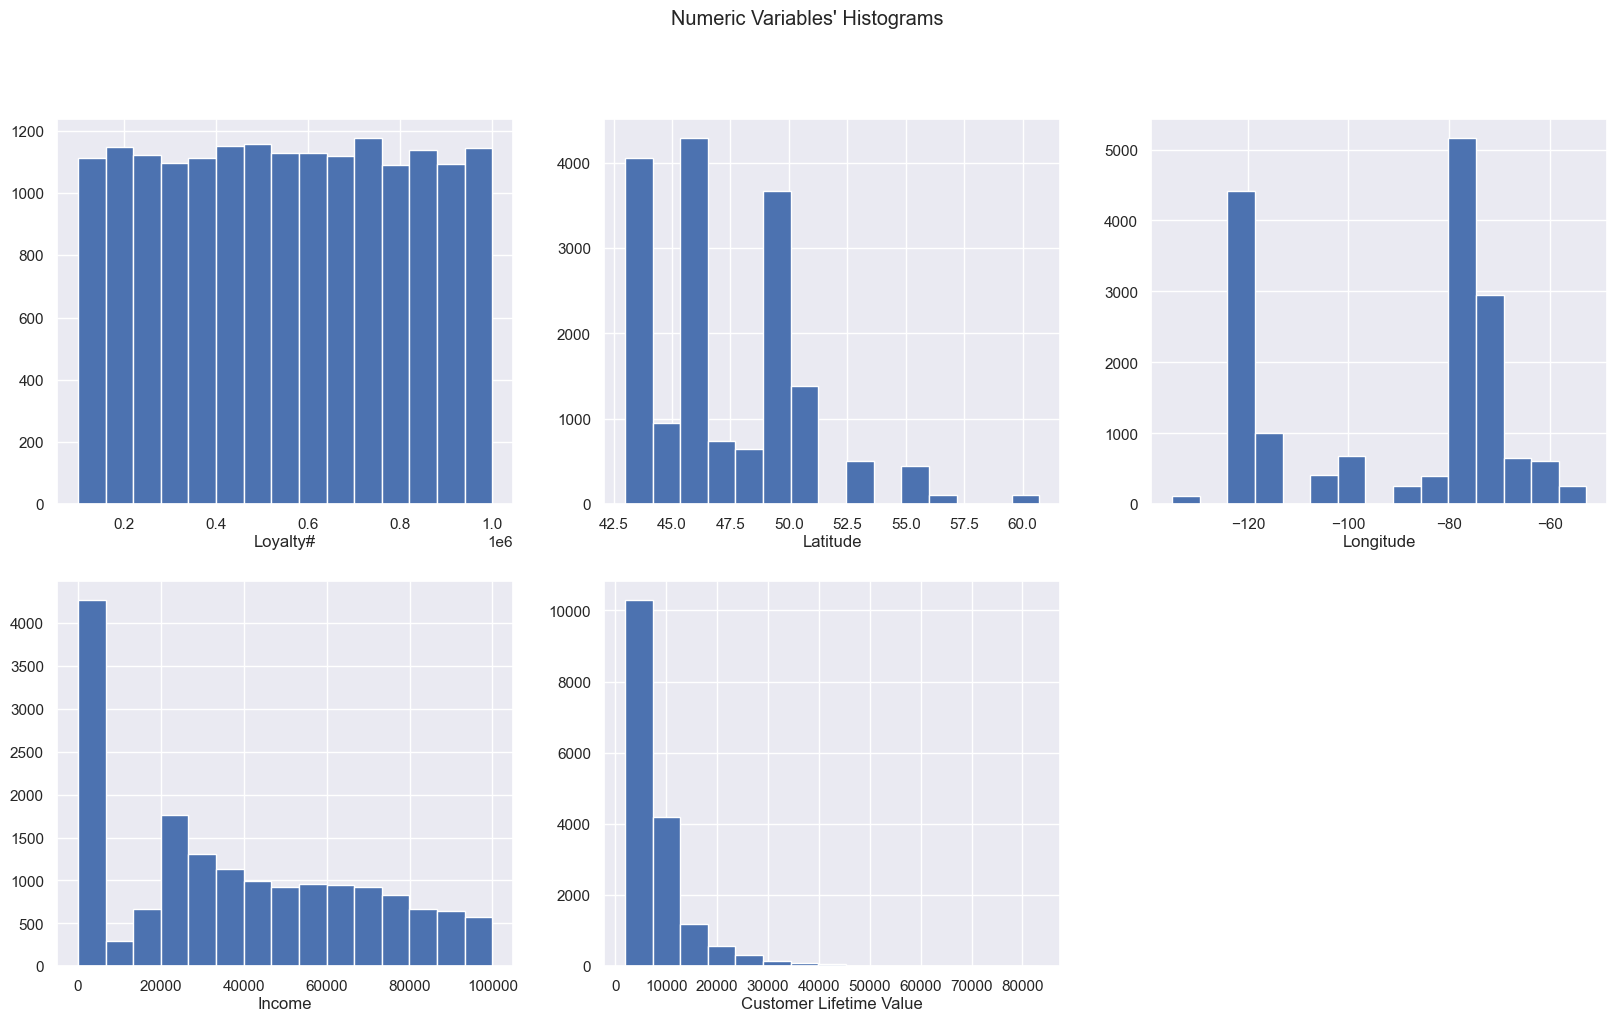

In [60]:
df = subset_cancellations_na

# numeric columns
metric_features = df.select_dtypes(include="number").columns.tolist()

# find & skip all-NaN numeric columns
all_nan_cols = [c for c in metric_features if df[c].isna().all()]
if all_nan_cols:
    print("Skipping all-NaN numeric columns:", all_nan_cols)
metric_features = [c for c in metric_features if c not in all_nan_cols]

sns.set()
fig, axes = plt.subplots(2, ceil(len(metric_features)/2), figsize=(20, 11))
axes = axes.flatten()

for ax, feat in zip(axes, metric_features):
    s = df[feat].dropna()
    if s.empty:
        ax.axis("off")
        continue
    ax.hist(s, bins=15)
    ax.set_title(feat, y=-0.13)

# hide any unused axes
for ax in axes[len(metric_features):]:
    ax.axis("off")

plt.suptitle("Numeric Variables' Histograms")
plt.show()

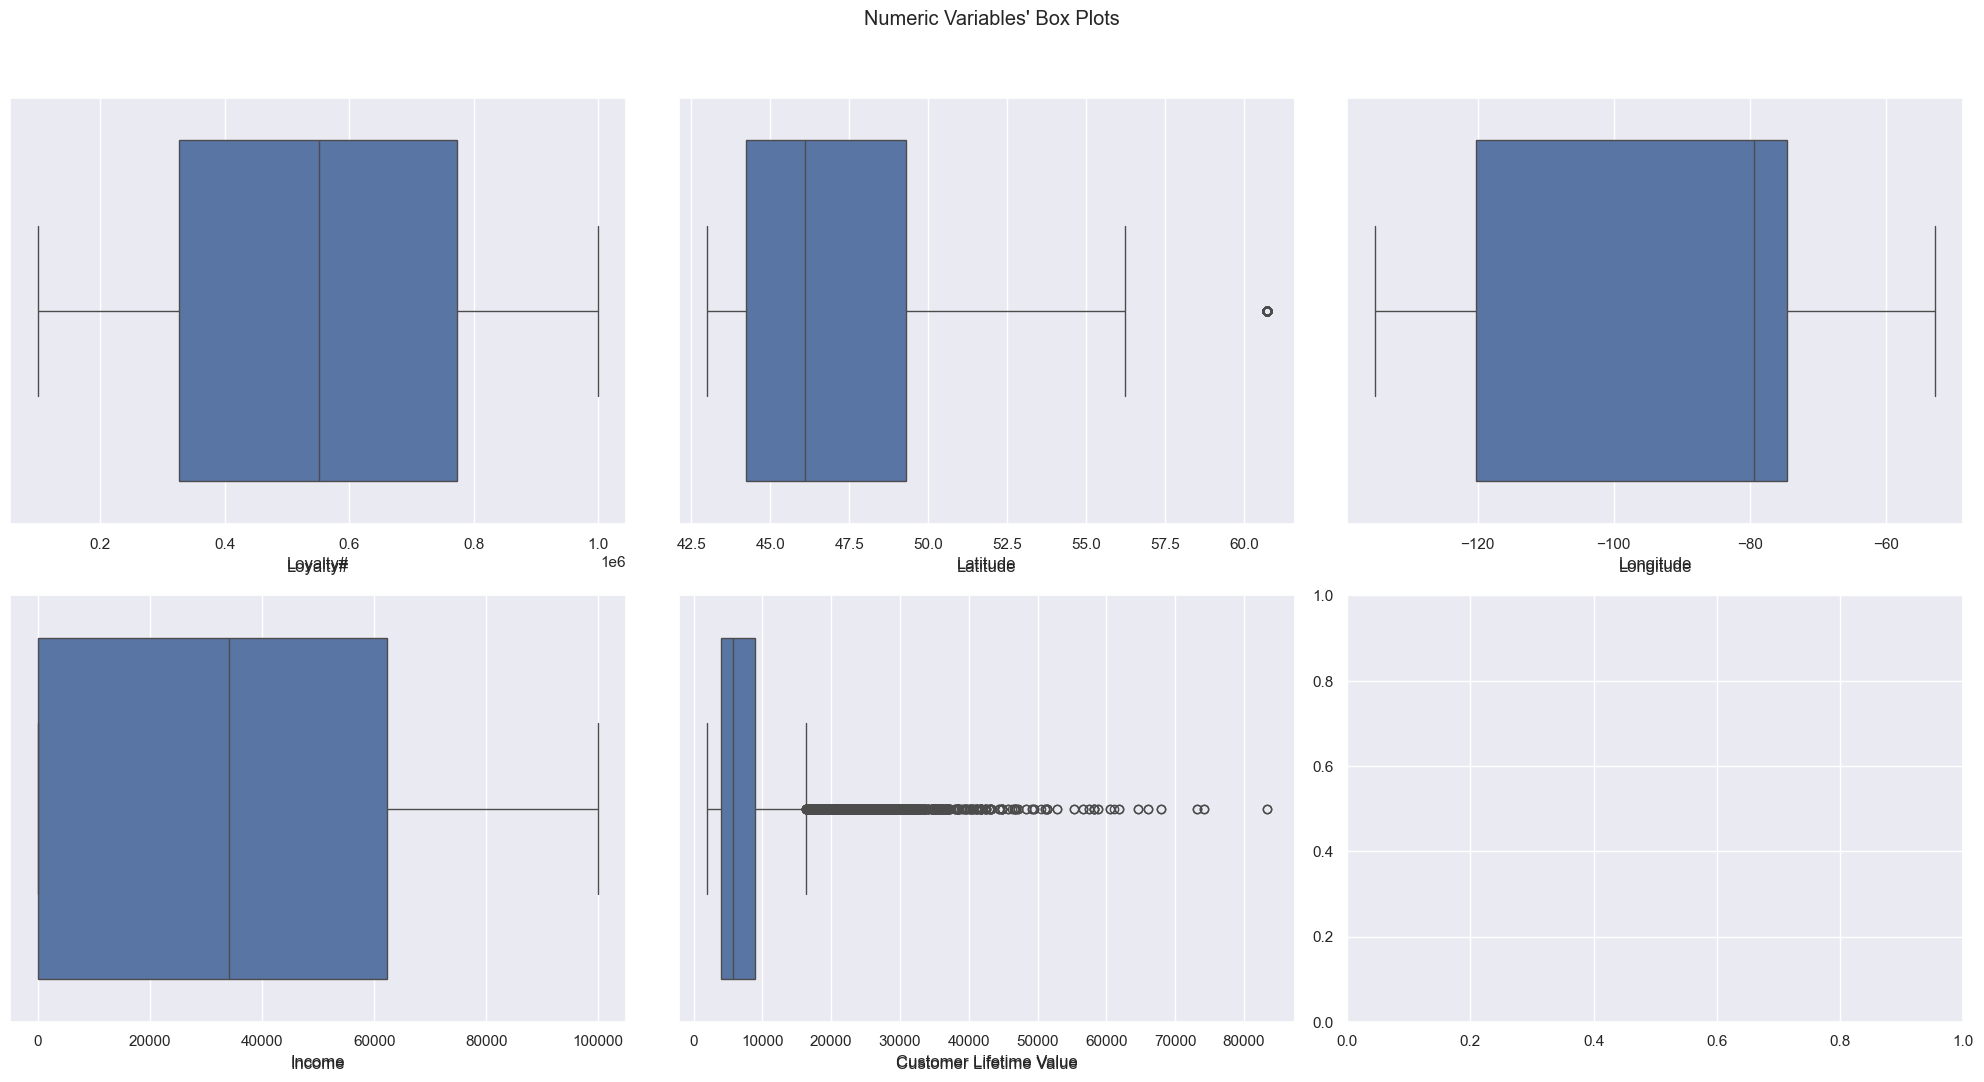

In [61]:
# Keep only numeric columns that aren’t entirely NaN
metric_features = df.select_dtypes(include="number").columns[df.select_dtypes(include="number").notna().any()].tolist()

sns.set()
fig, axes = plt.subplots(2, ceil(len(metric_features)/2), figsize=(20, 11))

for ax, feat in zip(axes.flatten(), metric_features):
    sns.boxplot(x=df[feat], ax=ax)
    ax.set_title(feat, y=-0.13)

plt.suptitle("Numeric Variables' Box Plots")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

In [62]:
filters_man = (
    (subset_cancellations_na['Customer Lifetime Value'] <= 60000)  # keep CLV below ~60k
    & (subset_cancellations_na['Income'] <= 100000)                # optional: filter extreme income
)

subset_cleaned_manual = subset_cancellations_na[filters_man]

# check percentage of data kept
print(
    'Percentage of data kept after removing outliers:',
    100 * np.round(subset_cleaned_manual.shape[0] / subset_cancellations_na.shape[0], 4)
)

Percentage of data kept after removing outliers: 99.9


In [63]:
subset_cancellations_na[
    (subset_cancellations_na['Latitude'] > 90) | 
    (subset_cancellations_na['Latitude'] < -90)
]


,Loyalty#,Province or State,City,Latitude,Longitude,Gender,Education,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType


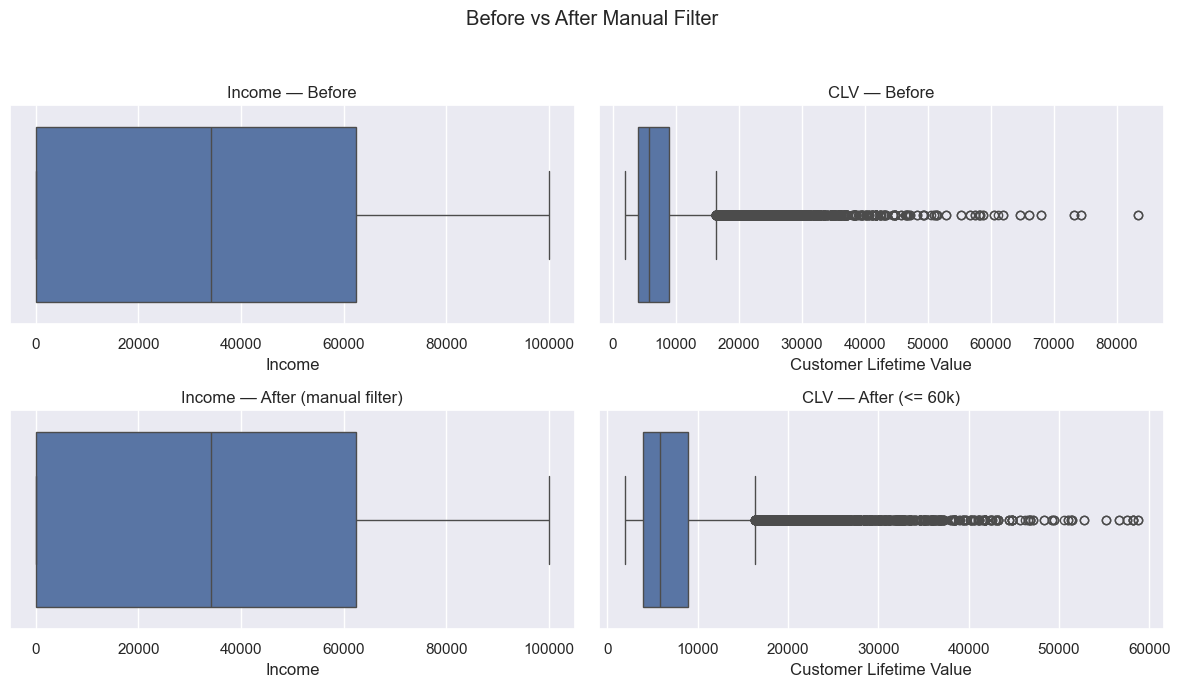

In [64]:
sns.set()
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey='row')

# Income
sns.boxplot(x=subset_cancellations_na["Income"], ax=axes[0,0]);  axes[0,0].set_title("Income — Before")
sns.boxplot(x=subset_cleaned_manual["Income"], ax=axes[1,0]);    axes[1,0].set_title("Income — After (manual filter)")

# CLV
sns.boxplot(x=subset_cancellations_na["Customer Lifetime Value"], ax=axes[0,1]); axes[0,1].set_title("CLV — Before")
sns.boxplot(x=subset_cleaned_manual["Customer Lifetime Value"], ax=axes[1,1]);   axes[1,1].set_title("CLV — After (<= 60k)")

plt.suptitle("Before vs After Manual Filter")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

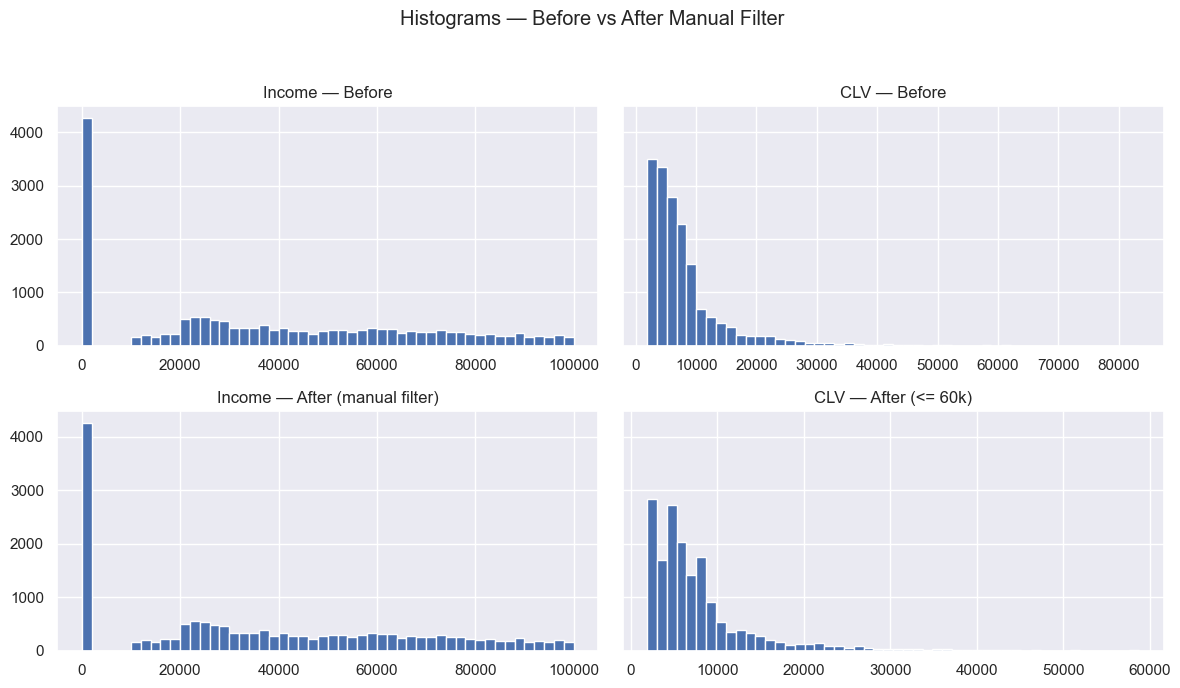

In [65]:
ig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey='row')

# Income
axes[0,0].hist(subset_cancellations_na["Income"].dropna(), bins=50)
axes[0,0].set_title("Income — Before")
axes[1,0].hist(subset_cleaned_manual["Income"].dropna(), bins=50)
axes[1,0].set_title("Income — After (manual filter)")

# Customer Lifetime Value
axes[0,1].hist(subset_cancellations_na["Customer Lifetime Value"].dropna(), bins=50)
axes[0,1].set_title("CLV — Before")
axes[1,1].hist(subset_cleaned_manual["Customer Lifetime Value"].dropna(), bins=50)
axes[1,1].set_title("CLV — After (<= 60k)")

plt.suptitle("Histograms — Before vs After Manual Filter")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

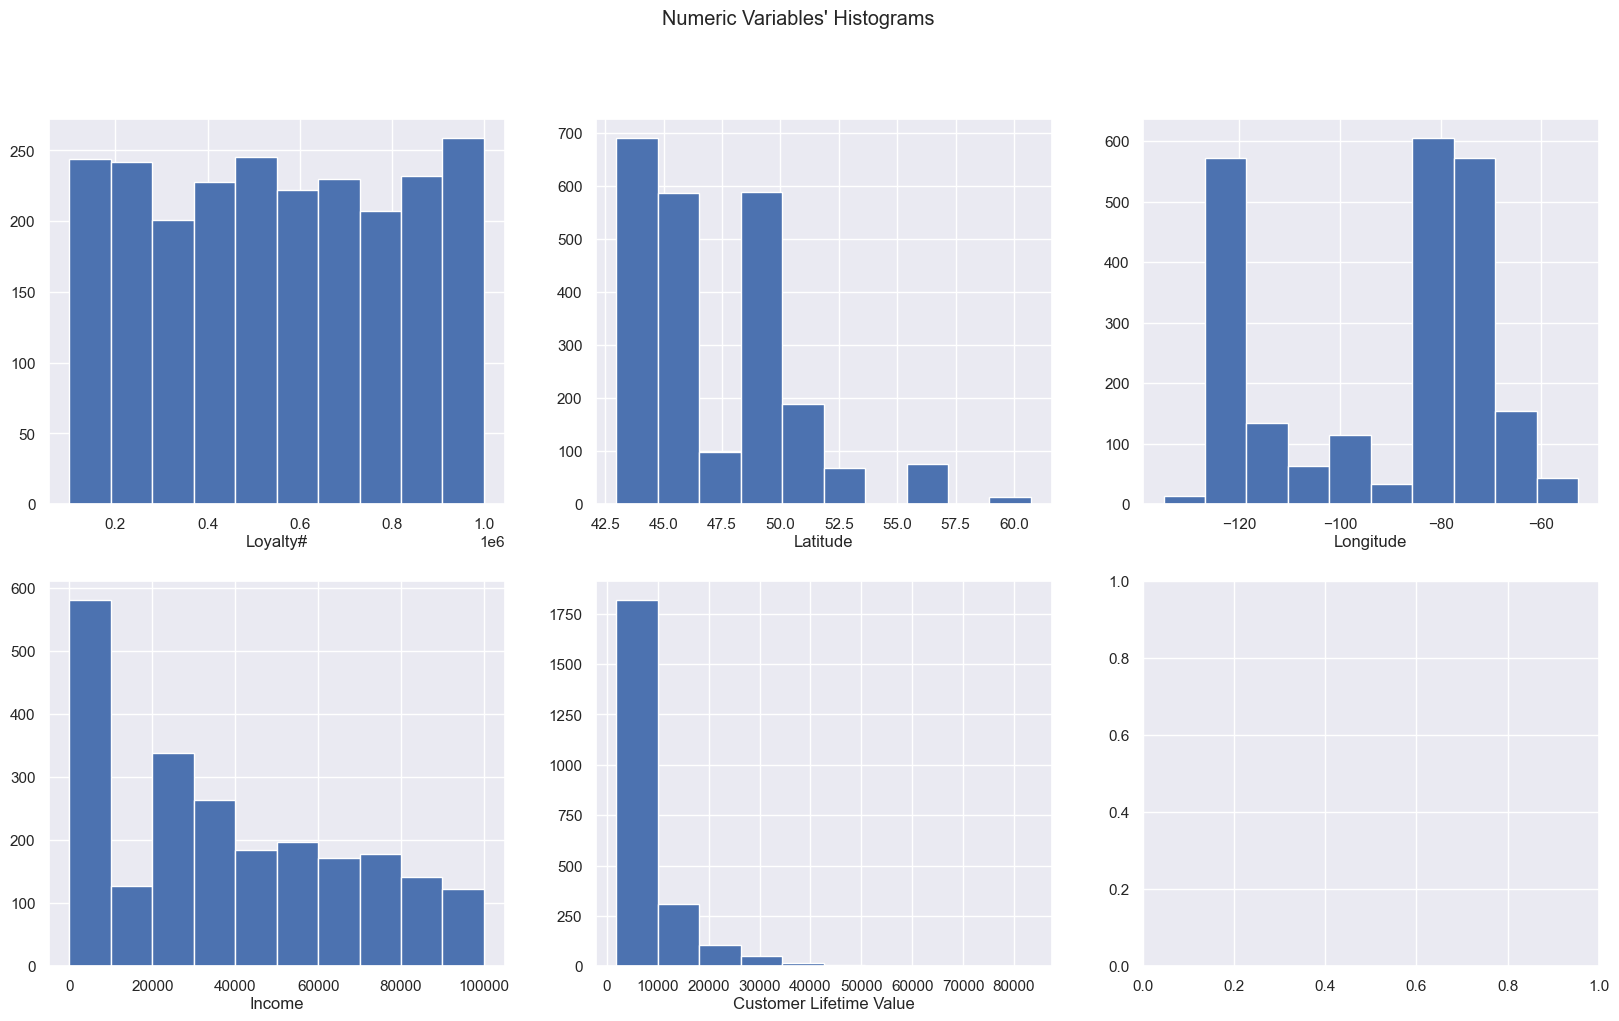

In [66]:
metric_features = subset_cancellations_only.select_dtypes(include="number").columns

# Assign DataFrame
df = subset_cancellations_only

sns.set()
fig, axes = plt.subplots(2, ceil(len(metric_features) / 2), figsize=(20, 11))

for ax, feat in zip(axes.flatten(), metric_features):
    ax.hist(df[feat])
    ax.set_title(feat, y=-0.13)

plt.suptitle("Numeric Variables' Histograms")
plt.show()

In [44]:
subset_cancellations_na.count()

Loyalty#                   2310
Province or State          2310
City                       2310
Latitude                   2310
Longitude                  2310
Gender                     2310
Education                  2310
Income                     2310
Marital Status             2310
LoyaltyStatus              2310
EnrollmentDateOpening      2310
CancellationDate           2310
Customer Lifetime Value    2310
EnrollmentType             2310
dtype: int64

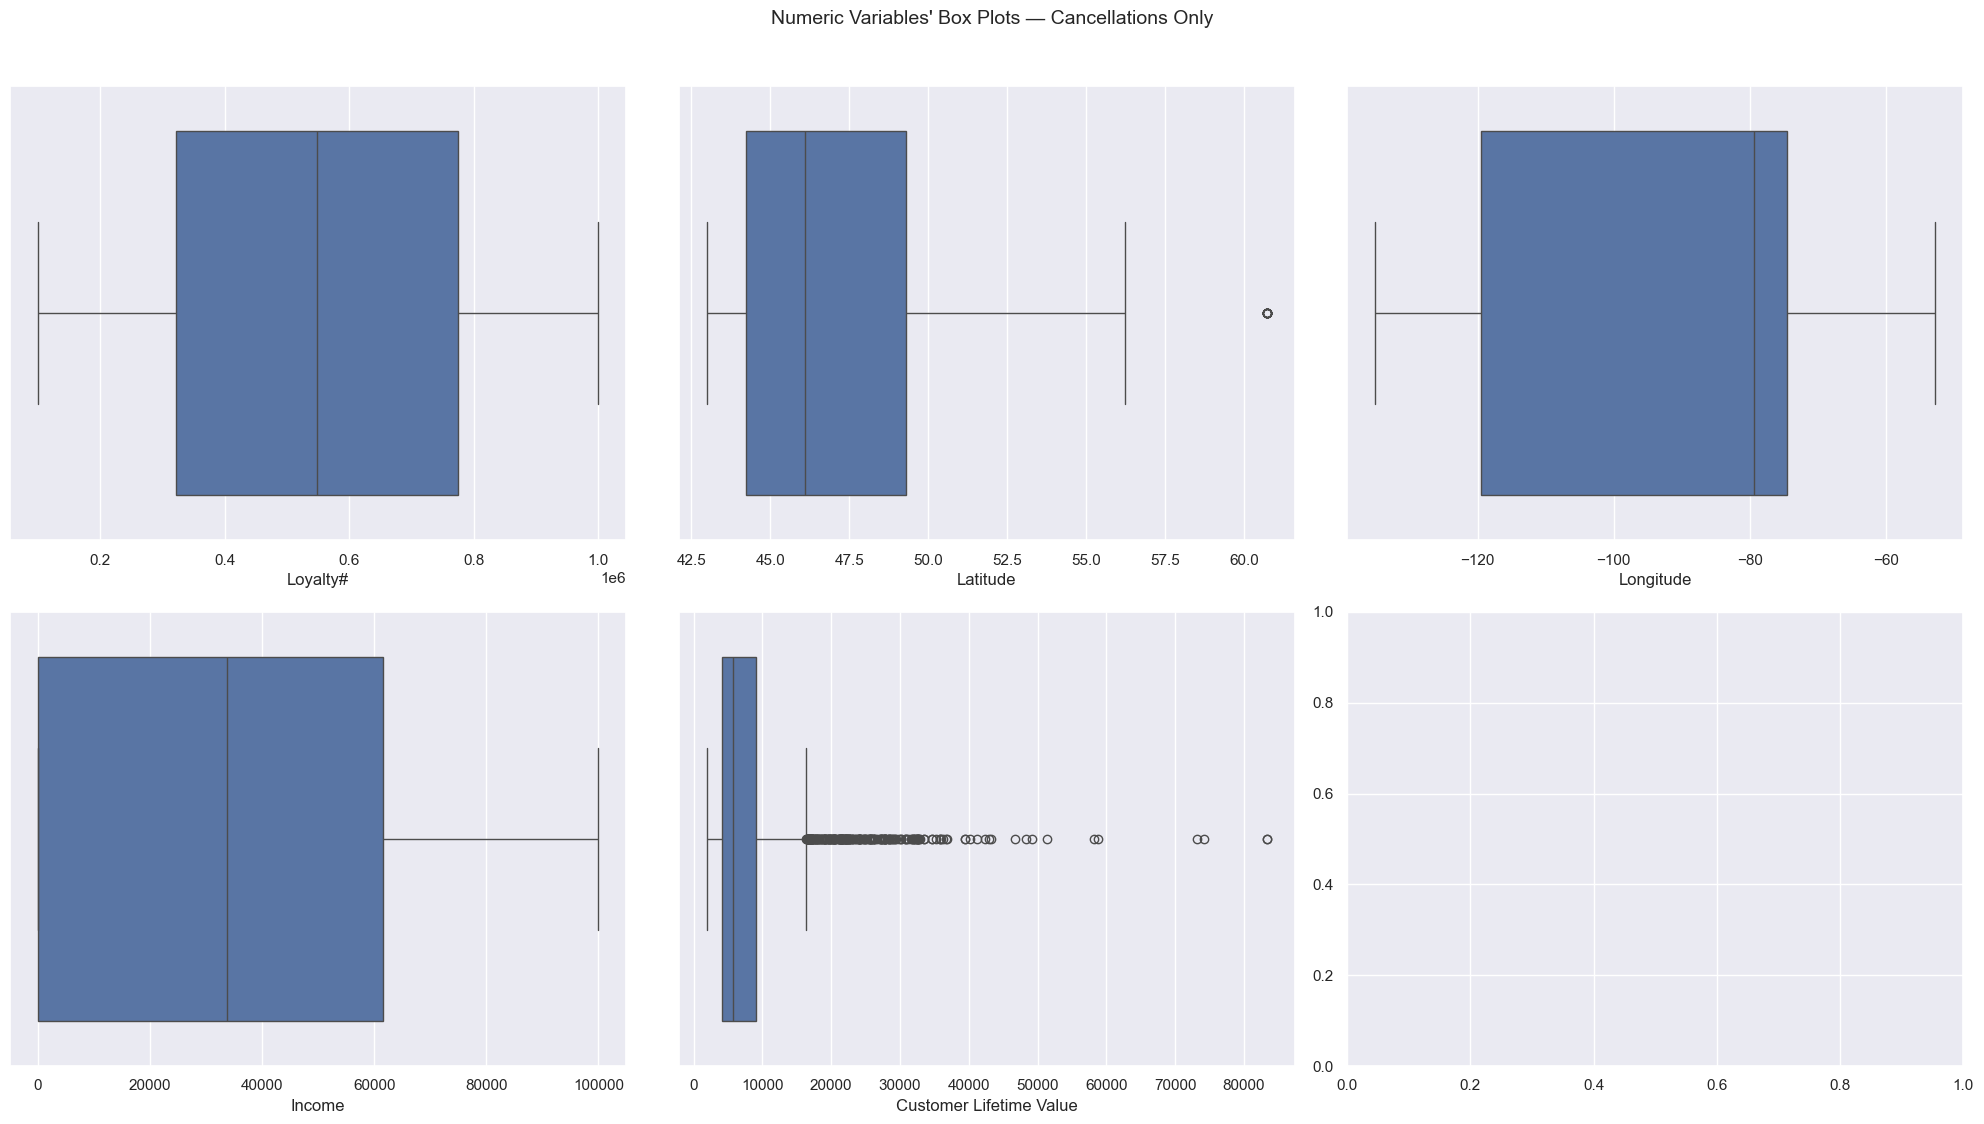

In [39]:
metric_features = subset_cancellations_only.select_dtypes(include="number").columns

df = subset_cancellations_only

sns.set()
fig, axes = plt.subplots(2, ceil(len(metric_features) / 2), figsize=(20, 11))

for ax, feat in zip(axes.flatten(), metric_features):
    sns.boxplot(x=df[feat], ax=ax)
    ax.set_xlabel(feat)  # put label below the boxplot
    ax.set_title("")     # remove the redundant title

plt.suptitle("Numeric Variables' Box Plots — Cancellations Only", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


In [40]:
subset_cancellations_only.count()

Loyalty#                   2310
Province or State          2310
City                       2310
Latitude                   2310
Longitude                  2310
Gender                     2310
Education                  2310
Income                     2310
Marital Status             2310
LoyaltyStatus              2310
EnrollmentDateOpening      2310
CancellationDate           2310
Customer Lifetime Value    2310
EnrollmentType             2310
dtype: int64

In [91]:
filters_man = (
    (subset_cancellations_only['Customer Lifetime Value'] <= 60000)  # keep CLV below ~60k
    & (subset_cancellations_only['Income'] <= 100000)                # optional: filter extreme income
)

subset_cleaned_manual = subset_cancellations_only[filters_man]

# check percentage of data kept
print(
    'Percentage of data kept after removing outliers:',
    100 * np.round(subset_cleaned_manual.shape[0] / subset_cancellations_only.shape[0], 4)
)

Percentage of data kept after removing outliers: 99.83


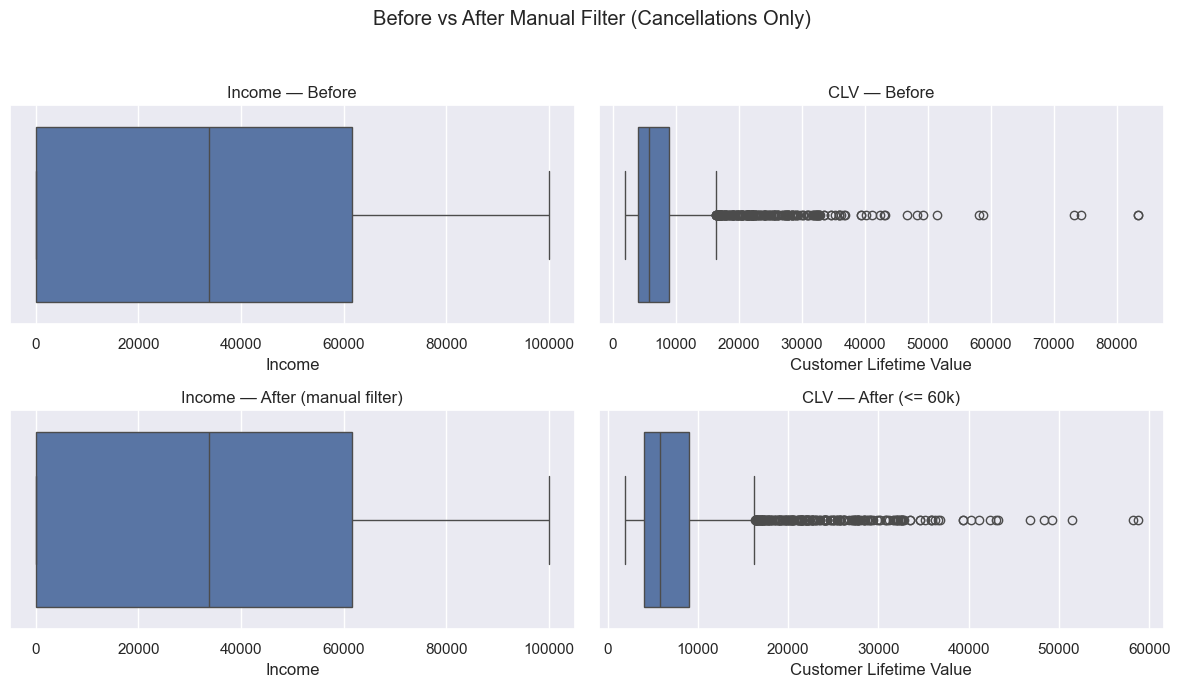

In [92]:
sns.set()
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey='row')

# Income
sns.boxplot(x=subset_cancellations_only["Income"], ax=axes[0,0]);  axes[0,0].set_title("Income — Before")
sns.boxplot(x=subset_cleaned_manual["Income"],      ax=axes[1,0]);  axes[1,0].set_title("Income — After (manual filter)")

# CLV
sns.boxplot(x=subset_cancellations_only["Customer Lifetime Value"], ax=axes[0,1]); axes[0,1].set_title("CLV — Before")
sns.boxplot(x=subset_cleaned_manual["Customer Lifetime Value"],      ax=axes[1,1]); axes[1,1].set_title("CLV — After (<= 60k)")

plt.suptitle("Before vs After Manual Filter (Cancellations Only)")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


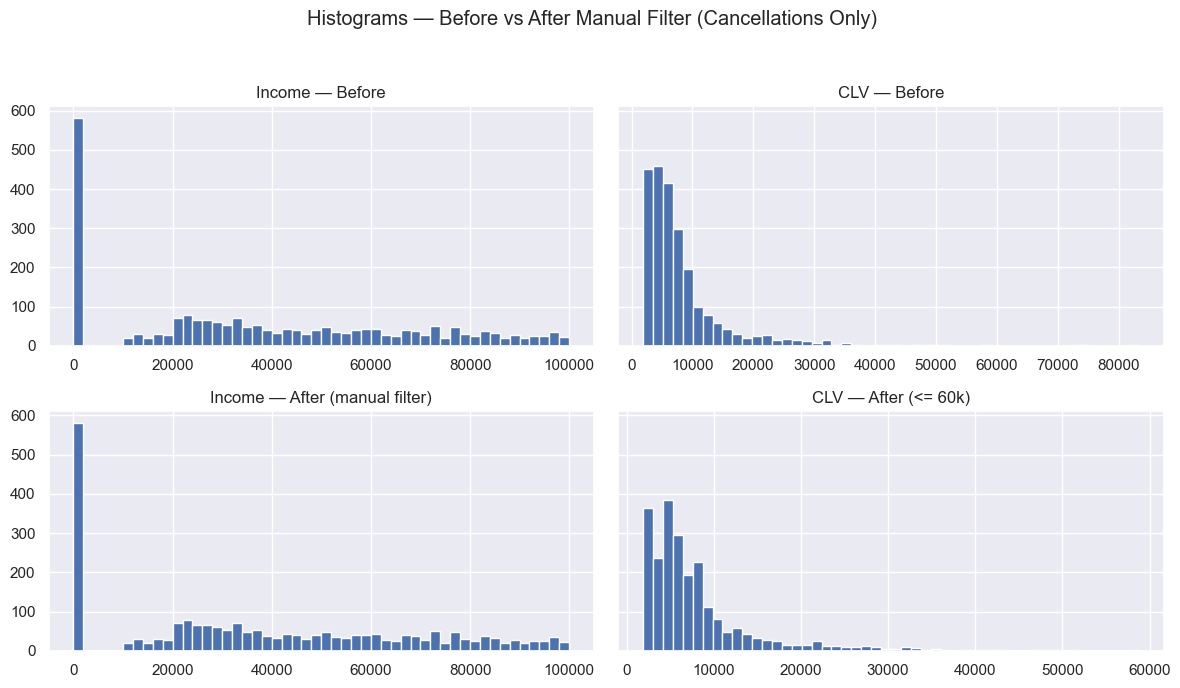

In [93]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey='row')

axes[0,0].hist(subset_cancellations_only["Income"].dropna(), bins=50);  axes[0,0].set_title("Income — Before")
axes[1,0].hist(subset_cleaned_manual["Income"].dropna(),      bins=50);  axes[1,0].set_title("Income — After (manual filter)")

axes[0,1].hist(subset_cancellations_only["Customer Lifetime Value"].dropna(), bins=50); axes[0,1].set_title("CLV — Before")
axes[1,1].hist(subset_cleaned_manual["Customer Lifetime Value"].dropna(),      bins=50); axes[1,1].set_title("CLV — After (<= 60k)")

plt.suptitle("Histograms — Before vs After Manual Filter (Cancellations Only)")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

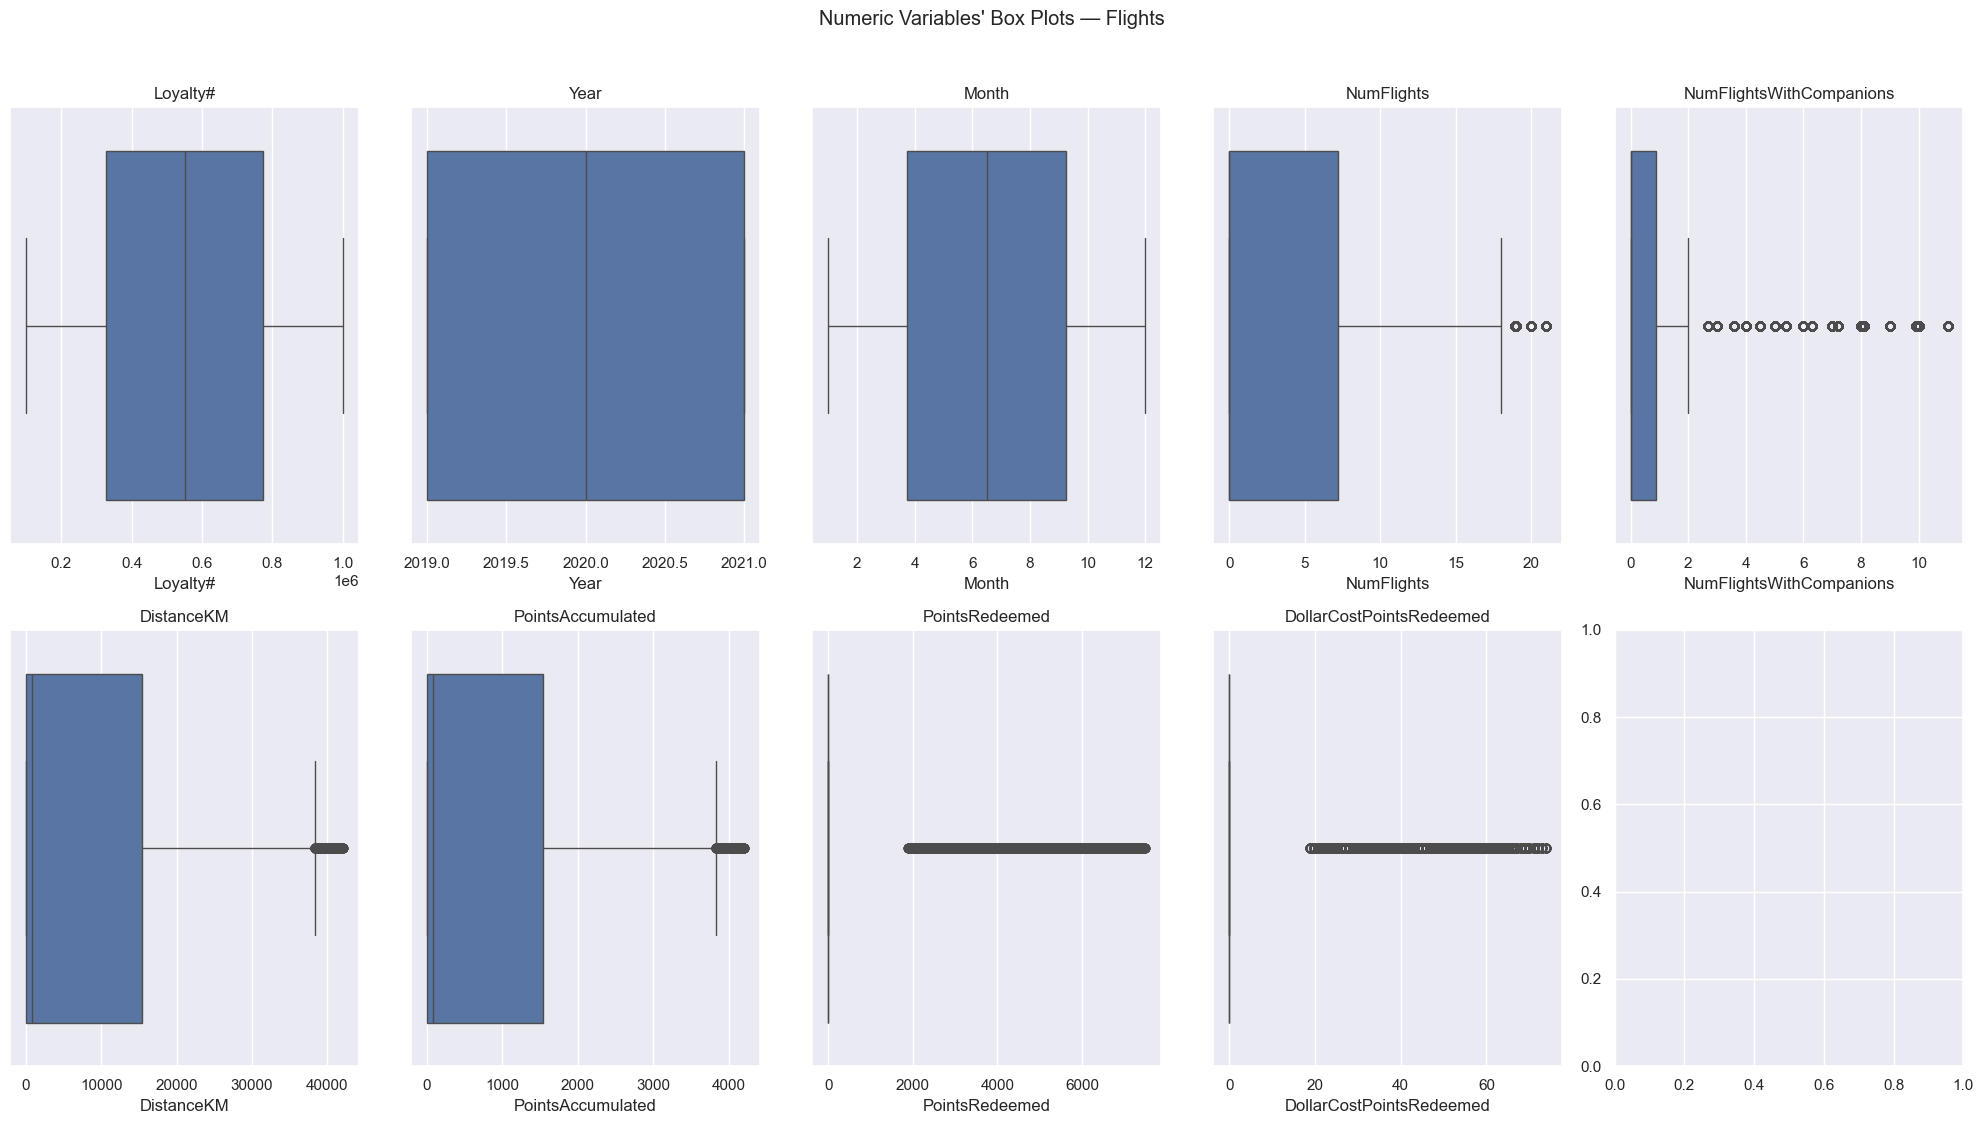

In [94]:
# numeric columns from flights
metric_features = flights.select_dtypes(include="number").columns
df = flights

sns.set()
fig, axes = plt.subplots(2, ceil(len(metric_features) / 2), figsize=(20, 11))

for ax, feat in zip(axes.flatten(), metric_features):
    sns.boxplot(x=df[feat], ax=ax)
    ax.set_title(feat)  # <-- fixed (no y offset so it won't overlap labels)

plt.suptitle("Numeric Variables' Box Plots — Flights", y=1.02)
plt.tight_layout()
plt.show()

In [95]:
flights["NumFlightsWithCompanions"].value_counts().sort_index()


NumFlightsWithCompanions
0.0     448398
0.9       8368
1.0      17905
1.8       8636
2.0      19272
2.7       8509
3.0      19015
3.6       7138
4.0      13665
4.5       5938
5.0      13424
5.4       5204
6.0       9911
6.3       3508
7.0       7089
7.2       1940
8.0       3965
8.1       1356
9.0       3443
9.9        205
10.0      1071
11.0       476
Name: count, dtype: int64

In [96]:
perc_above_8 = (
    (flights["NumFlightsWithCompanions"] > 8).sum() / len(flights)
) * 100

print(f"Percentage of records with NumFlightsWithCompanions > 8: {perc_above_8:.2f}%")

Percentage of records with NumFlightsWithCompanions > 8: 1.08%


In [98]:
flights.count()

Loyalty#                    608436
Year                        608436
Month                       608436
YearMonthDate               608436
NumFlights                  608436
NumFlightsWithCompanions    608436
DistanceKM                  608436
PointsAccumulated           608436
PointsRedeemed              608436
DollarCostPointsRedeemed    608436
dtype: int64

In [99]:
df_original = flights

# Column to check
col = "NumFlightsWithCompanions"
s = df_original[col].dropna()

# IQR rule (keep if within whiskers)
q1, q3 = s.quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
mask_iqr = df_original[col].between(lo, hi, inclusive="both")

# Manual rule (example: keep values <= 8 companions)
mask_manual = df_original[col] <= 8

# Keep if passes either rule (OR)
keep_mask = mask_iqr | mask_manual
df_out = df_original[keep_mask]

print(
    "Percentage of data kept after filtering:",
    np.round(df_out.shape[0] / df_original.shape[0] * 100, 2), "%"
)

Percentage of data kept after filtering: 98.92 %


In [102]:
flights.count()

Loyalty#                    608436
Year                        608436
Month                       608436
YearMonthDate               608436
NumFlights                  608436
NumFlightsWithCompanions    608436
DistanceKM                  608436
PointsAccumulated           608436
PointsRedeemed              608436
DollarCostPointsRedeemed    608436
dtype: int64

In [103]:
# Use IQR to filter NumFlights (same pattern as your template)

df = flights
metric_features = ["NumFlights"]

# Compute the IQR
q1 = df[metric_features].quantile(.25)

# Calculate Q3
q3 = df[metric_features].quantile(.75)

# Calculate IQR
iqr = (q3 - q1)

# Compute upper and lower limits
lower_lim = q1 - (1.5 * iqr)
upper_lim = q3 + (1.5 * iqr)

filters_iqr = []
for metric in metric_features:
    llim = lower_lim[metric]
    ulim = upper_lim[metric]
    filters_iqr.append(df[metric].between(llim, ulim, inclusive='neither'))

filters_iqr_all = pd.Series(np.all(filters_iqr, 0), index=df.index)

# Apply filter
df_iqr_clean = df[filters_iqr_all]

print('Percentage of data kept after IQR filtering:',
      100 * np.round(df_iqr_clean.shape[0] / df.shape[0], 4))


Percentage of data kept after IQR filtering: 98.86


In [105]:
flights.count()

Loyalty#                    608436
Year                        608436
Month                       608436
YearMonthDate               608436
NumFlights                  608436
NumFlightsWithCompanions    608436
DistanceKM                  608436
PointsAccumulated           608436
PointsRedeemed              608436
DollarCostPointsRedeemed    608436
dtype: int64

In [106]:
flights["DistanceKM"] = pd.to_numeric(flights["DistanceKM"], errors="coerce")
print(flights["DistanceKM"].dtype)
print(flights["DistanceKM"].describe())

float64
count    608436.000000
mean       7939.341419
std       10260.421873
min           0.000000
25%           0.000000
50%         856.400000
75%       15338.175000
max       42040.000000
Name: DistanceKM, dtype: float64


In [ ]:
flights.isna().sum()

In [107]:
# Count and percentage of zeros in DistanceKM
zero_count = (flights["DistanceKM"] == 0).sum()
zero_pct = (flights["DistanceKM"] == 0).mean() * 100

print(f"Number of zeros in DistanceKM: {zero_count}")
print(f"Percentage of zeros: {zero_pct:.2f}%")


Number of zeros in DistanceKM: 298623
Percentage of zeros: 49.08%


In [110]:
flights.count()


Loyalty#                    608436
Year                        608436
Month                       608436
YearMonthDate               608436
NumFlights                  608436
NumFlightsWithCompanions    608436
DistanceKM                  608436
PointsAccumulated           608436
PointsRedeemed              608436
DollarCostPointsRedeemed    608436
dtype: int64

In [112]:
flights.isna().sum()

Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
dtype: int64

In [113]:
flights["HasFlown"] = flights["DistanceKM"].notna().astype(int)


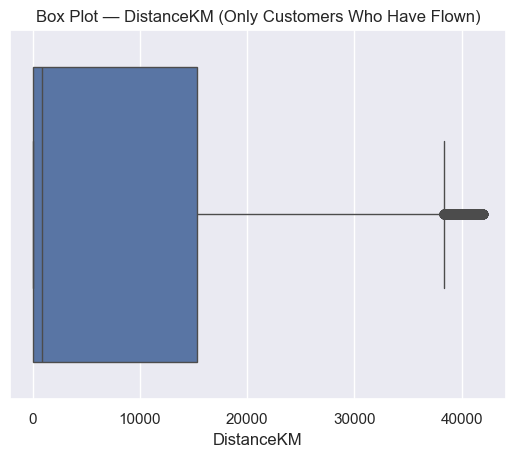

In [114]:
# Filter for customers who have flown
flown_df = flights[flights["HasFlown"] == 1]

# Box plot of DistanceKM for those customers only
sns.boxplot(x=flown_df["DistanceKM"])
plt.title("Box Plot — DistanceKM (Only Customers Who Have Flown)")
plt.show()

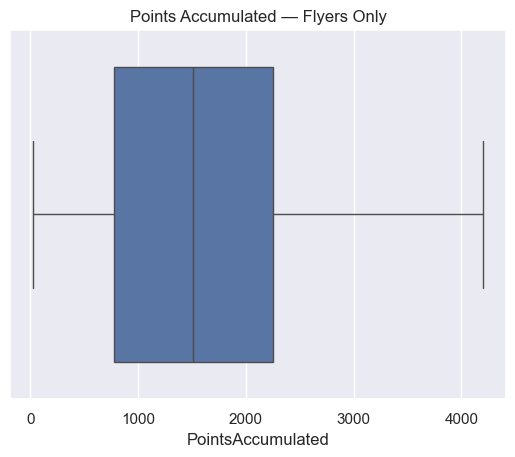

In [115]:
flyers = flights[flights["DistanceKM"].fillna(0) > 0].copy()
sns.boxplot(x=flyers["PointsAccumulated"])
plt.title("Points Accumulated — Flyers Only")
plt.show()

In [116]:
flights["NumFlightsWithCompanions"].value_counts().sort_index()

NumFlightsWithCompanions
0.0     448398
0.9       8368
1.0      17905
1.8       8636
2.0      19272
2.7       8509
3.0      19015
3.6       7138
4.0      13665
4.5       5938
5.0      13424
5.4       5204
6.0       9911
6.3       3508
7.0       7089
7.2       1940
8.0       3965
8.1       1356
9.0       3443
9.9        205
10.0      1071
11.0       476
Name: count, dtype: int64

In [117]:
flights.count()

Loyalty#                    608436
Year                        608436
Month                       608436
YearMonthDate               608436
NumFlights                  608436
NumFlightsWithCompanions    608436
DistanceKM                  608436
PointsAccumulated           608436
PointsRedeemed              608436
DollarCostPointsRedeemed    608436
HasFlown                    608436
dtype: int64

In [118]:
zero_pct = (flights["PointsRedeemed"] == 0).mean() * 100
print(f"Percentage of customers with 0 points redeemed: {zero_pct:.2f}%")


Percentage of customers with 0 points redeemed: 94.18%


In [119]:
# Binary flag for customers who have redeemed points
flights["HasRedeemedPoints"] = (flights["PointsRedeemed"] > 0).astype(int)

# Quick check
flights["HasRedeemedPoints"].value_counts(normalize=True) * 100

HasRedeemedPoints
0    94.182954
1     5.817046
Name: proportion, dtype: float64

In [120]:
zero_pct = (flights["DollarCostPointsRedeemed"] == 0).mean() * 100
print(f"Percentage of customers with 0 dollar cost points redeemed: {zero_pct:.2f}%")


Percentage of customers with 0 dollar cost points redeemed: 94.18%


In [122]:
print("✅ DATA CLEANING SUMMARY")
print("=" * 30)

# Show basic info
print(f"\nsubset_cancellations_na → {subset_cancellations_na.shape[0]} rows, {subset_cancellations_na.shape[1]} columns")
print(f"subset_cancellations_only → {subset_cancellations_only.shape[0]} rows, {subset_cancellations_only.shape[1]} columns")
print(f"flights → {flights.shape[0]} rows, {flights.shape[1]} columns")

# Count total missing values for each
print("\nMissing values (remaining after cleaning):")
print("subset_cancellations_na:\n", subset_cancellations_na.isna().sum().sum(), "total missing values")
print("subset_cancellations_only:\n", subset_cancellations_only.isna().sum().sum(), "total missing values")
print("flights:\n", flights.isna().sum().sum(), "total missing values")

print("\n✅ All datasets cleaned and visualized successfully!")

✅ DATA CLEANING SUMMARY

subset_cancellations_na → 16921 rows, 14 columns
subset_cancellations_only → 2310 rows, 14 columns
flights → 608436 rows, 12 columns

Missing values (remaining after cleaning):
subset_cancellations_na:
 16921 total missing values
subset_cancellations_only:
 0 total missing values
flights:
 0 total missing values

✅ All datasets cleaned and visualized successfully!


In [24]:
#inputed all the data
import sqlite3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil

In [25]:
customers = pd.read_csv("DM_AIAI_CustomerDB (1).csv")

In [26]:
flights = pd.read_csv("DM_AIAI_FlightsDB (1).csv")

In [27]:
customers.shape

(16921, 21)

In [28]:
flights.shape

(608436, 10)

In [29]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16921 entries, 0 to 16920
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               16921 non-null  int64  
 1   Loyalty#                 16921 non-null  int64  
 2   First Name               16921 non-null  object 
 3   Last Name                16921 non-null  object 
 4   Customer Name            16921 non-null  object 
 5   Country                  16921 non-null  object 
 6   Province or State        16921 non-null  object 
 7   City                     16921 non-null  object 
 8   Latitude                 16921 non-null  float64
 9   Longitude                16921 non-null  float64
 10  Postal code              16921 non-null  object 
 11  Gender                   16921 non-null  object 
 12  Education                16921 non-null  object 
 13  Location Code            16921 non-null  object 
 14  Income                

In [30]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608436 entries, 0 to 608435
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Loyalty#                  608436 non-null  int64  
 1   Year                      608436 non-null  int64  
 2   Month                     608436 non-null  int64  
 3   YearMonthDate             608436 non-null  object 
 4   NumFlights                608436 non-null  float64
 5   NumFlightsWithCompanions  608436 non-null  float64
 6   DistanceKM                608436 non-null  float64
 7   PointsAccumulated         608436 non-null  float64
 8   PointsRedeemed            608436 non-null  float64
 9   DollarCostPointsRedeemed  608436 non-null  float64
dtypes: float64(6), int64(3), object(1)
memory usage: 46.4+ MB


In [31]:
customers.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,16921.0,NaN,NaN,NaN,8440.023639,4884.775439,0.0,4210.0,8440.0,12670.0,16900.0
Loyalty#,16921.0,NaN,NaN,NaN,550197.393771,259251.503597,100011.0,326823.0,550896.0,772438.0,999999.0
First Name,16921,4941,Deon,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Last Name,16921,15404,Salberg,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,16921,16921,Emma Martin,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,16921,1,Canada,16921,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Province or State,16921,11,Ontario,5468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,16921,29,Toronto,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,16921.0,NaN,NaN,NaN,47.1745,3.307971,42.984924,44.231171,46.087818,49.28273,60.721188
Longitude,16921.0,NaN,NaN,NaN,-91.814768,22.242429,-135.05684,-120.23766,-79.383186,-74.596184,-52.712578


In [32]:
customers.describe(include=['object']).transpose()

,count,unique,top,freq
First Name,16921,4941,Deon,13
Last Name,16921,15404,Salberg,4
Customer Name,16921,16921,Emma Martin,1
Country,16921,1,Canada,16921
Province or State,16921,11,Ontario,5468
City,16921,29,Toronto,3390
Postal code,16921,75,V6E 3D9,917
Gender,16921,2,female,8497
Education,16921,5,Bachelor,10586
Location Code,16921,3,Suburban,5716


In [33]:
flights.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loyalty#,608436.0,NaN,NaN,NaN,550037.873084,258935.180575,100018.0,326961.0,550834.0,772194.0,999986.0
Year,608436.0,NaN,NaN,NaN,2020.0,0.816497,2019.0,2019.0,2020.0,2021.0,2021.0
Month,608436.0,NaN,NaN,NaN,6.5,3.452055,1.0,3.75,6.5,9.25,12.0
YearMonthDate,608436,36,12/1/2021,16901,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NumFlights,608436.0,NaN,NaN,NaN,3.908107,5.057889,0.0,0.0,0.0,7.2,21.0
NumFlightsWithCompanions,608436.0,NaN,NaN,NaN,0.983944,2.003785,0.0,0.0,0.0,0.9,11.0
DistanceKM,608436.0,NaN,NaN,NaN,7939.341419,10260.421873,0.0,0.0,856.4,15338.175,42040.0
PointsAccumulated,608436.0,NaN,NaN,NaN,793.777781,1025.918521,0.0,0.0,85.275,1533.7125,4204.0
PointsRedeemed,608436.0,NaN,NaN,NaN,235.251678,983.233374,0.0,0.0,0.0,0.0,7496.0
DollarCostPointsRedeemed,608436.0,NaN,NaN,NaN,2.324835,9.725168,0.0,0.0,0.0,0.0,74.0


In [34]:
flights.describe(include=['object']).transpose()

,count,unique,top,freq
YearMonthDate,608436,36,12/1/2021,16901


In [35]:
subset_cols = [
    "Loyalty#","Province or State","City","Latitude","Longitude",
    "Gender","Education","Income","Marital Status","LoyaltyStatus",
    "EnrollmentDateOpening","CancellationDate",'Customer Lifetime Value',"EnrollmentType"
]

In [36]:
# 2) make the subset ONCE using the list
subset_customers = customers.loc[:, subset_cols]


In [37]:
print(subset_customers)

       Loyalty# Province or State          City   Latitude   Longitude  \
0        480934           Ontario       Toronto  43.653225  -79.383186   
1        549612           Alberta      Edmonton  53.544388 -113.490930   
2        429460  British Columbia     Vancouver  49.282730 -123.120740   
3        608370           Ontario       Toronto  43.653225  -79.383186   
4        530508            Quebec          Hull  45.428730  -75.713364   
...         ...               ...           ...        ...         ...   
16916    100012            Quebec   Quebec City  46.759733  -71.141009   
16917    100013           Alberta      Edmonton  53.524829 -113.546357   
16918    100014     New Brunswick       Moncton  46.051866  -64.825428   
16919    100015            Quebec   Quebec City  46.862970  -71.133444   
16920    100016  British Columbia  Dawson Creek  55.720562 -120.160090   

       Gender Education   Income Marital Status LoyaltyStatus  \
0      female  Bachelor  70146.0        Marrie

In [38]:
subset_customers.describe(include=['object']).transpose()

,count,unique,top,freq
Province or State,16921,11,Ontario,5468
City,16921,29,Toronto,3390
Gender,16921,2,female,8497
Education,16921,5,Bachelor,10586
Marital Status,16921,3,Married,9842
LoyaltyStatus,16921,3,Star,7761
EnrollmentDateOpening,16921,2449,4/3/2015,34
CancellationDate,2310,1260,7/7/2020,8
EnrollmentType,16921,2,Standard,15773


In [39]:
subset_customers.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loyalty#,16921.0,NaN,NaN,NaN,550197.393771,259251.503597,100011.0,326823.0,550896.0,772438.0,999999.0
Province or State,16921,11,Ontario,5468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,16921,29,Toronto,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,16921.0,NaN,NaN,NaN,47.1745,3.307971,42.984924,44.231171,46.087818,49.28273,60.721188
Longitude,16921.0,NaN,NaN,NaN,-91.814768,22.242429,-135.05684,-120.23766,-79.383186,-74.596184,-52.712578
Gender,16921,2,female,8497,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,16921,5,Bachelor,10586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,16901.0,NaN,NaN,NaN,37758.0384,30368.992499,0.0,0.0,34161.0,62396.0,99981.0
Marital Status,16921,3,Married,9842,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LoyaltyStatus,16921,3,Star,7761,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
subset_customers.isna().sum()

Loyalty#                       0
Province or State              0
City                           0
Latitude                       0
Longitude                      0
Gender                         0
Education                      0
Income                        20
Marital Status                 0
LoyaltyStatus                  0
EnrollmentDateOpening          0
CancellationDate           14611
Customer Lifetime Value       20
EnrollmentType                 0
dtype: int64

In [44]:
subset_cancellations_na.loc[:, "CancellationDate"] = subset_cancellations_na["CancellationDate"].fillna(np.nan)
subset_cancellations_na.isna().sum()

Loyalty#                    0
Province or State           0
City                        0
Latitude                    0
Longitude                   0
Gender                      0
Education                   0
Income                     20
Marital Status              0
LoyaltyStatus               0
EnrollmentDateOpening       0
CancellationDate            0
Customer Lifetime Value    20
EnrollmentType              0
dtype: int64

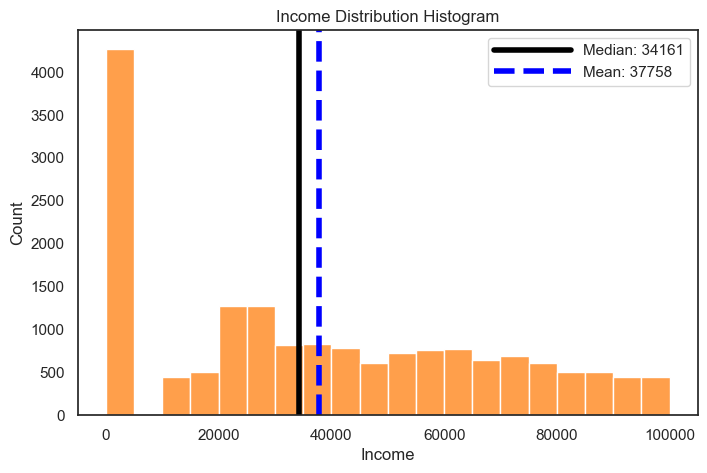

In [45]:
skew_demo = subset_cancellations_na["Income"]

# Clean possible strings like "$12,345" or "12,345" and coerce to numeric
skew_demo = (
    skew_demo.astype(str)
             .str.replace(r"[,$]", "", regex=True)
             .replace(["", "nan", "None"], np.nan)
)
skew_demo = pd.to_numeric(skew_demo, errors="coerce").dropna()

# 2) Your original logic (unchanged)
skew_md = np.median(skew_demo)
skew_mn = np.mean(skew_demo)

sns.set_theme(style="white", palette=None)

fig, ax = plt.subplots(figsize=(8,5))

sns.histplot(skew_demo, bins=20,
             ax=ax, color='tab:orange')

ax.axvline(skew_md, color='black', linewidth=4,
           label='Median: {}'.format(int(skew_md)))
ax.axvline(skew_mn, color='blue', linestyle='dashed', linewidth=4,
           label='Mean: {}'.format(int(skew_mn)))

ax.legend(handlelength=5)

ax.set_title("Income Distribution Histogram")
plt.show()



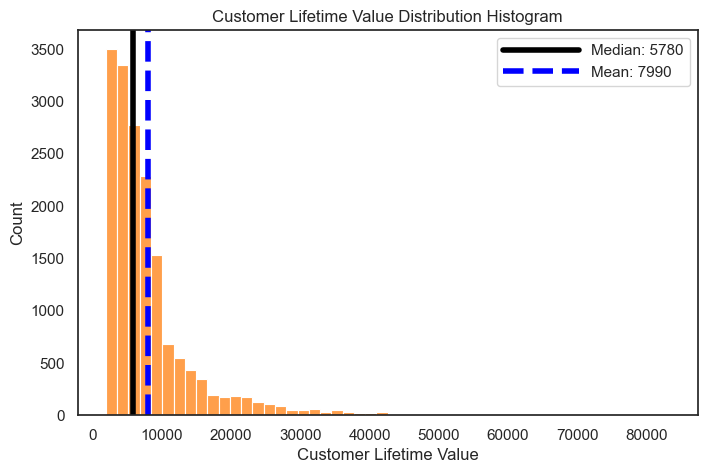

In [46]:
# 1) Build a clean numeric series for Customer Lifetime Value
skew_demo = subset_cancellations_na["Customer Lifetime Value"]

# Clean possible strings like "$12,345.67" or "12,345" and coerce to numeric
skew_demo = (
    skew_demo.astype(str)
             .str.replace(r"[,$]", "", regex=True)
             .replace(["", "nan", "None"], np.nan)
)
skew_demo = pd.to_numeric(skew_demo, errors="coerce").dropna()

# 2) Your original logic (unchanged)
skew_md = np.median(skew_demo)
skew_mn = np.mean(skew_demo)

sns.set_theme(style="white", palette=None)

fig, ax = plt.subplots(figsize=(8,5))

sns.histplot(skew_demo, bins=50,
             ax=ax, color='tab:orange')

ax.axvline(skew_md, color='black', linewidth=4,
           label='Median: {}'.format(int(skew_md)))
ax.axvline(skew_mn, color='blue', linestyle='dashed', linewidth=4,
           label='Mean: {}'.format(int(skew_mn)))

ax.legend(handlelength=5)

ax.set_title("Customer Lifetime Value Distribution Histogram")
plt.show()

sns.set()








In [47]:
subset_cancellations_na.isna().sum()

Loyalty#                    0
Province or State           0
City                        0
Latitude                    0
Longitude                   0
Gender                      0
Education                   0
Income                     20
Marital Status              0
LoyaltyStatus               0
EnrollmentDateOpening       0
CancellationDate            0
Customer Lifetime Value    20
EnrollmentType              0
dtype: int64

In [48]:
subset_cancellations_na.isna().sum()          
subset_cancellations_na.isna().sum().sum()    

np.int64(40)

In [49]:
subset_cancellations_na["Income"] = subset_cancellations_na["Income"].fillna(
    subset_cancellations_na["Income"].median()
)

subset_cancellations_na["Customer Lifetime Value"] = subset_cancellations_na["Customer Lifetime Value"].fillna(
    subset_cancellations_na["Customer Lifetime Value"].median()
)

# sanity check
subset_cancellations_na[["Income", "Customer Lifetime Value"]].isna().sum()

Income                     0
Customer Lifetime Value    0
dtype: int64

In [50]:
subset_cancellations_na.isna().sum()

Loyalty#                   0
Province or State          0
City                       0
Latitude                   0
Longitude                  0
Gender                     0
Education                  0
Income                     0
Marital Status             0
LoyaltyStatus              0
EnrollmentDateOpening      0
CancellationDate           0
Customer Lifetime Value    0
EnrollmentType             0
dtype: int64

In [51]:
subset_customers.isna().sum()

Loyalty#                       0
Province or State              0
City                           0
Latitude                       0
Longitude                      0
Gender                         0
Education                      0
Income                        20
Marital Status                 0
LoyaltyStatus                  0
EnrollmentDateOpening          0
CancellationDate           14611
Customer Lifetime Value       20
EnrollmentType                 0
dtype: int64

In [52]:
subset_cancellations_na.count()

Loyalty#                   16921
Province or State          16921
City                       16921
Latitude                   16921
Longitude                  16921
Gender                     16921
Education                  16921
Income                     16921
Marital Status             16921
LoyaltyStatus              16921
EnrollmentDateOpening      16921
CancellationDate           16921
Customer Lifetime Value    16921
EnrollmentType             16921
dtype: int64

In [53]:
flights.isna().sum()

Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
dtype: int64

In [54]:
subset_cancellations_na.shape

(16921, 14)

In [55]:
subset_cancellations_only = subset_customers[subset_customers["CancellationDate"].notna()].copy()

In [56]:
subset_cancellations_only.isna().sum()

Loyalty#                    0
Province or State           0
City                        0
Latitude                    0
Longitude                   0
Gender                      0
Education                   0
Income                     20
Marital Status              0
LoyaltyStatus               0
EnrollmentDateOpening       0
CancellationDate            0
Customer Lifetime Value    20
EnrollmentType              0
dtype: int64

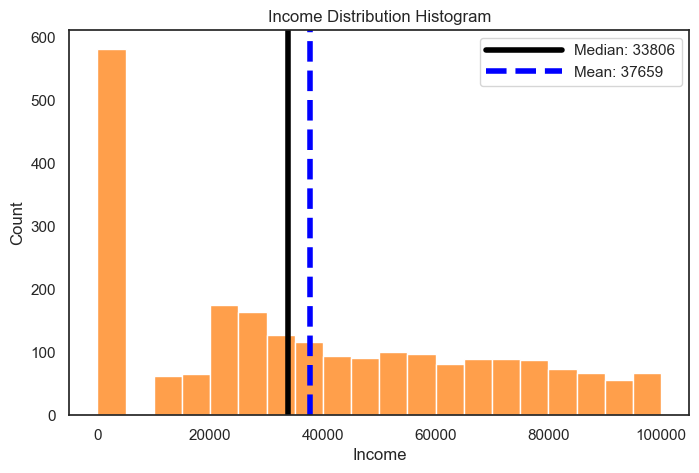

In [57]:
skew_demo = subset_cancellations_only["Income"]

# Clean possible strings like "$12,345" or "12,345" and coerce to numeric
skew_demo = (
    skew_demo.astype(str)
             .str.replace(r"[,$]", "", regex=True)
             .replace(["", "nan", "None"], np.nan)
)
skew_demo = pd.to_numeric(skew_demo, errors="coerce").dropna()

# 2) Your original logic (unchanged)
skew_md = np.median(skew_demo)
skew_mn = np.mean(skew_demo)

sns.set_theme(style="white", palette=None)

fig, ax = plt.subplots(figsize=(8,5))

sns.histplot(skew_demo, bins=20,
             ax=ax, color='tab:orange')

ax.axvline(skew_md, color='black', linewidth=4,
           label='Median: {}'.format(int(skew_md)))
ax.axvline(skew_mn, color='blue', linestyle='dashed', linewidth=4,
           label='Mean: {}'.format(int(skew_mn)))

ax.legend(handlelength=5)

ax.set_title("Income Distribution Histogram")
plt.show()


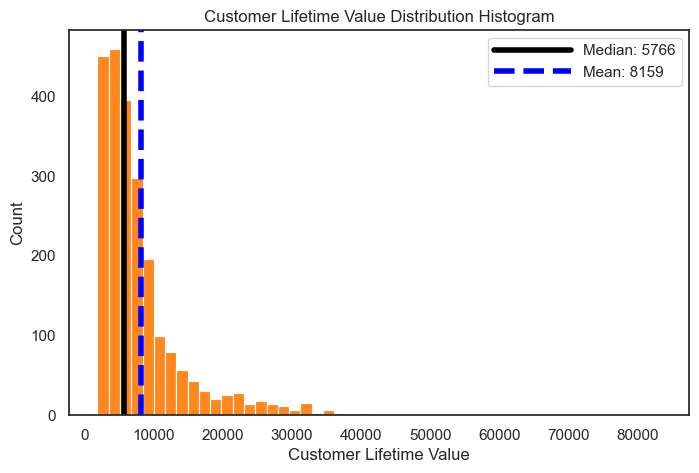

In [58]:
# 1) Build a clean numeric series for Customer Lifetime Value
skew_demo = subset_cancellations_only["Customer Lifetime Value"]

# Clean possible strings like "$12,345.67" or "12,345" and coerce to numeric
skew_demo = (
    skew_demo.astype(str)
             .str.replace(r"[,$]", "", regex=True)
             .replace(["", "nan", "None"], np.nan)
)
skew_demo = pd.to_numeric(skew_demo, errors="coerce").dropna()

# 2) Your original logic (unchanged)
skew_md = np.median(skew_demo)
skew_mn = np.mean(skew_demo)

sns.set_theme(style="white", palette=None)

fig, ax = plt.subplots(figsize=(8,5))

sns.histplot(skew_demo, bins=50,
             ax=ax, color='tab:orange')
sns.histplot(skew_demo, bins=50,
             ax=ax, color='tab:orange')

ax.axvline(skew_md, color='black', linewidth=4,
           label='Median: {}'.format(int(skew_md)))
ax.axvline(skew_mn, color='blue', linestyle='dashed', linewidth=4,
           label='Mean: {}'.format(int(skew_mn)))

ax.legend(handlelength=5)

ax.set_title("Customer Lifetime Value Distribution Histogram")
plt.show()

sns.set()


In [59]:
subset_cancellations_only = subset_customers[subset_customers["CancellationDate"].notna()].copy()

subset_cancellations_only["Income"] = subset_cancellations_only["Income"].fillna(
    subset_cancellations_only["Income"].median()
)
subset_cancellations_only["Customer Lifetime Value"] = subset_cancellations_only["Customer Lifetime Value"].fillna(
    subset_cancellations_only["Customer Lifetime Value"].median()
)

# check
subset_cancellations_only.isna().sum()


Loyalty#                   0
Province or State          0
City                       0
Latitude                   0
Longitude                  0
Gender                     0
Education                  0
Income                     0
Marital Status             0
LoyaltyStatus              0
EnrollmentDateOpening      0
CancellationDate           0
Customer Lifetime Value    0
EnrollmentType             0
dtype: int64

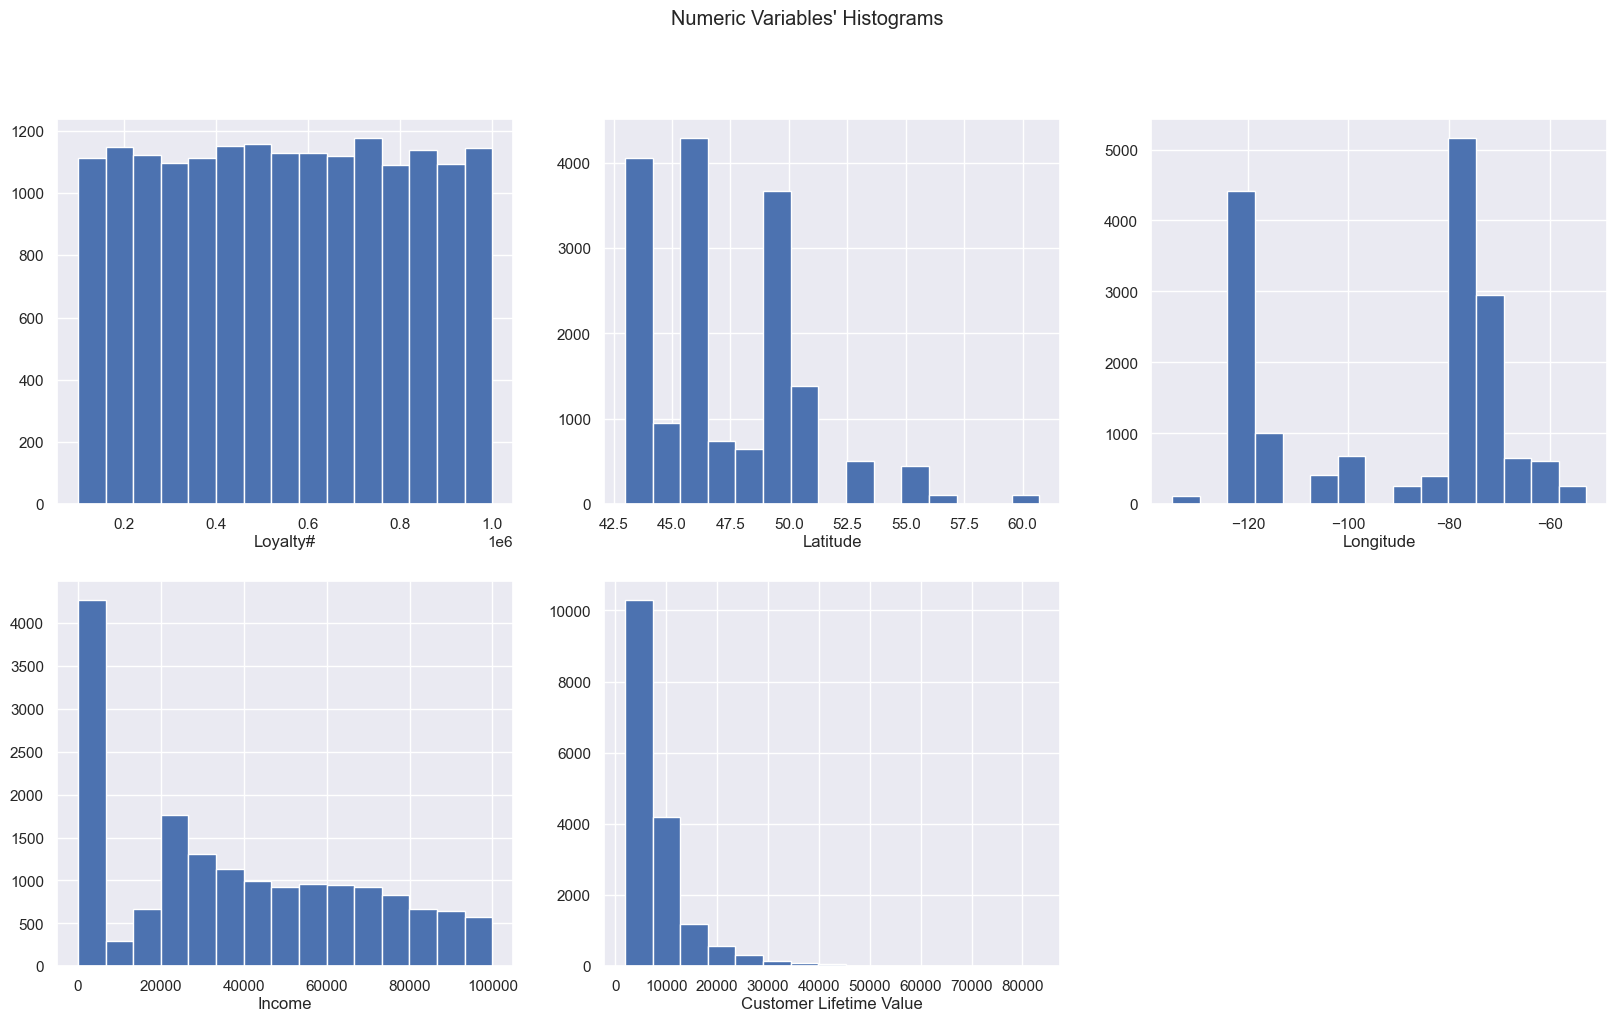

In [60]:
df = subset_cancellations_na

# numeric columns
metric_features = df.select_dtypes(include="number").columns.tolist()

# find & skip all-NaN numeric columns
all_nan_cols = [c for c in metric_features if df[c].isna().all()]
if all_nan_cols:
    print("Skipping all-NaN numeric columns:", all_nan_cols)
metric_features = [c for c in metric_features if c not in all_nan_cols]

sns.set()
fig, axes = plt.subplots(2, ceil(len(metric_features)/2), figsize=(20, 11))
axes = axes.flatten()

for ax, feat in zip(axes, metric_features):
    s = df[feat].dropna()
    if s.empty:
        ax.axis("off")
        continue
    ax.hist(s, bins=15)
    ax.set_title(feat, y=-0.13)

# hide any unused axes
for ax in axes[len(metric_features):]:
    ax.axis("off")

plt.suptitle("Numeric Variables' Histograms")
plt.show()

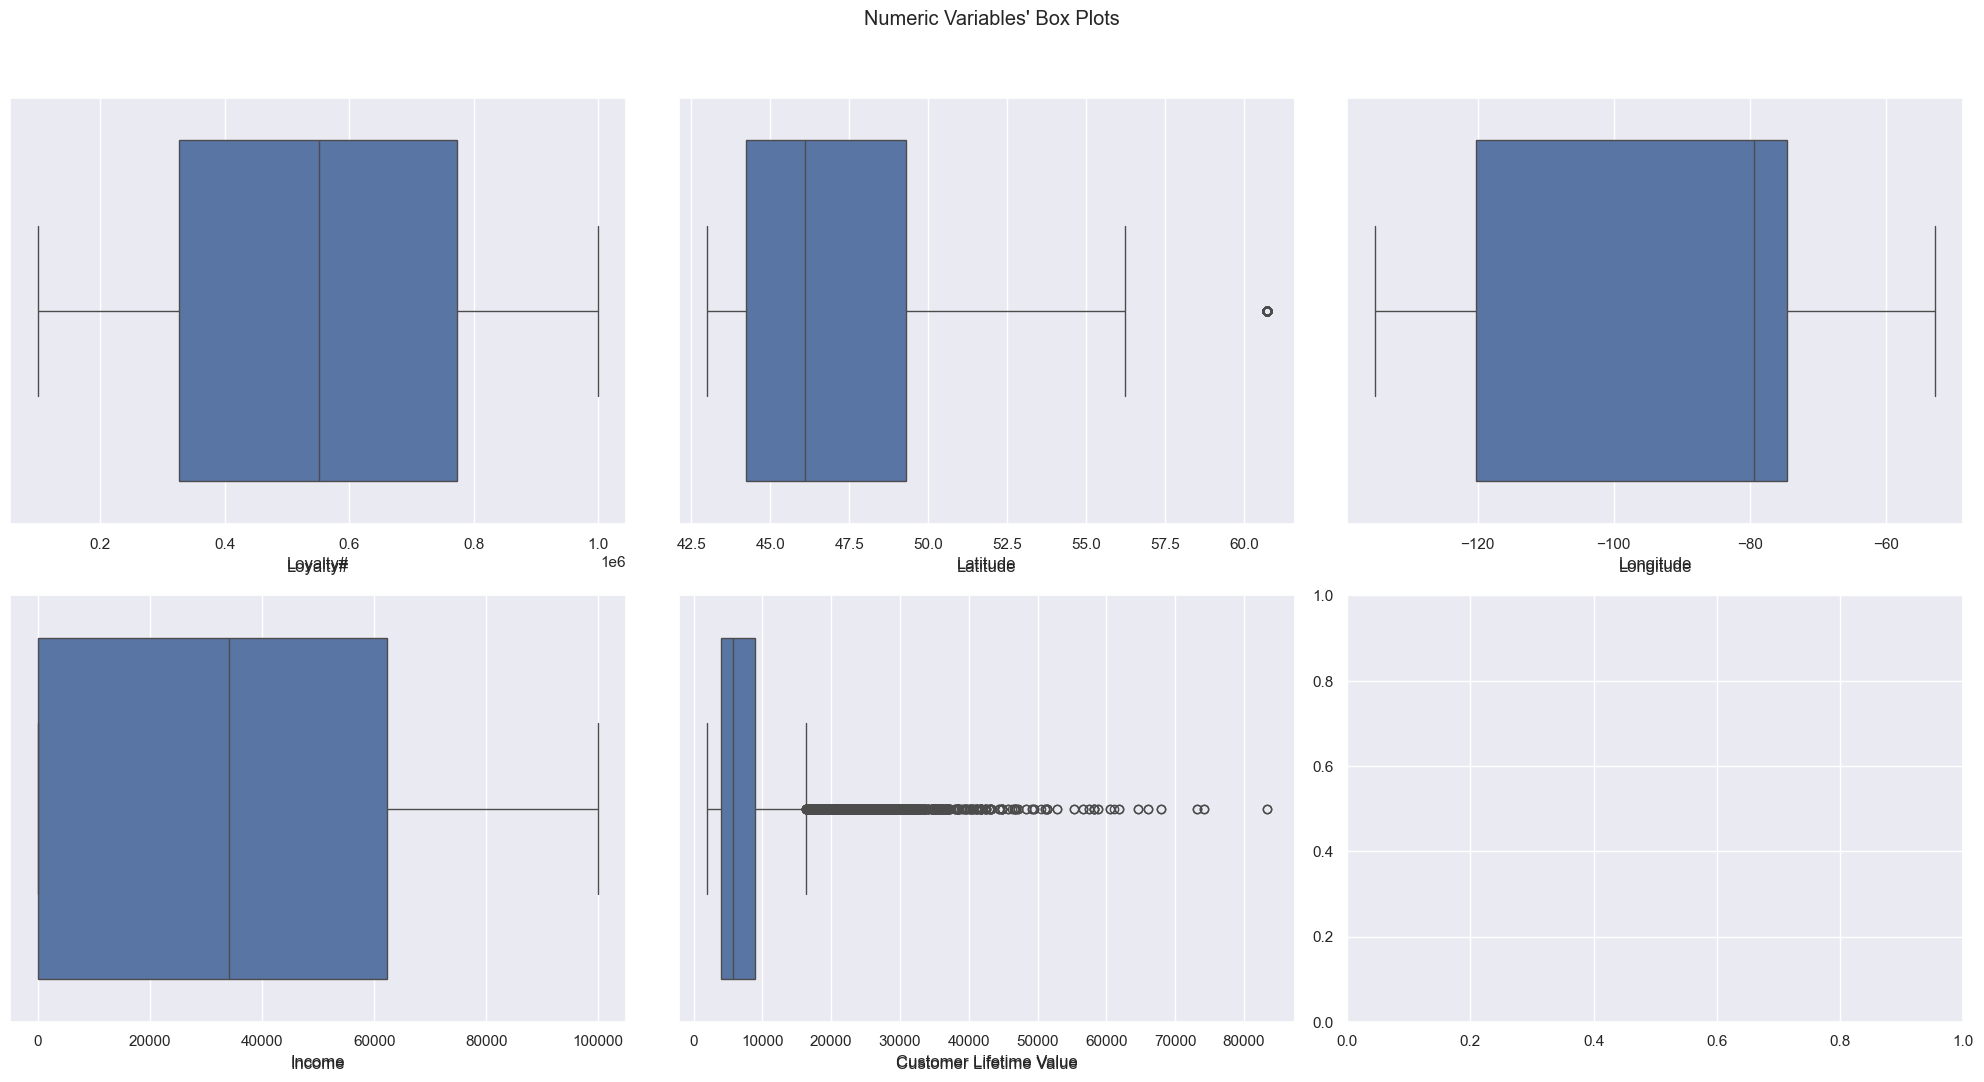

In [61]:
# Keep only numeric columns that aren’t entirely NaN
metric_features = df.select_dtypes(include="number").columns[df.select_dtypes(include="number").notna().any()].tolist()

sns.set()
fig, axes = plt.subplots(2, ceil(len(metric_features)/2), figsize=(20, 11))

for ax, feat in zip(axes.flatten(), metric_features):
    sns.boxplot(x=df[feat], ax=ax)
    ax.set_title(feat, y=-0.13)

plt.suptitle("Numeric Variables' Box Plots")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

In [62]:
filters_man = (
    (subset_cancellations_na['Customer Lifetime Value'] <= 60000)  # keep CLV below ~60k
    & (subset_cancellations_na['Income'] <= 100000)                # optional: filter extreme income
)

subset_cleaned_manual = subset_cancellations_na[filters_man]

# check percentage of data kept
print(
    'Percentage of data kept after removing outliers:',
    100 * np.round(subset_cleaned_manual.shape[0] / subset_cancellations_na.shape[0], 4)
)

Percentage of data kept after removing outliers: 99.9


In [63]:
subset_cancellations_na[
    (subset_cancellations_na['Latitude'] > 90) | 
    (subset_cancellations_na['Latitude'] < -90)
]


,Loyalty#,Province or State,City,Latitude,Longitude,Gender,Education,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType


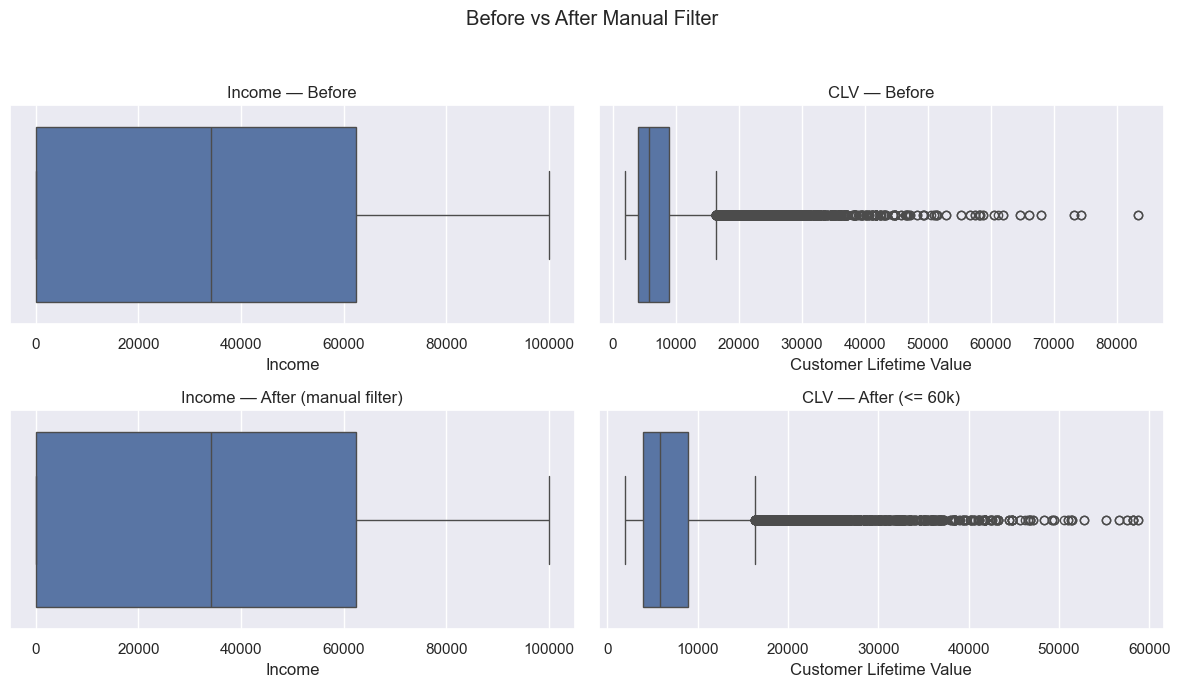

In [64]:
sns.set()
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey='row')

# Income
sns.boxplot(x=subset_cancellations_na["Income"], ax=axes[0,0]);  axes[0,0].set_title("Income — Before")
sns.boxplot(x=subset_cleaned_manual["Income"], ax=axes[1,0]);    axes[1,0].set_title("Income — After (manual filter)")

# CLV
sns.boxplot(x=subset_cancellations_na["Customer Lifetime Value"], ax=axes[0,1]); axes[0,1].set_title("CLV — Before")
sns.boxplot(x=subset_cleaned_manual["Customer Lifetime Value"], ax=axes[1,1]);   axes[1,1].set_title("CLV — After (<= 60k)")

plt.suptitle("Before vs After Manual Filter")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

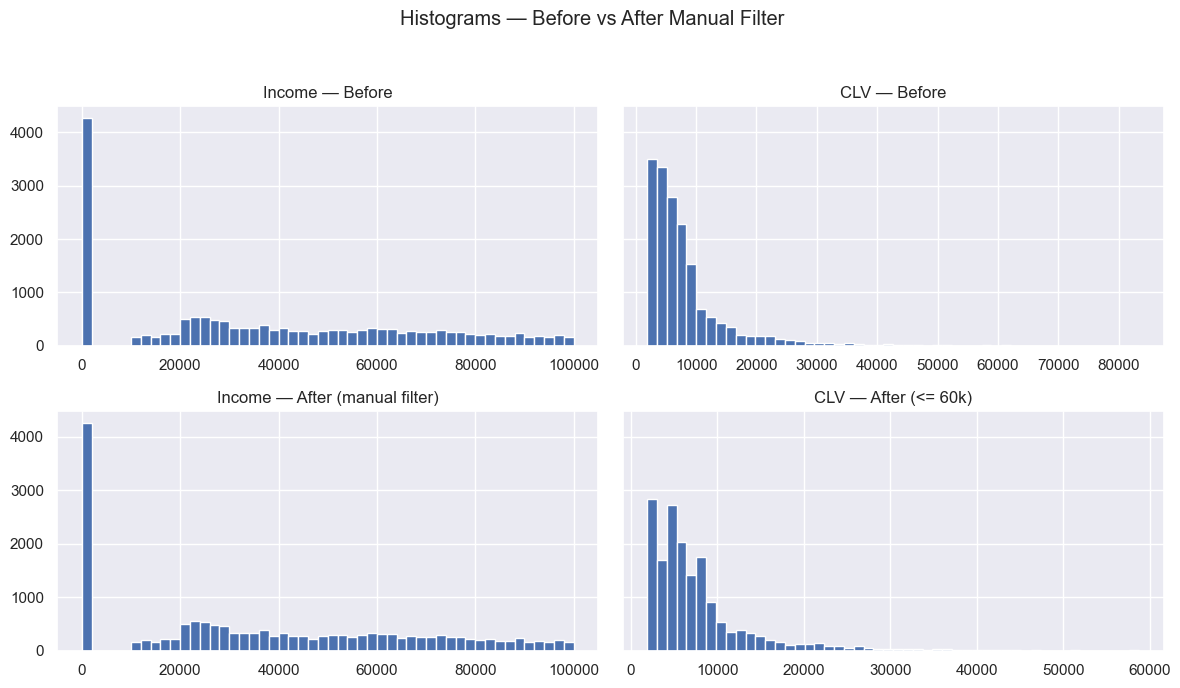

In [65]:
ig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey='row')

# Income
axes[0,0].hist(subset_cancellations_na["Income"].dropna(), bins=50)
axes[0,0].set_title("Income — Before")
axes[1,0].hist(subset_cleaned_manual["Income"].dropna(), bins=50)
axes[1,0].set_title("Income — After (manual filter)")

# Customer Lifetime Value
axes[0,1].hist(subset_cancellations_na["Customer Lifetime Value"].dropna(), bins=50)
axes[0,1].set_title("CLV — Before")
axes[1,1].hist(subset_cleaned_manual["Customer Lifetime Value"].dropna(), bins=50)
axes[1,1].set_title("CLV — After (<= 60k)")

plt.suptitle("Histograms — Before vs After Manual Filter")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

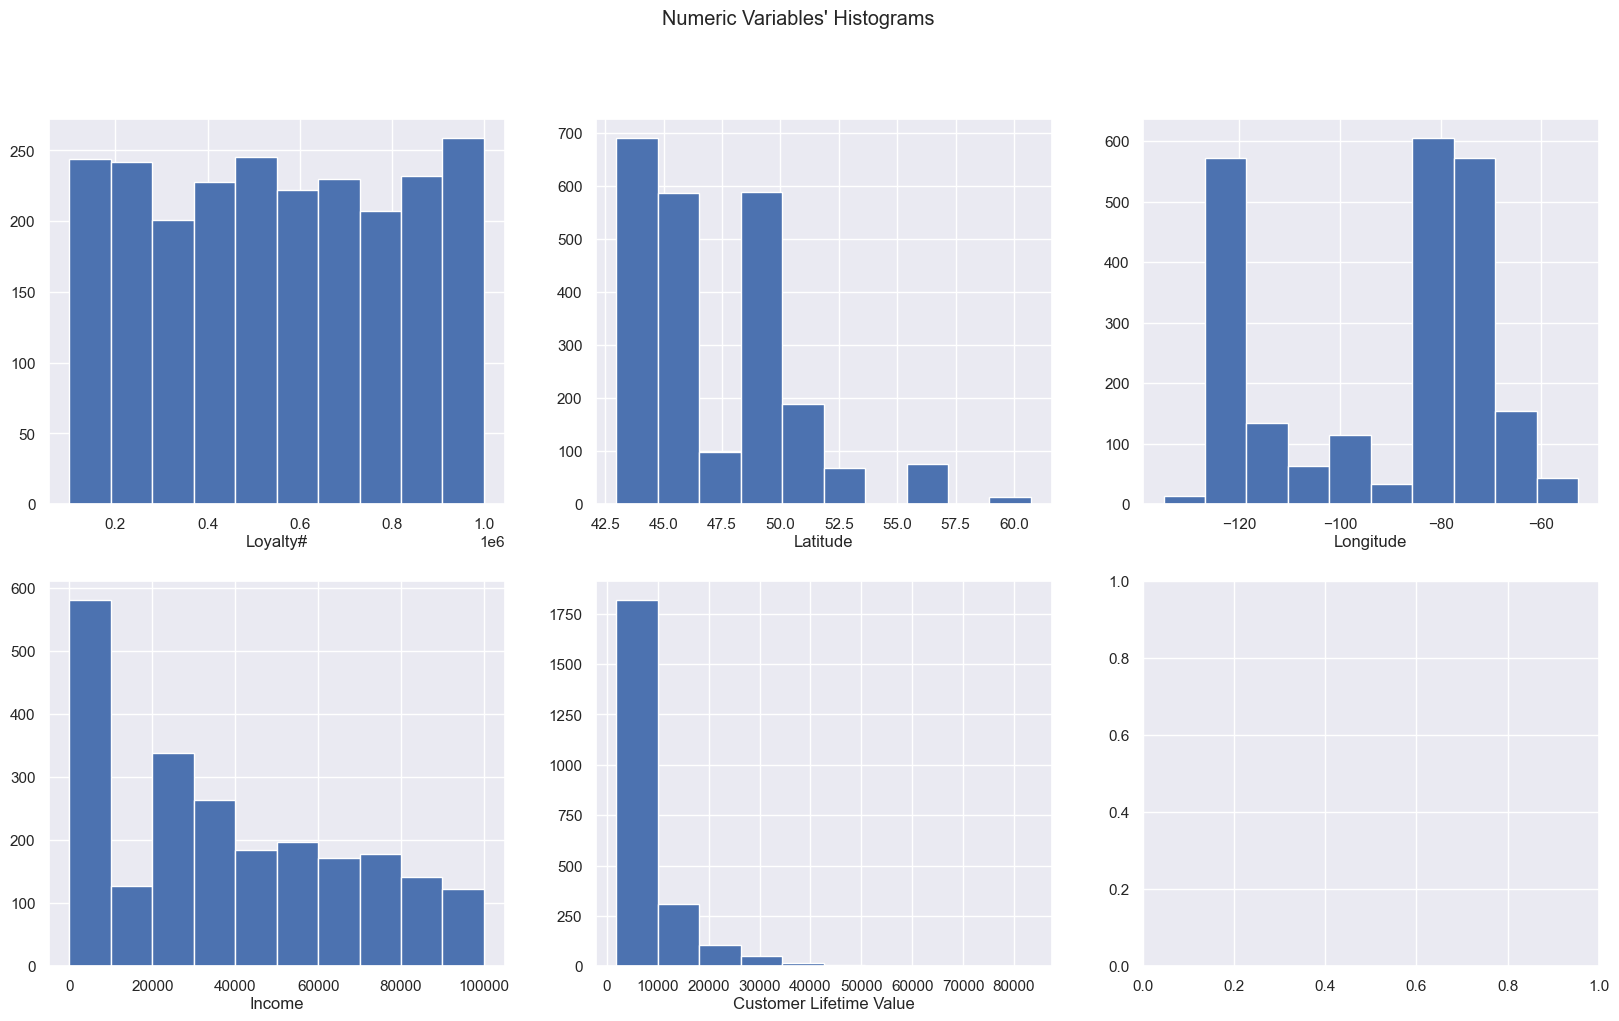

In [66]:
metric_features = subset_cancellations_only.select_dtypes(include="number").columns

# Assign DataFrame
df = subset_cancellations_only

sns.set()
fig, axes = plt.subplots(2, ceil(len(metric_features) / 2), figsize=(20, 11))

for ax, feat in zip(axes.flatten(), metric_features):
    ax.hist(df[feat])
    ax.set_title(feat, y=-0.13)

plt.suptitle("Numeric Variables' Histograms")
plt.show()

In [44]:
subset_cancellations_na.count()

Loyalty#                   2310
Province or State          2310
City                       2310
Latitude                   2310
Longitude                  2310
Gender                     2310
Education                  2310
Income                     2310
Marital Status             2310
LoyaltyStatus              2310
EnrollmentDateOpening      2310
CancellationDate           2310
Customer Lifetime Value    2310
EnrollmentType             2310
dtype: int64

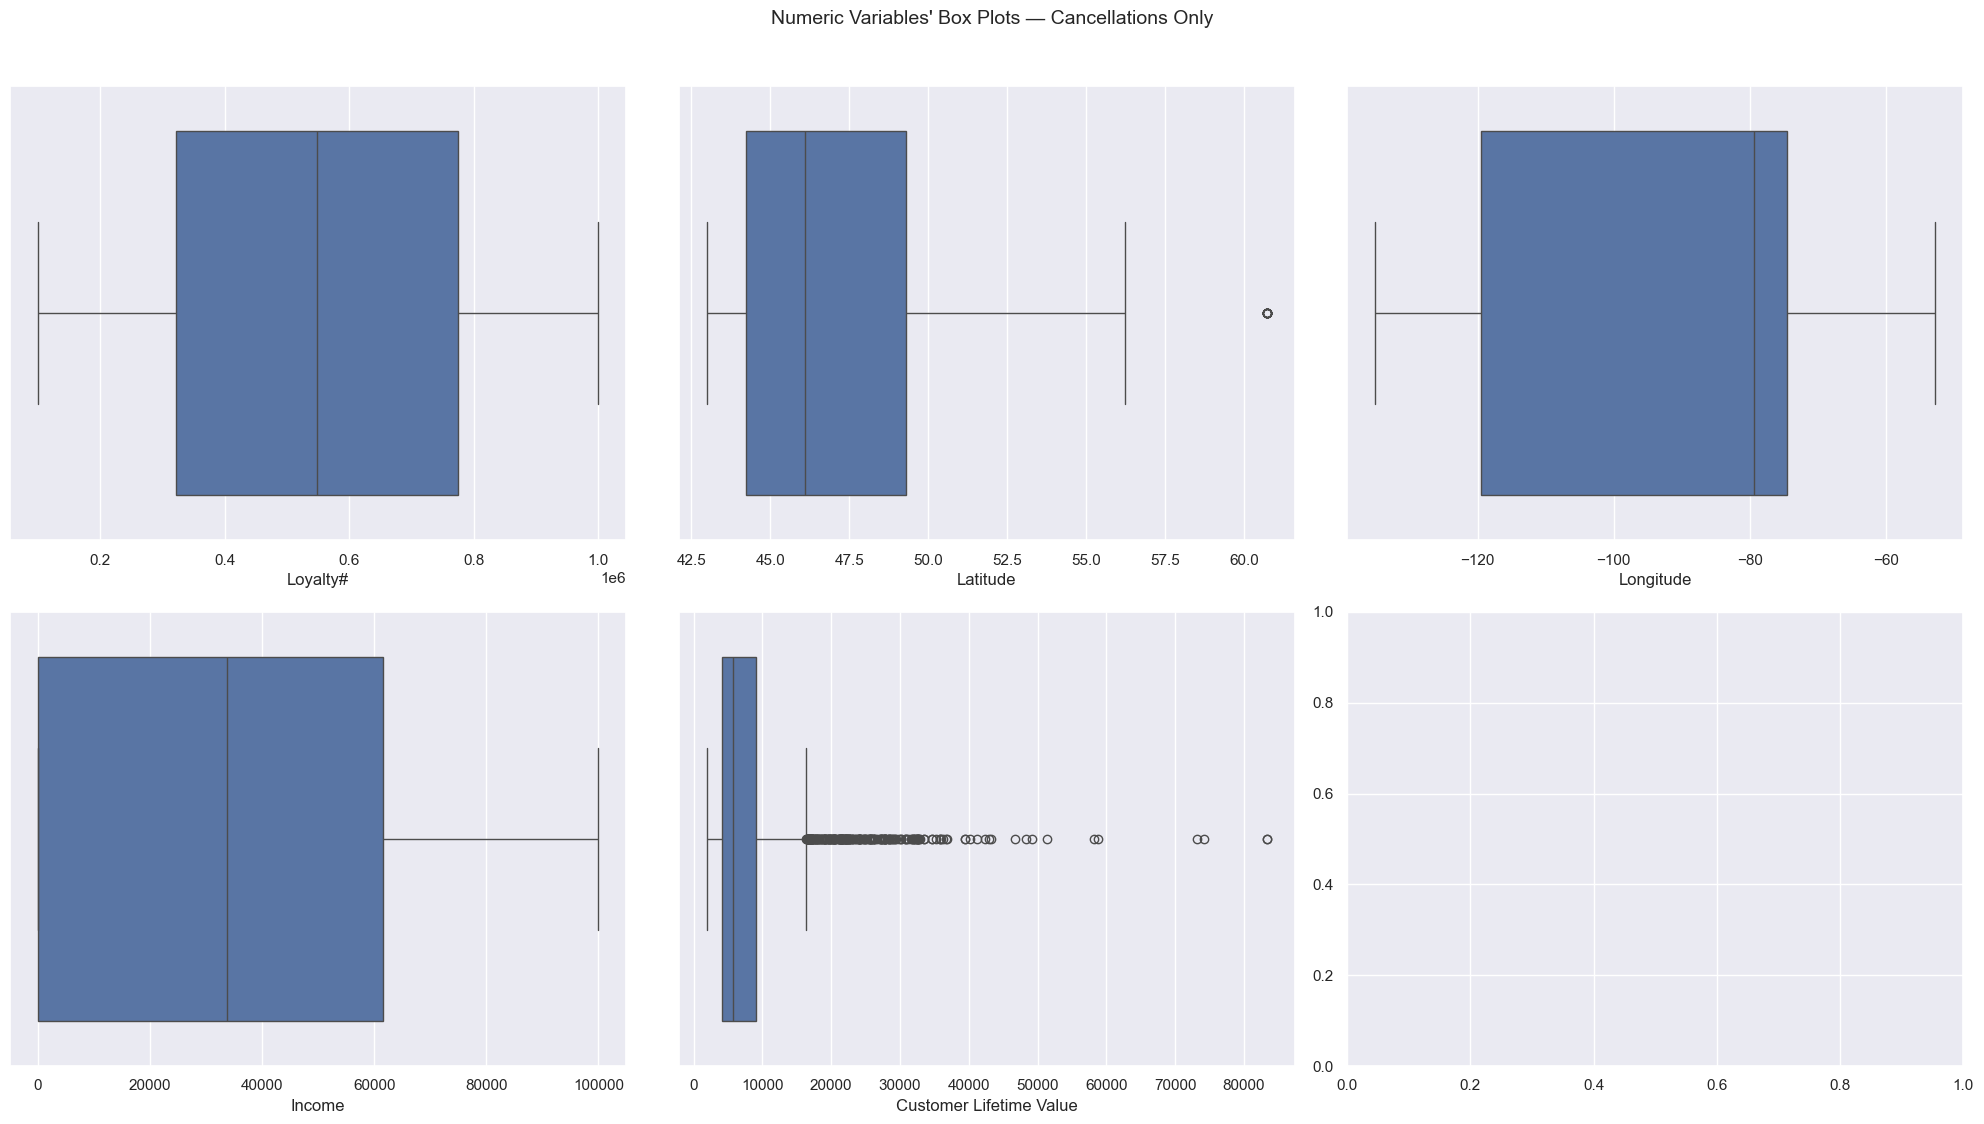

In [39]:
metric_features = subset_cancellations_only.select_dtypes(include="number").columns

df = subset_cancellations_only

sns.set()
fig, axes = plt.subplots(2, ceil(len(metric_features) / 2), figsize=(20, 11))

for ax, feat in zip(axes.flatten(), metric_features):
    sns.boxplot(x=df[feat], ax=ax)
    ax.set_xlabel(feat)  # put label below the boxplot
    ax.set_title("")     # remove the redundant title

plt.suptitle("Numeric Variables' Box Plots — Cancellations Only", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


In [40]:
subset_cancellations_only.count()

Loyalty#                   2310
Province or State          2310
City                       2310
Latitude                   2310
Longitude                  2310
Gender                     2310
Education                  2310
Income                     2310
Marital Status             2310
LoyaltyStatus              2310
EnrollmentDateOpening      2310
CancellationDate           2310
Customer Lifetime Value    2310
EnrollmentType             2310
dtype: int64

In [91]:
filters_man = (
    (subset_cancellations_only['Customer Lifetime Value'] <= 60000)  # keep CLV below ~60k
    & (subset_cancellations_only['Income'] <= 100000)                # optional: filter extreme income
)

subset_cleaned_manual = subset_cancellations_only[filters_man]

# check percentage of data kept
print(
    'Percentage of data kept after removing outliers:',
    100 * np.round(subset_cleaned_manual.shape[0] / subset_cancellations_only.shape[0], 4)
)

Percentage of data kept after removing outliers: 99.83


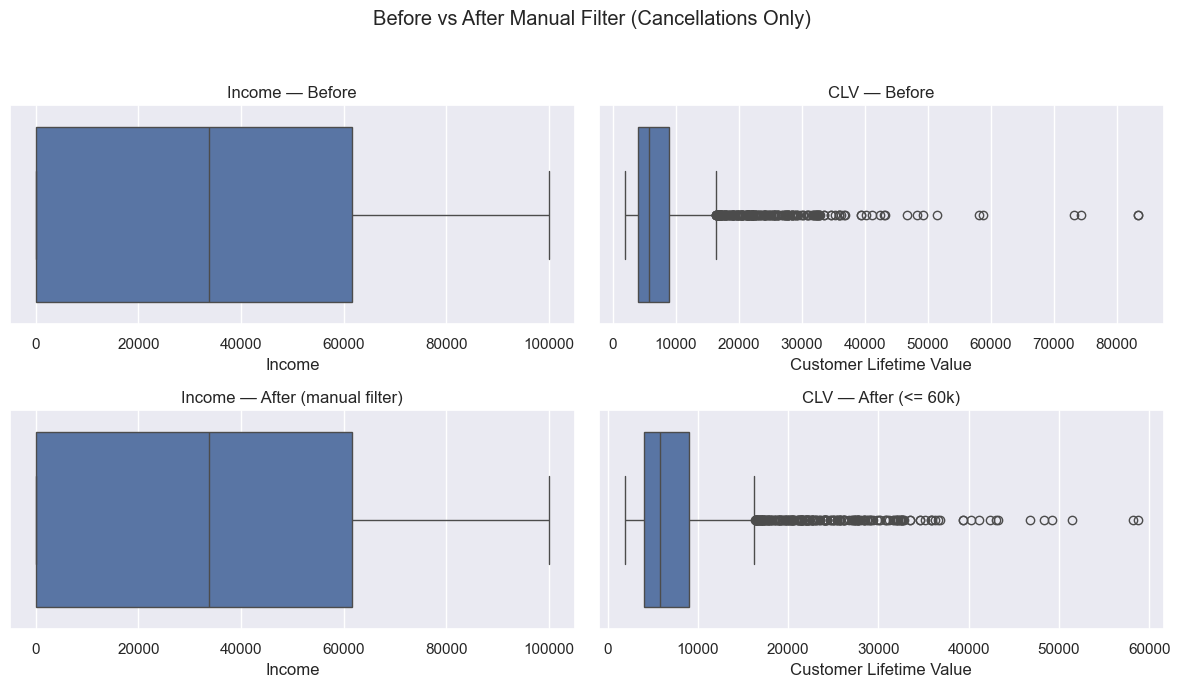

In [92]:
sns.set()
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey='row')

# Income
sns.boxplot(x=subset_cancellations_only["Income"], ax=axes[0,0]);  axes[0,0].set_title("Income — Before")
sns.boxplot(x=subset_cleaned_manual["Income"],      ax=axes[1,0]);  axes[1,0].set_title("Income — After (manual filter)")

# CLV
sns.boxplot(x=subset_cancellations_only["Customer Lifetime Value"], ax=axes[0,1]); axes[0,1].set_title("CLV — Before")
sns.boxplot(x=subset_cleaned_manual["Customer Lifetime Value"],      ax=axes[1,1]); axes[1,1].set_title("CLV — After (<= 60k)")

plt.suptitle("Before vs After Manual Filter (Cancellations Only)")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


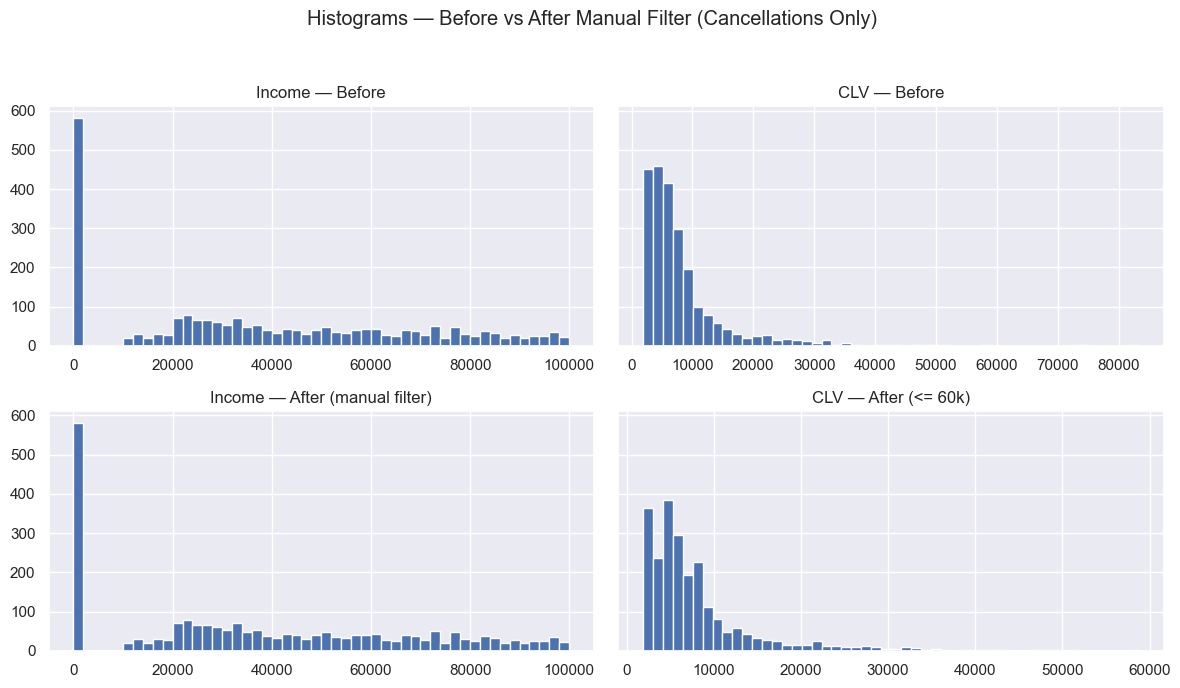

In [93]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey='row')

axes[0,0].hist(subset_cancellations_only["Income"].dropna(), bins=50);  axes[0,0].set_title("Income — Before")
axes[1,0].hist(subset_cleaned_manual["Income"].dropna(),      bins=50);  axes[1,0].set_title("Income — After (manual filter)")

axes[0,1].hist(subset_cancellations_only["Customer Lifetime Value"].dropna(), bins=50); axes[0,1].set_title("CLV — Before")
axes[1,1].hist(subset_cleaned_manual["Customer Lifetime Value"].dropna(),      bins=50); axes[1,1].set_title("CLV — After (<= 60k)")

plt.suptitle("Histograms — Before vs After Manual Filter (Cancellations Only)")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

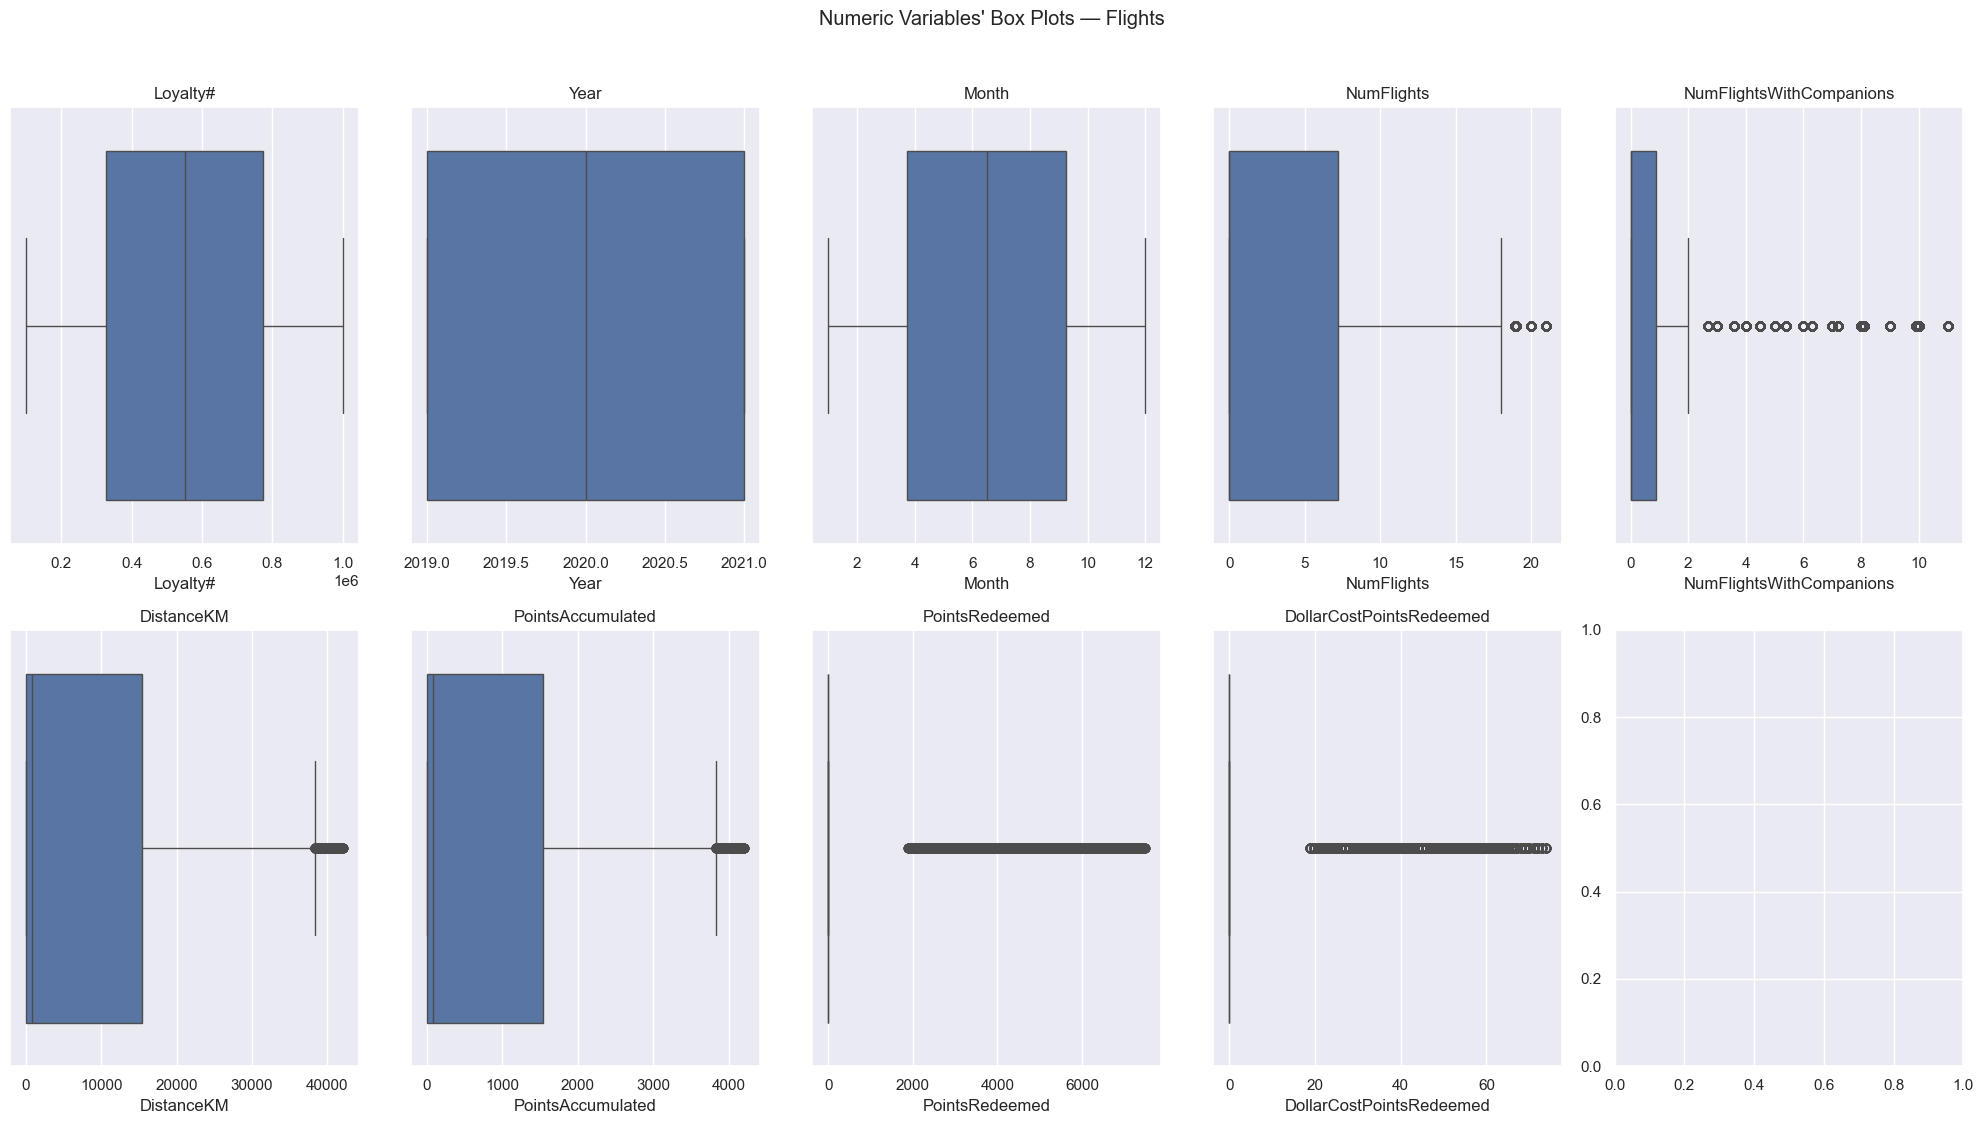

In [94]:
# numeric columns from flights
metric_features = flights.select_dtypes(include="number").columns
df = flights

sns.set()
fig, axes = plt.subplots(2, ceil(len(metric_features) / 2), figsize=(20, 11))

for ax, feat in zip(axes.flatten(), metric_features):
    sns.boxplot(x=df[feat], ax=ax)
    ax.set_title(feat)  # <-- fixed (no y offset so it won't overlap labels)

plt.suptitle("Numeric Variables' Box Plots — Flights", y=1.02)
plt.tight_layout()
plt.show()

In [95]:
flights["NumFlightsWithCompanions"].value_counts().sort_index()


NumFlightsWithCompanions
0.0     448398
0.9       8368
1.0      17905
1.8       8636
2.0      19272
2.7       8509
3.0      19015
3.6       7138
4.0      13665
4.5       5938
5.0      13424
5.4       5204
6.0       9911
6.3       3508
7.0       7089
7.2       1940
8.0       3965
8.1       1356
9.0       3443
9.9        205
10.0      1071
11.0       476
Name: count, dtype: int64

In [96]:
perc_above_8 = (
    (flights["NumFlightsWithCompanions"] > 8).sum() / len(flights)
) * 100

print(f"Percentage of records with NumFlightsWithCompanions > 8: {perc_above_8:.2f}%")

Percentage of records with NumFlightsWithCompanions > 8: 1.08%


In [98]:
flights.count()

Loyalty#                    608436
Year                        608436
Month                       608436
YearMonthDate               608436
NumFlights                  608436
NumFlightsWithCompanions    608436
DistanceKM                  608436
PointsAccumulated           608436
PointsRedeemed              608436
DollarCostPointsRedeemed    608436
dtype: int64

In [99]:
df_original = flights

# Column to check
col = "NumFlightsWithCompanions"
s = df_original[col].dropna()

# IQR rule (keep if within whiskers)
q1, q3 = s.quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
mask_iqr = df_original[col].between(lo, hi, inclusive="both")

# Manual rule (example: keep values <= 8 companions)
mask_manual = df_original[col] <= 8

# Keep if passes either rule (OR)
keep_mask = mask_iqr | mask_manual
df_out = df_original[keep_mask]

print(
    "Percentage of data kept after filtering:",
    np.round(df_out.shape[0] / df_original.shape[0] * 100, 2), "%"
)

Percentage of data kept after filtering: 98.92 %


In [102]:
flights.count()

Loyalty#                    608436
Year                        608436
Month                       608436
YearMonthDate               608436
NumFlights                  608436
NumFlightsWithCompanions    608436
DistanceKM                  608436
PointsAccumulated           608436
PointsRedeemed              608436
DollarCostPointsRedeemed    608436
dtype: int64

In [103]:
# Use IQR to filter NumFlights (same pattern as your template)

df = flights
metric_features = ["NumFlights"]

# Compute the IQR
q1 = df[metric_features].quantile(.25)

# Calculate Q3
q3 = df[metric_features].quantile(.75)

# Calculate IQR
iqr = (q3 - q1)

# Compute upper and lower limits
lower_lim = q1 - (1.5 * iqr)
upper_lim = q3 + (1.5 * iqr)

filters_iqr = []
for metric in metric_features:
    llim = lower_lim[metric]
    ulim = upper_lim[metric]
    filters_iqr.append(df[metric].between(llim, ulim, inclusive='neither'))

filters_iqr_all = pd.Series(np.all(filters_iqr, 0), index=df.index)

# Apply filter
df_iqr_clean = df[filters_iqr_all]

print('Percentage of data kept after IQR filtering:',
      100 * np.round(df_iqr_clean.shape[0] / df.shape[0], 4))


Percentage of data kept after IQR filtering: 98.86


In [105]:
flights.count()

Loyalty#                    608436
Year                        608436
Month                       608436
YearMonthDate               608436
NumFlights                  608436
NumFlightsWithCompanions    608436
DistanceKM                  608436
PointsAccumulated           608436
PointsRedeemed              608436
DollarCostPointsRedeemed    608436
dtype: int64

In [106]:
flights["DistanceKM"] = pd.to_numeric(flights["DistanceKM"], errors="coerce")
print(flights["DistanceKM"].dtype)
print(flights["DistanceKM"].describe())

float64
count    608436.000000
mean       7939.341419
std       10260.421873
min           0.000000
25%           0.000000
50%         856.400000
75%       15338.175000
max       42040.000000
Name: DistanceKM, dtype: float64


In [ ]:
flights.isna().sum()

In [107]:
# Count and percentage of zeros in DistanceKM
zero_count = (flights["DistanceKM"] == 0).sum()
zero_pct = (flights["DistanceKM"] == 0).mean() * 100

print(f"Number of zeros in DistanceKM: {zero_count}")
print(f"Percentage of zeros: {zero_pct:.2f}%")


Number of zeros in DistanceKM: 298623
Percentage of zeros: 49.08%


In [110]:
flights.count()


Loyalty#                    608436
Year                        608436
Month                       608436
YearMonthDate               608436
NumFlights                  608436
NumFlightsWithCompanions    608436
DistanceKM                  608436
PointsAccumulated           608436
PointsRedeemed              608436
DollarCostPointsRedeemed    608436
dtype: int64

In [112]:
flights.isna().sum()

Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
dtype: int64

In [113]:
flights["HasFlown"] = flights["DistanceKM"].notna().astype(int)


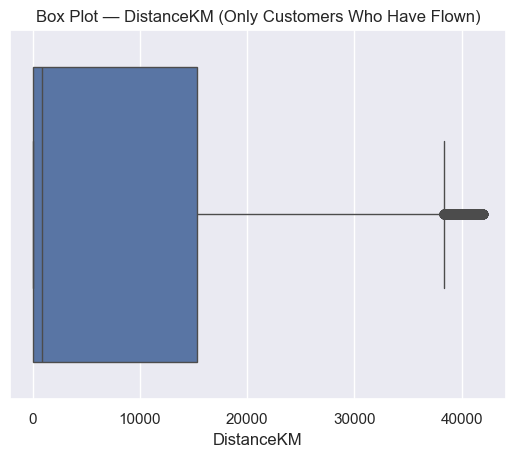

In [114]:
# Filter for customers who have flown
flown_df = flights[flights["HasFlown"] == 1]

# Box plot of DistanceKM for those customers only
sns.boxplot(x=flown_df["DistanceKM"])
plt.title("Box Plot — DistanceKM (Only Customers Who Have Flown)")
plt.show()

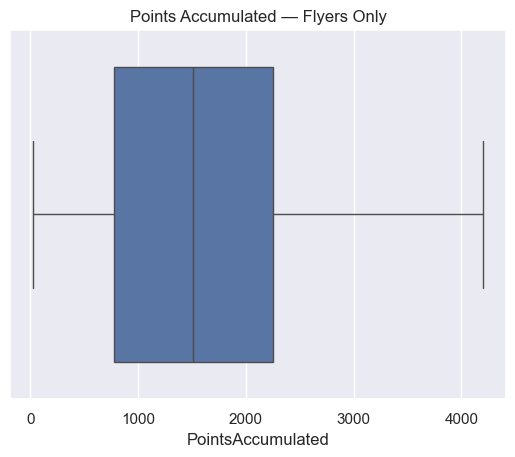

In [115]:
flyers = flights[flights["DistanceKM"].fillna(0) > 0].copy()
sns.boxplot(x=flyers["PointsAccumulated"])
plt.title("Points Accumulated — Flyers Only")
plt.show()

In [116]:
flights["NumFlightsWithCompanions"].value_counts().sort_index()

NumFlightsWithCompanions
0.0     448398
0.9       8368
1.0      17905
1.8       8636
2.0      19272
2.7       8509
3.0      19015
3.6       7138
4.0      13665
4.5       5938
5.0      13424
5.4       5204
6.0       9911
6.3       3508
7.0       7089
7.2       1940
8.0       3965
8.1       1356
9.0       3443
9.9        205
10.0      1071
11.0       476
Name: count, dtype: int64

In [117]:
flights.count()

Loyalty#                    608436
Year                        608436
Month                       608436
YearMonthDate               608436
NumFlights                  608436
NumFlightsWithCompanions    608436
DistanceKM                  608436
PointsAccumulated           608436
PointsRedeemed              608436
DollarCostPointsRedeemed    608436
HasFlown                    608436
dtype: int64

In [118]:
zero_pct = (flights["PointsRedeemed"] == 0).mean() * 100
print(f"Percentage of customers with 0 points redeemed: {zero_pct:.2f}%")


Percentage of customers with 0 points redeemed: 94.18%


In [119]:
# Binary flag for customers who have redeemed points
flights["HasRedeemedPoints"] = (flights["PointsRedeemed"] > 0).astype(int)

# Quick check
flights["HasRedeemedPoints"].value_counts(normalize=True) * 100

HasRedeemedPoints
0    94.182954
1     5.817046
Name: proportion, dtype: float64

In [120]:
zero_pct = (flights["DollarCostPointsRedeemed"] == 0).mean() * 100
print(f"Percentage of customers with 0 dollar cost points redeemed: {zero_pct:.2f}%")


Percentage of customers with 0 dollar cost points redeemed: 94.18%


In [122]:
print("✅ DATA CLEANING SUMMARY")
print("=" * 30)

# Show basic info
print(f"\nsubset_cancellations_na → {subset_cancellations_na.shape[0]} rows, {subset_cancellations_na.shape[1]} columns")
print(f"subset_cancellations_only → {subset_cancellations_only.shape[0]} rows, {subset_cancellations_only.shape[1]} columns")
print(f"flights → {flights.shape[0]} rows, {flights.shape[1]} columns")

# Count total missing values for each
print("\nMissing values (remaining after cleaning):")
print("subset_cancellations_na:\n", subset_cancellations_na.isna().sum().sum(), "total missing values")
print("subset_cancellations_only:\n", subset_cancellations_only.isna().sum().sum(), "total missing values")
print("flights:\n", flights.isna().sum().sum(), "total missing values")

print("\n✅ All datasets cleaned and visualized successfully!")

✅ DATA CLEANING SUMMARY

subset_cancellations_na → 16921 rows, 14 columns
subset_cancellations_only → 2310 rows, 14 columns
flights → 608436 rows, 12 columns

Missing values (remaining after cleaning):
subset_cancellations_na:
 16921 total missing values
subset_cancellations_only:
 0 total missing values
flights:
 0 total missing values

✅ All datasets cleaned and visualized successfully!
